In [3]:
import json
import re
import pandas as pd
import rdflib


### Step 1: Load the ChEBI Ontology ###
def load_chebi_ontology(chebi_owl_file):
    g = rdflib.Graph()
    g.parse(chebi_owl_file, format="xml")  # Parses the OWL file
    concepts = set()
    
    for s, p, o in g:
        if "obo/chebi" in s:  # Filtering only ChEBI concepts
            concept_name = o.split("/")[-1] if "/" in str(o) else str(o)
            concepts.add(concept_name.lower())  # Store in lowercase for consistency

    return concepts

# Load ChEBI ontology (Replace 'chebi.owl' with the actual file path)
chebi_concepts = load_chebi_ontology("/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl")  # Example path

### Step 2: Extract Concepts from Ontology Annotations ###
def extract_concepts(ontology_text):
    concepts = re.findall(r"Looking up (.*?) in the ChEBI ontology", ontology_text)
    return {concept.lower() for concept in concepts}

### Step 3: Extract Concepts from LLM Response ###
def extract_llm_concepts(response_text):
    words = re.findall(r"\b[A-Z][a-z]+\b", response_text)  # Extract capitalized words
    return {word.lower() for word in words}

### Step 4: Detect Concept Insertion ###
def detect_concept_insertion(llm_concepts, ontology_concepts, chebi_concepts):
    inserted_concepts = llm_concepts - (ontology_concepts | chebi_concepts)
    return len(inserted_concepts), inserted_concepts

### Step 5: Detect Rule Violations ###
def detect_rule_violation(response_text, rules):
    violations = [rule for rule in rules if rule.lower() in response_text.lower()]
    return len(violations), violations

# Example rule set (Can be expanded)
predefined_rules = [
    "negative ionization energy is invalid",
    "ionization energy should increase within a group",
    "boiling points follow periodic trends",
    "oxidation numbers must balance"
]

# Sample input (Replace with actual JSON data)
data = {
    "deepseek-r1:14b_57": {
        "question": {"text": "Nickel (Z = 28, A = 59) has a first ionization energy..."},
        "OntologyInfo": "...The entities identified in this sentence are: Nickel, Z, A, C, Pt, Palladium...",
        "onto_model_response": "The ionization energy of palladium is expected to be higher than nickel's...",
        "raw_model_response": "Wait, but wait—Ni is in period 4, Pd in period 5, and Pt in period 6..."
    }
}

### Step 6: Process Each Question-Answer Pair ###
results = []
for key, entry in data.items():
    question_text = entry["question"]["text"]
    ontology_text = entry["OntologyInfo"]
    llm_response = entry["onto_model_response"]

    # Extract concepts
    ontology_concepts = extract_concepts(ontology_text)
    llm_concepts = extract_llm_concepts(llm_response)

    # Detect concept insertion
    num_insertions, inserted_concepts = detect_concept_insertion(llm_concepts, ontology_concepts, chebi_concepts)

    # Detect rule violations
    num_violations, violated_rules = detect_rule_violation(llm_response, predefined_rules)

    # Store results
    results.append({
        "Question": question_text,
        "Concept Insertions": num_insertions,
        "Inserted Concepts": list(inserted_concepts),
        "Rule Violations": num_violations,
        "Violated Rules": violated_rules
    })

### Step 7: Convert Results to DataFrame and Display ###
df_results = pd.DataFrame(results)
tools.display_dataframe_to_user(name="LLM Error Analysis", dataframe=df_results)


NameError: name 'tools' is not defined

In [5]:
import json
import re
import pandas as pd
import rdflib

### Step 1: Load the ChEBI Ontology ###
def load_chebi_ontology(chebi_owl_file):
    """
    Loads the ChEBI ontology from an OWL file and extracts valid concepts.
    """
    g = rdflib.Graph()
    g.parse(chebi_owl_file, format="xml")  # Parses the OWL file
    concepts = set()

    for s, p, o in g:
        if "obo/chebi" in str(s):  # Filtering only ChEBI concepts
            concept_name = str(o).split("/")[-1] if "/" in str(o) else str(o)
            concepts.add(concept_name.lower())  # Store in lowercase for consistency

    return concepts

# Load ChEBI ontology (Replace with actual file path)
chebi_concepts = load_chebi_ontology("/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl")  # Example: Path to the OWL file

### Step 2: Extract Concepts from Ontology Annotations ###
def extract_concepts(ontology_text):
    """
    Extracts concepts from ontology annotations.
    """
    concepts = re.findall(r"Looking up (.*?) in the ChEBI ontology", ontology_text)
    return {concept.lower() for concept in concepts}

### Step 3: Extract Concepts from LLM Response ###
def extract_llm_concepts(response_text):
    """
    Extracts capitalized words from an LLM response as potential concepts.
    """
    words = re.findall(r"\b[A-Z][a-z]+\b", response_text)  # Extract capitalized words
    return {word.lower() for word in words}

### Step 4: Detect Concept Insertion ###
def detect_concept_insertion(llm_concepts, ontology_concepts, chebi_concepts):
    """
    Identifies concept insertions where the LLM introduces terms not in the ontology.
    """
    inserted_concepts = llm_concepts - (ontology_concepts | chebi_concepts)
    return len(inserted_concepts), inserted_concepts

### Step 5: Detect Rule Violations ###
def detect_rule_violation(response_text, rules):
    """
    Identifies rule violations by checking if LLM's response contradicts predefined rules.
    """
    violations = [rule for rule in rules if rule.lower() in response_text.lower()]
    return len(violations), violations

# Example rule set (Can be expanded)
predefined_rules = [
    "negative ionization energy is invalid",
    "ionization energy should increase within a group",
    "boiling points follow periodic trends",
    "oxidation numbers must balance"
]

# Sample input (Replace with actual JSON data)
data = {
    "deepseek-r1:14b_57": {
        "question": {"text": "Nickel (Z = 28, A = 59) has a first ionization energy..."},
        "OntologyInfo": "...The entities identified in this sentence are: Nickel, Z, A, C, Pt, Palladium...",
        "onto_model_response": "The ionization energy of palladium is expected to be higher than nickel's...",
        "raw_model_response": "Wait, but wait—Ni is in period 4, Pd in period 5, and Pt in period 6..."
    }
}

### Step 6: Process Each Question-Answer Pair ###
results = []
for key, entry in data.items():
    question_text = entry["question"]["text"]
    ontology_text = entry["OntologyInfo"]
    llm_response = entry["onto_model_response"]

    # Extract concepts
    ontology_concepts = extract_concepts(ontology_text)
    llm_concepts = extract_llm_concepts(llm_response)

    # Detect concept insertion
    num_insertions, inserted_concepts = detect_concept_insertion(llm_concepts, ontology_concepts, chebi_concepts)

    # Detect rule violations
    num_violations, violated_rules = detect_rule_violation(llm_response, predefined_rules)

    # Store results
    results.append({
        "Question": question_text,
        "Concept Insertions": num_insertions,
        "Inserted Concepts": list(inserted_concepts),
        "Rule Violations": num_violations,
        "Violated Rules": violated_rules
    })

### Step 7: Convert Results to DataFrame and Display ###
df_results = pd.DataFrame(results)
print(df_results)


                                            Question  Concept Insertions  \
0  Nickel (Z = 28, A = 59) has a first ionization...                   1   

  Inserted Concepts  Rule Violations Violated Rules  
0             [the]                0             []  


In [2]:
import re
import pandas as pd

### Step 1: Mock domain concepts from ChEBI ontology (replace with real ontology loading if needed)
# Format: concept_name -> set of domain classes (or parent classes)
CHEBI_ONTOLOGY = {
    "carbon atom": {"carbon group element atom", "nonmetal atom"},
    "actinoid atom": {"f-block element atom"},
    "promethium atom": {"lanthanoid atom", "f-block element atom"},
    "hydrogen acceptor": {"electron acceptor"},
    "london dispersion forces": {"intermolecular force"},
    "temporary dipoles": {"intermolecular force"},
    "electronegativity": {"electrostatic property"},
    "atomic radius": {"electronic property"},
    "ionization energy": {"electronic property"},
}

### Step 2: Function to extract used concepts in a model response
def extract_used_concepts(text):
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    return set(word.lower().strip() for word in words)

### Step 3: Extract domain from OntologyInfo
def extract_domain_concepts(ontology_text):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_text)
    return {match.lower().strip() for match in matches}

### Step 4: Check if concept is inside domain (incl. its closure)
def is_inside_domain(concept, domain_concepts):
    if concept in domain_concepts:
        return True
    # check parents (closure): e.g. london dispersion forces ∈ intermolecular force?
    for dc in domain_concepts:
        if concept in CHEBI_ONTOLOGY.get(dc, set()):
            return True
    return False

### Step 5: Evaluate one example
def evaluate_example(llm_name, example):
    ontology_info = example["OntologyInfo"]
    model_response = example["onto_model_response"]

    domain_concepts = extract_domain_concepts(ontology_info)
    used_concepts = extract_used_concepts(model_response)

    insertions = [c for c in used_concepts if not is_inside_domain(c, domain_concepts)]

    return {
        "model": llm_name,
        "question": example["question"]["text"],
        "domain": list(domain_concepts),
        "used_concepts": list(used_concepts),
        "concept_insertions": insertions,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1)
    }

### Step 6: Run on all examples
data  = {
    "llama2_0": {
        "question": {
            "text": "London dispersion forces are caused by",
            "choices": [
                "temporary dipoles created by the position of electrons around the nuclei in a molecule",
                "the three-dimensional intermolecular bonding present in all covalent substances",
                "the uneven electron-to-proton ratio found on individual atoms of a molecule",
                "the electronegativity differences between the different atoms in a molecule"
            ],
            "answer": "0"
        },
        "OntologyInfo": "The original sentence analyzed is: \"London dispersion forces are caused by\"\n",
        "onto_model_response": "Using the annotation and reasoning information provided, I can confidently answer the question as follows:\n\nLondon dispersion forces are caused by temporary dipoles created by the position of electrons around the nuclei in a molecule.\n\nOption 3, \"the electronegativity differences...\", could contribute... but is not the exclusive mechanism..."
    },
    "llama2_1": {
        "question": {
            "text": "Carbon has an atomic radius of 77 pm and a first ionization energy of 1086 kJ/mol.",
            "choices": [
                "70 pm, 1402 kJ/mol",
                "86 pm, 898 kJ/mol",
                "135 pm, 523 kJ/mol",
                "40 pm, 995 kJ/mol"
            ],
            "answer": "0"
        },
        "OntologyInfo": "The original sentence analyzed is: \"Carbon has an atomic radius of 77 pm and a first ionization energy of 1086 kJ/mol.\"\n\nThe entities identified in this sentence are: Carbon (carbon atom), An (actinoid atom), Pm (promethium atom), A (hydrogen acceptor).",
        "onto_model_response": "Using the ontology information provided, I have determined that the correct answer is [86 pm, 898 kJ/mol]...\n\nWhen looking up the entity \"An\" (actinoid atom)..."
    }
}


results = [evaluate_example(name, ex) for name, ex in data.items()]
df = pd.DataFrame(results)
print(df[["model", "question", "num_insertions", "insertion_rate", "concept_insertions"]])


      model                                           question  \
0  llama2_0             London dispersion forces are caused by   
1  llama2_1  Carbon has an atomic radius of 77 pm and a fir...   

   num_insertions  insertion_rate  \
0               3             1.0   
1               3             1.0   

                                  concept_insertions  
0  [using the annotation and reasoning informatio...  
1  [using the ontology information provided, when...  


In [3]:
import rdflib
import re
import pandas as pd
from collections import defaultdict

### Step 1: Load ChEBI Ontology from OWL file ###
def load_chebi_ontology(filepath):
    g = rdflib.Graph()
    g.parse(filepath, format="xml")

    # Map each class to its parents
    subclass_map = defaultdict(set)

    for s, p, o in g:
        if str(p).endswith("subClassOf"):
            s_label = extract_label(s)
            o_label = extract_label(o)
            if s_label and o_label:
                subclass_map[s_label.lower()].add(o_label.lower())
    return subclass_map

def extract_label(uri):
    if isinstance(uri, rdflib.term.URIRef):
        return uri.split("/")[-1].replace("_", " ")
    return None

### Step 2: Get full closure of ontology concepts ###
def get_transitive_closure(concept, subclass_map):
    visited = set()
    to_visit = [concept]
    while to_visit:
        current = to_visit.pop()
        if current not in visited:
            visited.add(current)
            parents = subclass_map.get(current, [])
            to_visit.extend(parents)
    return visited

### Step 3: Extract domain concepts from ontology info ###
def extract_domain_concepts(ontology_info):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_info)
    return {m.lower().strip() for m in matches}

### Step 4: Extract all concepts used in LLM response ###
def extract_used_concepts(response_text):
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", response_text)
    return {w.lower().strip() for w in words}

### Step 5: Compute concept insertions ###
def evaluate_example(model_name, example, subclass_map):
    ontology_info = example["OntologyInfo"]
    model_response = example["onto_model_response"]

    domain_concepts = extract_domain_concepts(ontology_info)
    used_concepts = extract_used_concepts(model_response)

    # Get closure of domain (parents, grandparents, etc.)
    domain_closure = set()
    for concept in domain_concepts:
        domain_closure |= get_transitive_closure(concept, subclass_map)
    domain_closure |= domain_concepts  # include direct terms too

    insertions = [c for c in used_concepts if c not in domain_closure]

    return {
        "model": model_name,
        "question": example["question"]["text"],
        "domain": list(domain_concepts),
        "used_concepts": list(used_concepts),
        "concept_insertions": insertions,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1)
    }

### Step 6: Load data and run ###
data = {
    "llama2_0": {
        "question": {
            "text": "London dispersion forces are caused by",
            "choices": [
                "temporary dipoles created by the position of electrons around the nuclei in a molecule",
                "the three-dimensional intermolecular bonding present in all covalent substances",
                "the uneven electron-to-proton ratio found on individual atoms of a molecule",
                "the electronegativity differences between the different atoms in a molecule"
            ],
            "answer": "0"
        },
        "OntologyInfo": "The original sentence analyzed is: \"London dispersion forces are caused by\"\n",
        "onto_model_response": "London dispersion forces are caused by temporary dipoles... electronegativity differences..."
    },
    "llama2_1": {
        "question": {
            "text": "Carbon has an atomic radius of 77 pm and a first ionization energy of 1086 kJ/mol.",
            "choices": [
                "70 pm, 1402 kJ/mol",
                "86 pm, 898 kJ/mol",
                "135 pm, 523 kJ/mol",
                "40 pm, 995 kJ/mol"
            ],
            "answer": "0"
        },
        "OntologyInfo": "The original sentence analyzed is: \"Carbon has an atomic radius of 77 pm and a first ionization energy of 1086 kJ/mol.\"\n\nThe entities identified in this sentence are: Carbon (carbon atom), An (actinoid atom), Pm (promethium atom), A (hydrogen acceptor).",
        "onto_model_response": "Carbon has a first ionization energy of... actinoid atom... promethium atom... hydrogen acceptor..."
    }
}

### Step 7: Run the analysis ###
# Point to your downloaded OWL file here
chebi_owl_path = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"
subclass_map = load_chebi_ontology(chebi_owl_path)

results = [evaluate_example(name, ex, subclass_map) for name, ex in data.items()]
df = pd.DataFrame(results)
print(df[["model", "question", "num_insertions", "insertion_rate", "concept_insertions"]])


      model                                           question  \
0  llama2_0             London dispersion forces are caused by   
1  llama2_1  Carbon has an atomic radius of 77 pm and a fir...   

   num_insertions  insertion_rate  \
0               1             1.0   
1               1             1.0   

                                  concept_insertions  
0  [london dispersion forces are caused by tempor...  
1          [carbon has a first ionization energy of]  


Loaded 1015 records from /home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json
ChEBI ontology loaded with 202123 concept entries.


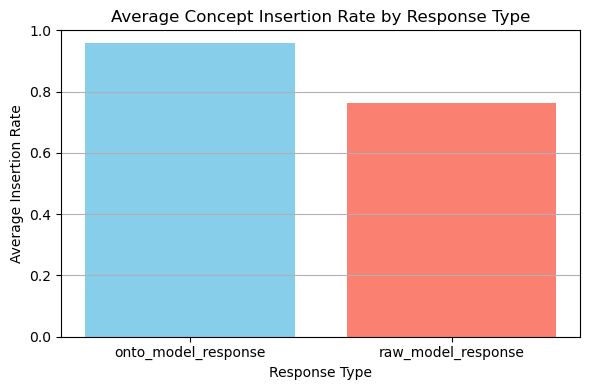


Saved results to:
- concept_insertion_results.csv
- concept_insertion_summary.png


In [4]:
import rdflib
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------
# CONFIGURATION (EDIT THIS)
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"

# ------------------------
# Load ChEBI Ontology
# ------------------------
def load_chebi_ontology(filepath):
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    subclass_map = defaultdict(set)
    for s, p, o in g:
        if str(p).endswith("subClassOf"):
            s_label = extract_label(s)
            o_label = extract_label(o)
            if s_label and o_label:
                subclass_map[s_label.lower()].add(o_label.lower())
    return subclass_map

def extract_label(uri):
    if isinstance(uri, rdflib.term.URIRef):
        return uri.split("/")[-1].replace("_", " ")
    return None

# ------------------------
# Parsing Logic
# ------------------------
def get_transitive_closure(concept, subclass_map):
    visited = set()
    to_visit = [concept]
    while to_visit:
        current = to_visit.pop()
        if current not in visited:
            visited.add(current)
            to_visit.extend(subclass_map.get(current, []))
    return visited

def extract_domain_concepts(ontology_info):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_info)
    return {m.lower().strip() for m in matches}

def extract_used_concepts(text):
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    return {w.lower().strip() for w in words}

def evaluate_response(model_name, response_type, response_text, ontology_info, subclass_map):
    domain_concepts = extract_domain_concepts(ontology_info)
    used_concepts = extract_used_concepts(response_text)

    domain_closure = set()
    for concept in domain_concepts:
        domain_closure |= get_transitive_closure(concept, subclass_map)
    domain_closure |= domain_concepts

    insertions = [c for c in used_concepts if c not in domain_closure]

    return {
        "model": model_name,
        "response_type": response_type,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1),
        "concept_insertions": insertions,
        "used_concepts": list(used_concepts),
        "domain": list(domain_concepts)
    }

# ------------------------
# Run pipeline
# ------------------------
def run_pipeline(json_path, owl_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Loaded {len(data)} records from {json_path}")

    subclass_map = load_chebi_ontology(owl_path)
    print(f"ChEBI ontology loaded with {len(subclass_map)} concept entries.")

    results = []
    for model_name, record in data.items():
        ontology_info = record.get("OntologyInfo", "")
        for response_type in ["onto_model_response", "raw_model_response"]:
            if response_type in record:
                results.append(
                    evaluate_response(model_name, response_type, record[response_type], ontology_info, subclass_map)
                )

    df = pd.DataFrame(results)

    # Save summary CSV
    df.to_csv("concept_insertion_results.csv", index=False)

    # Plot summary
    summary = df.groupby("response_type")["insertion_rate"].mean().reset_index()
    plt.figure(figsize=(6, 4))
    plt.bar(summary["response_type"], summary["insertion_rate"], color=["skyblue", "salmon"])
    plt.title("Average Concept Insertion Rate by Response Type")
    plt.ylabel("Average Insertion Rate")
    plt.xlabel("Response Type")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig("concept_insertion_summary.png")
    plt.show()

    print("\nSaved results to:")
    print("- concept_insertion_results.csv")
    print("- concept_insertion_summary.png")

# ------------------------
# Run it
# ------------------------
if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, CHEBI_OWL_PATH)


Loaded 1015 records from /home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json
ChEBI ontology loaded with 202123 concept entries.
Loaded 179 English stopwords for filtering.


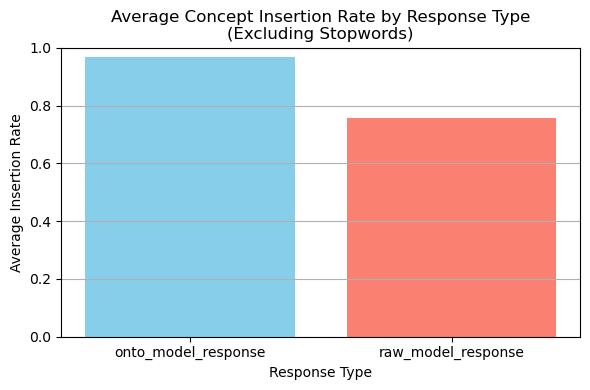


Saved results to:
- concept_insertion_results.csv
- concept_insertion_summary.png


In [2]:
import rdflib
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import nltk
from nltk.corpus import stopwords

# ------------------------
# CONFIGURATION (EDIT THIS)
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"

# ------------------------
# Download NLTK Stopwords
# ------------------------
def get_stopwords():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    return set(stopwords.words('english'))

# ------------------------
# Load ChEBI Ontology
# ------------------------
def load_chebi_ontology(filepath):
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    subclass_map = defaultdict(set)
    for s, p, o in g:
        if str(p).endswith("subClassOf"):
            s_label = extract_label(s)
            o_label = extract_label(o)
            if s_label and o_label:
                subclass_map[s_label.lower()].add(o_label.lower())
    return subclass_map

def extract_label(uri):
    if isinstance(uri, rdflib.term.URIRef):
        return uri.split("/")[-1].replace("_", " ")
    return None

# ------------------------
# Parsing Logic
# ------------------------
def get_transitive_closure(concept, subclass_map):
    visited = set()
    to_visit = [concept]
    while to_visit:
        current = to_visit.pop()
        if current not in visited:
            visited.add(current)
            to_visit.extend(subclass_map.get(current, []))
    return visited

def extract_domain_concepts(ontology_info):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_info)
    return {m.lower().strip() for m in matches}

def extract_used_concepts(text, english_stopwords):
    # Extract potential concepts (capitalized words followed by lowercase words)
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    
    # Filter out single words that are stopwords
    filtered_concepts = set()
    for word in words:
        word_lower = word.lower().strip()
        
        # Keep multi-word phrases regardless of stopwords (they're likely important concepts)
        if " " in word_lower:
            filtered_concepts.add(word_lower)
        # For single words, only keep if not a stopword
        elif word_lower not in english_stopwords:
            filtered_concepts.add(word_lower)
            
    return filtered_concepts

def evaluate_response(model_name, response_type, response_text, ontology_info, subclass_map, english_stopwords):
    domain_concepts = extract_domain_concepts(ontology_info)
    used_concepts = extract_used_concepts(response_text, english_stopwords)

    domain_closure = set()
    for concept in domain_concepts:
        domain_closure |= get_transitive_closure(concept, subclass_map)
    domain_closure |= domain_concepts

    insertions = [c for c in used_concepts if c not in domain_closure]

    return {
        "model": model_name,
        "response_type": response_type,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1),
        "concept_insertions": insertions,
        "used_concepts": list(used_concepts),
        "domain": list(domain_concepts)
    }

# ------------------------
# Run pipeline
# ------------------------
def run_pipeline(json_path, owl_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Loaded {len(data)} records from {json_path}")

    subclass_map = load_chebi_ontology(owl_path)
    print(f"ChEBI ontology loaded with {len(subclass_map)} concept entries.")
    
    english_stopwords = get_stopwords()
    print(f"Loaded {len(english_stopwords)} English stopwords for filtering.")

    results = []
    for model_name, record in data.items():
        ontology_info = record.get("OntologyInfo", "")
        for response_type in ["onto_model_response", "raw_model_response"]:
            if response_type in record:
                results.append(
                    evaluate_response(
                        model_name, 
                        response_type, 
                        record[response_type], 
                        ontology_info, 
                        subclass_map,
                        english_stopwords
                    )
                )

    df = pd.DataFrame(results)

    # Save summary CSV
    df.to_csv("concept_insertion_results.csv", index=False)

    # Plot summary
    summary = df.groupby("response_type")["insertion_rate"].mean().reset_index()
    plt.figure(figsize=(6, 4))
    plt.bar(summary["response_type"], summary["insertion_rate"], color=["skyblue", "salmon"])
    plt.title("Average Concept Insertion Rate by Response Type\n(Excluding Stopwords)")
    plt.ylabel("Average Insertion Rate")
    plt.xlabel("Response Type")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig("concept_insertion_summary_no_stopwords.png")
    plt.show()

    print("\nSaved results to:")
    print("- concept_insertion_results.csv")
    print("- concept_insertion_summary.png")

# ------------------------
# Run it
# ------------------------
if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, CHEBI_OWL_PATH)

Total records: 2030
Records with domain: 1840

Summary Statistics by Model and Response Type:
                    model        response_type  avg_insertions  \
0       deepseek-r1:14b_1  onto_model_response            95.0   
1       deepseek-r1:14b_1   raw_model_response            80.0   
2      deepseek-r1:14b_10  onto_model_response            34.0   
3      deepseek-r1:14b_10   raw_model_response            35.0   
4     deepseek-r1:14b_100  onto_model_response            37.0   
...                   ...                  ...             ...   
1835              phi4_96   raw_model_response            11.0   
1836              phi4_97  onto_model_response            34.0   
1837              phi4_97   raw_model_response             2.0   
1838              phi4_98  onto_model_response            24.0   
1839              phi4_98   raw_model_response             3.0   

      avg_insertion_rate  count  
0               0.969388      1  
1               0.987654      1  
2          

<Figure size 1200x600 with 0 Axes>

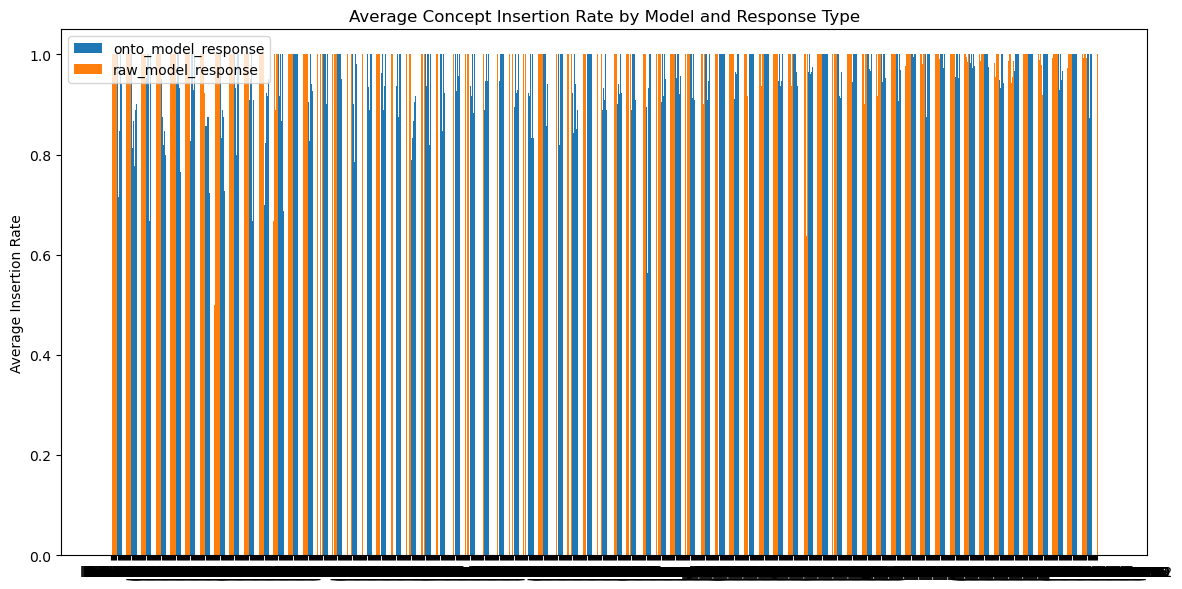

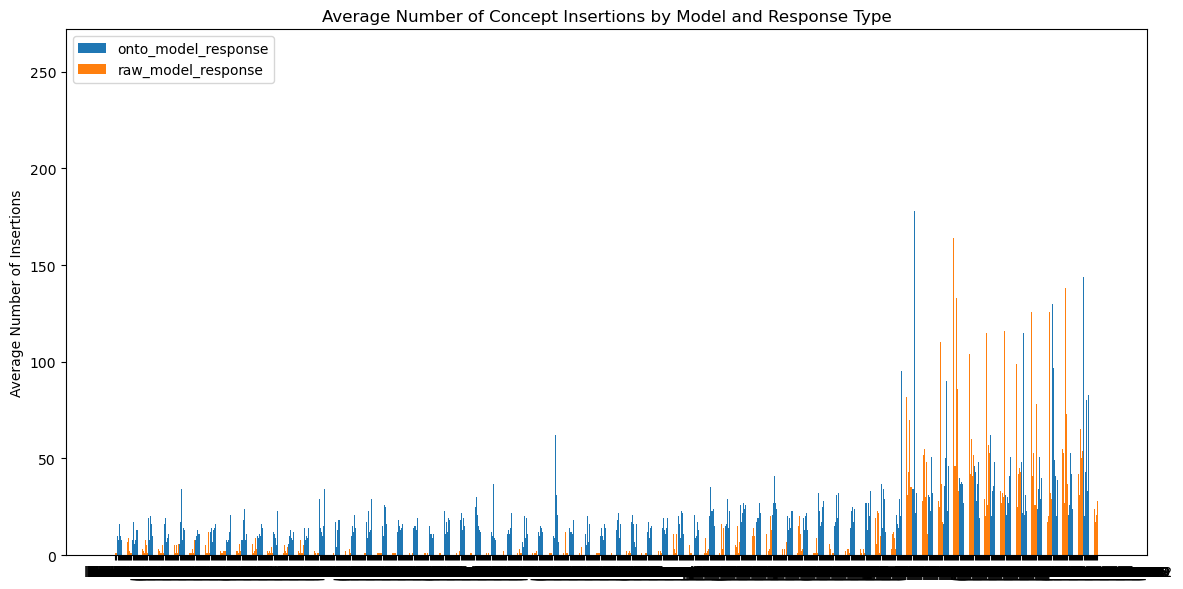

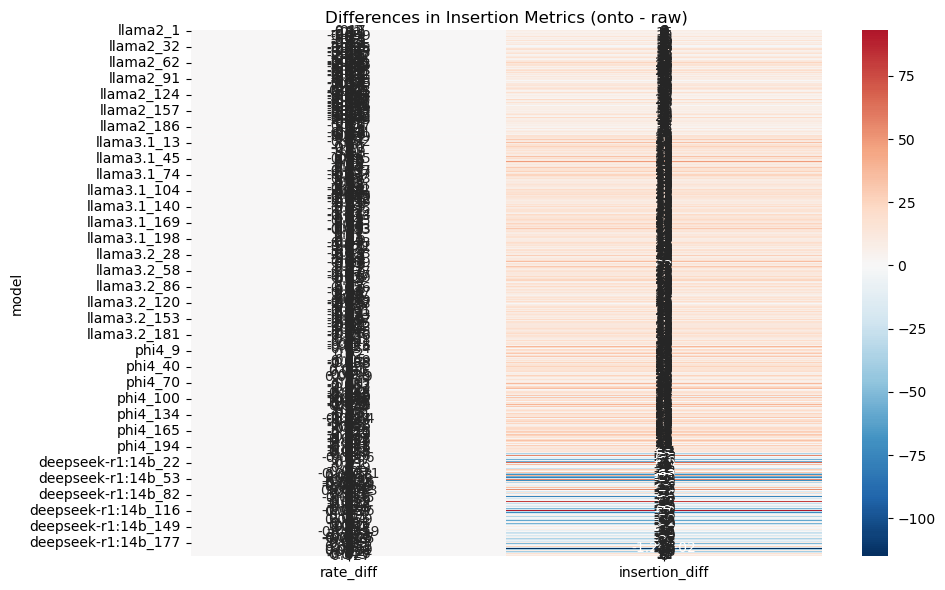

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import seaborn as sns

def analyze_concept_insertions(csv_path):
    """
    Analyze concept insertion statistics by language model for entries with detected domains.
    
    Args:
        csv_path (str): Path to the CSV file containing concept insertion results
    """
    # Read the data
    df = pd.read_csv(csv_path)
    
    # Convert string representations of lists to actual lists
    for col in ['concept_insertions', 'used_concepts', 'domain']:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    
    # Filter for records with a detected domain (non-empty domain array)
    domain_df = df[df['domain'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    
    print(f"Total records: {len(df)}")
    print(f"Records with domain: {len(domain_df)}")
    
    # Group by model and response type, calculate statistics
    stats = domain_df.groupby(['model', 'response_type']).agg({
        'num_insertions': ['mean', 'sum', 'count'],
        'insertion_rate': ['mean', 'std']
    }).reset_index()
    
    # Rename columns for clarity
    stats.columns = ['model', 'response_type', 'avg_insertions', 'total_insertions', 
                     'count', 'avg_insertion_rate', 'std_insertion_rate']
    
    # Create a pivot table for easier comparison
    pivot_stats = stats.pivot(index='model', columns='response_type')
    
    # Calculate differences between onto and raw responses
    models = domain_df['model'].unique()
    diff_data = []
    
    for model in models:
        model_data = stats[stats['model'] == model]
        
        onto_data = model_data[model_data['response_type'] == 'onto_model_response']
        raw_data = model_data[model_data['response_type'] == 'raw_model_response']
        
        if not onto_data.empty and not raw_data.empty:
            diff_data.append({
                'model': model,
                'rate_diff': onto_data['avg_insertion_rate'].values[0] - raw_data['avg_insertion_rate'].values[0],
                'insertion_diff': onto_data['avg_insertions'].values[0] - raw_data['avg_insertions'].values[0]
            })
    
    diff_df = pd.DataFrame(diff_data)
    
    # Create visualizations
    
    # 1. Bar chart of average insertion rates by model and response type
    plt.figure(figsize=(12, 6))
    
    # Prepare data for grouped bar chart
    models = []
    onto_rates = []
    raw_rates = []
    
    for model in domain_df['model'].unique():
        model_data = stats[stats['model'] == model]
        
        onto_row = model_data[model_data['response_type'] == 'onto_model_response']
        raw_row = model_data[model_data['response_type'] == 'raw_model_response']
        
        if not onto_row.empty and not raw_row.empty:
            models.append(model)
            onto_rates.append(onto_row['avg_insertion_rate'].values[0])
            raw_rates.append(raw_row['avg_insertion_rate'].values[0])
    
    # Set up bar positions
    x = np.arange(len(models))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, onto_rates, width, label='onto_model_response')
    ax.bar(x + width/2, raw_rates, width, label='raw_model_response')
    
    ax.set_ylabel('Average Insertion Rate')
    ax.set_title('Average Concept Insertion Rate by Model and Response Type')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('insertion_rates_by_model.png')
    
    # 2. Average number of insertions
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data
    onto_insertions = []
    raw_insertions = []
    
    for model in models:
        model_data = stats[stats['model'] == model]
        
        onto_row = model_data[model_data['response_type'] == 'onto_model_response']
        raw_row = model_data[model_data['response_type'] == 'raw_model_response']
        
        onto_insertions.append(onto_row['avg_insertions'].values[0])
        raw_insertions.append(raw_row['avg_insertions'].values[0])
    
    ax.bar(x - width/2, onto_insertions, width, label='onto_model_response')
    ax.bar(x + width/2, raw_insertions, width, label='raw_model_response')
    
    ax.set_ylabel('Average Number of Insertions')
    ax.set_title('Average Number of Concept Insertions by Model and Response Type')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('num_insertions_by_model.png')
    
    # 3. Heatmap of differences
    if len(diff_df) > 0:
        plt.figure(figsize=(10, 6))
        diff_pivot = diff_df.set_index('model')
        sns.heatmap(diff_pivot, annot=True, cmap='RdBu_r', center=0)
        plt.title('Differences in Insertion Metrics (onto - raw)')
        plt.tight_layout()
        plt.savefig('insertion_differences.png')
    
    # Print summary statistics
    print("\nSummary Statistics by Model and Response Type:")
    print(stats[['model', 'response_type', 'avg_insertions', 'avg_insertion_rate', 'count']])
    
    print("\nDifferences (onto - raw):")
    print(diff_df)
    
    return stats, diff_df

if __name__ == "__main__":
    # Replace with your CSV file path
    csv_path = "concept_insertion_results.csv"  # or concept_insertion_results_no_stopwords.csv
    
    analyze_concept_insertions(csv_path)
    
    print("\nAnalysis complete. Visualizations saved to:")
    print("- insertion_rates_by_model.png")
    print("- num_insertions_by_model.png")
    print("- insertion_differences.png")

Total records: 2030
Records with domain: 1840


/tmp/ipykernel_2225379/1752288614.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  domain_df['base_model'] = domain_df['model'].apply(get_base_model)
/tmp/ipykernel_2225379/1752288614.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  domain_df['base_model'] = domain_df['model'].apply(get_base_model)



Summary Statistics by Model and Response Type:
                    model        response_type  avg_insertions  \
0       deepseek-r1:14b_1  onto_model_response            95.0   
1       deepseek-r1:14b_1   raw_model_response            80.0   
2      deepseek-r1:14b_10  onto_model_response            34.0   
3      deepseek-r1:14b_10   raw_model_response            35.0   
4     deepseek-r1:14b_100  onto_model_response            37.0   
...                   ...                  ...             ...   
1835              phi4_96   raw_model_response            11.0   
1836              phi4_97  onto_model_response            34.0   
1837              phi4_97   raw_model_response             2.0   
1838              phi4_98  onto_model_response            24.0   
1839              phi4_98   raw_model_response             3.0   

      avg_insertion_rate  count  
0               0.969388      1  
1               0.987654      1  
2               1.000000      1  
3               1.00000

<Figure size 1400x1000 with 0 Axes>

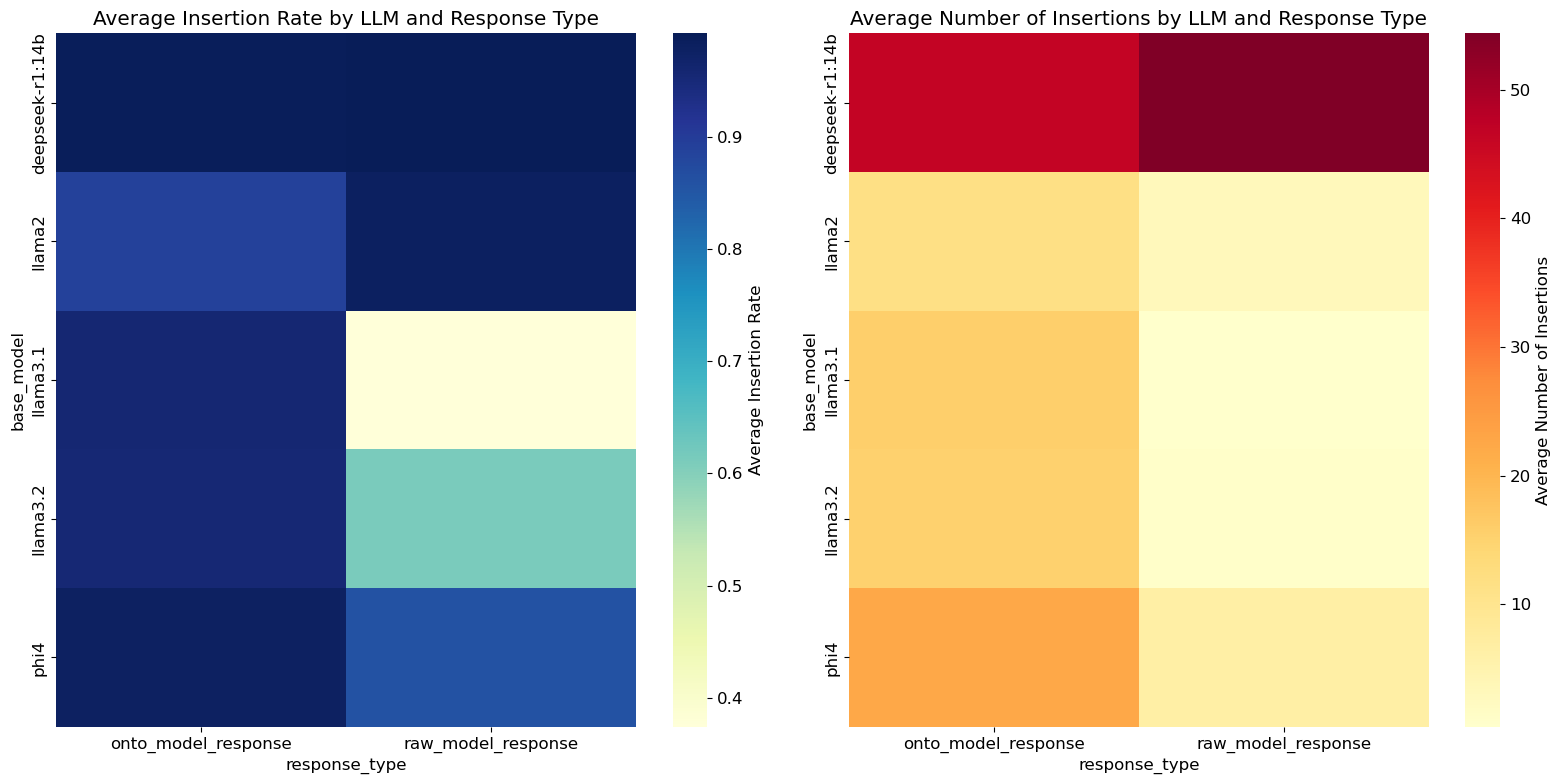

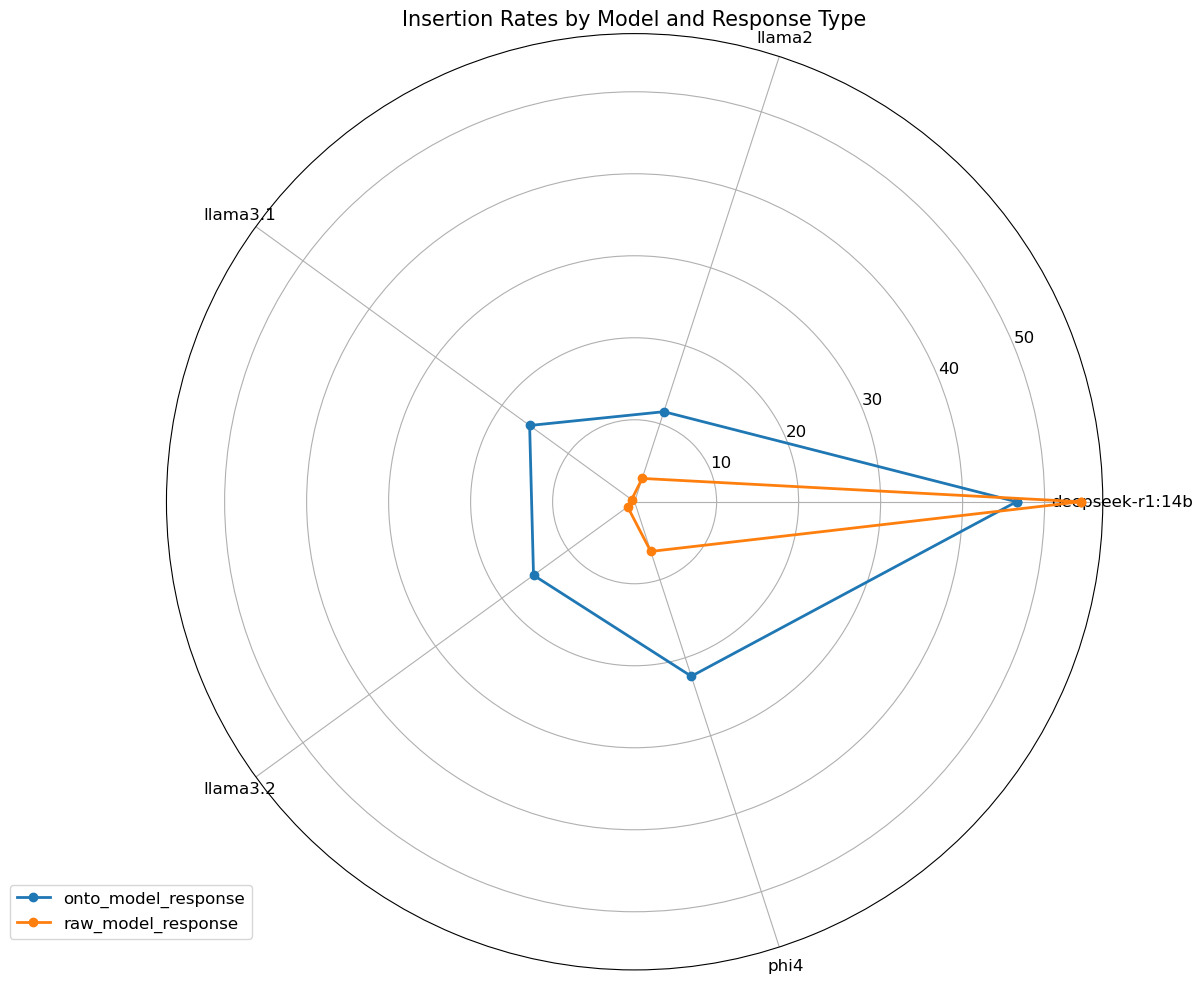

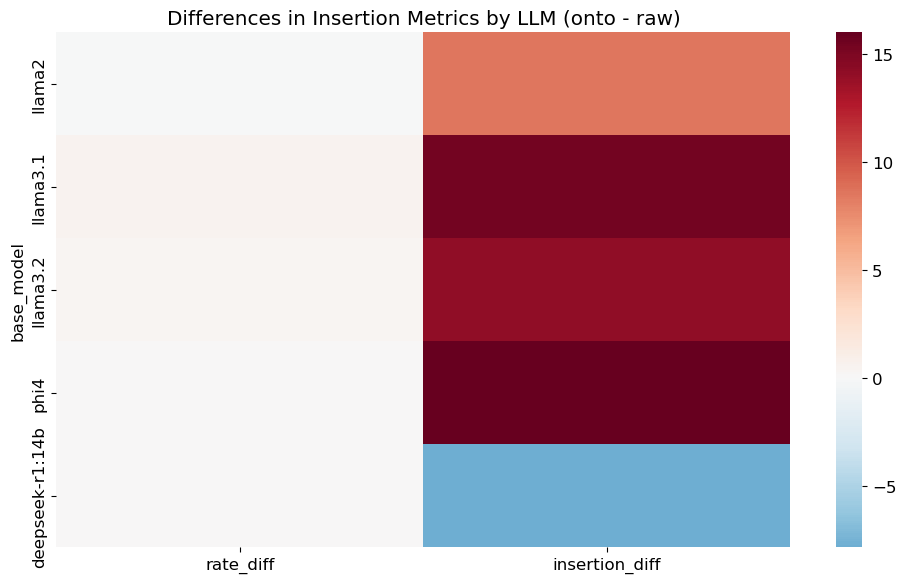

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import seaborn as sns
import matplotlib as mpl

# Set a larger font size for better readability in plots
plt.rcParams.update({'font.size': 12})

# No longer using the radar factory function


def analyze_concept_insertions(csv_path):
    """
    Analyze concept insertion statistics by language model for entries with detected domains.
    
    Args:
        csv_path (str): Path to the CSV file containing concept insertion results
    """
    # Read the data
    df = pd.read_csv(csv_path)
    
    # Convert string representations of lists to actual lists
    for col in ['concept_insertions', 'used_concepts', 'domain']:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    
    # Filter for records with a detected domain (non-empty domain array)
    domain_df = df[df['domain'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    
    print(f"Total records: {len(df)}")
    print(f"Records with domain: {len(domain_df)}")
    
    # Group by model and response type, calculate statistics
    stats = domain_df.groupby(['model', 'response_type']).agg({
        'num_insertions': ['mean', 'sum', 'count'],
        'insertion_rate': ['mean', 'std']
    }).reset_index()
    
    # Rename columns for clarity
    stats.columns = ['model', 'response_type', 'avg_insertions', 'total_insertions', 
                     'count', 'avg_insertion_rate', 'std_insertion_rate']
    
    # Create a pivot table for easier comparison
    pivot_stats = stats.pivot(index='model', columns='response_type')
    
    # Calculate differences between onto and raw responses
    models = domain_df['model'].unique()
    diff_data = []
    
    for model in models:
        model_data = stats[stats['model'] == model]
        
        onto_data = model_data[model_data['response_type'] == 'onto_model_response']
        raw_data = model_data[model_data['response_type'] == 'raw_model_response']
        
        if not onto_data.empty and not raw_data.empty:
            diff_data.append({
                'model': model,
                'rate_diff': onto_data['avg_insertion_rate'].values[0] - raw_data['avg_insertion_rate'].values[0],
                'insertion_diff': onto_data['avg_insertions'].values[0] - raw_data['avg_insertions'].values[0]
            })
    
    diff_df = pd.DataFrame(diff_data)
    
    # Create visualizations
    
    # 1. Heatmap of average insertion rates and counts by model and response type
    plt.figure(figsize=(14, 10))
    
    # Extract the base LLM names (before the underscore)
    def get_base_model(model_name):
        # Extract the name before the underscore (e.g., 'llama2' from 'llama2_0')
        return model_name.split('_')[0] if '_' in model_name else model_name
    
    # Add base model column
    domain_df['base_model'] = domain_df['model'].apply(get_base_model)
    
    # Reshape data for the heatmap, using base_model instead of model
    heatmap_data = []
    for base_model in domain_df['base_model'].unique():
        model_data = domain_df[domain_df['base_model'] == base_model]
        
        for response_type in ['onto_model_response', 'raw_model_response']:
            type_data = model_data[model_data['response_type'] == response_type]
            
            if not type_data.empty:
                heatmap_data.append({
                    'base_model': base_model,
                    'response_type': response_type,
                    'avg_insertion_rate': type_data['insertion_rate'].mean(),
                    'avg_insertions': type_data['num_insertions'].mean(),
                    'count': len(type_data)
                })
    
    heatmap_df = pd.DataFrame(heatmap_data)
    
    # Create pivot tables for the heatmaps
    rate_pivot = heatmap_df.pivot(index='base_model', columns='response_type', values='avg_insertion_rate')
    insertion_pivot = heatmap_df.pivot(index='base_model', columns='response_type', values='avg_insertions')
    
    # Plot heatmaps without annotations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Average insertion rate heatmap
    sns.heatmap(rate_pivot, annot=False, cmap="YlGnBu", ax=ax1, cbar_kws={'label': 'Average Insertion Rate'})
    ax1.set_title('Average Insertion Rate by LLM and Response Type')
    
    # Average insertions heatmap
    sns.heatmap(insertion_pivot, annot=False, cmap="YlOrRd", ax=ax2, cbar_kws={'label': 'Average Number of Insertions'})
    ax2.set_title('Average Number of Insertions by LLM and Response Type')
    
    plt.tight_layout()
    plt.savefig('insertion_heatmaps.png')
    
    # 2. Create a radar chart showing LLMs on spokes and two lines for response types
    # Extract the base LLM names (before the underscore)
    def get_base_model(model_name):
        # Extract the name before the underscore (e.g., 'llama2' from 'llama2_0')
        return model_name.split('_')[0] if '_' in model_name else model_name
    
    # Add base model column and group by it
    domain_df['base_model'] = domain_df['model'].apply(get_base_model)
    
    # Group by base model and response type to get average insertions
    llm_stats = domain_df.groupby(['base_model', 'response_type']).agg({
        'num_insertions': 'mean',
        'insertion_rate': 'mean'
    }).reset_index()
    
    # Get all unique base LLM models
    llm_models = sorted(llm_stats['base_model'].unique())
    
    # Create a pivot table for the radar chart
    radar_pivot = llm_stats.pivot(index='base_model', columns='response_type', values='num_insertions')
    
    # Make sure both response types exist for each model
    if ('onto_model_response' in radar_pivot.columns and 
        'raw_model_response' in radar_pivot.columns):
        
        # Create radar chart
        fig = plt.figure(figsize=(12, 10))
        
        # Set up the radar chart parameters
        num_llms = len(llm_models)
        angles = np.linspace(0, 2*np.pi, num_llms, endpoint=False).tolist()
        angles += angles[:1]  # Close the loop
        
        # Create plot
        ax = plt.subplot(111, polar=True)
        
        # Get values for each response type
        onto_values = [radar_pivot.loc[model, 'onto_model_response'] 
                      if model in radar_pivot.index and not pd.isna(radar_pivot.loc[model, 'onto_model_response']) 
                      else 0 
                      for model in llm_models]
        
        raw_values = [radar_pivot.loc[model, 'raw_model_response'] 
                     if model in radar_pivot.index and not pd.isna(radar_pivot.loc[model, 'raw_model_response']) 
                     else 0 
                     for model in llm_models]
        
        # Close the loop for both lines
        onto_values += onto_values[:1]
        raw_values += raw_values[:1]
        
        # Extend the model labels to close the loop
        llm_labels = llm_models.copy()
        llm_labels += [llm_labels[0]]
        
        # Plot lines
        ax.plot(angles, onto_values, 'o-', linewidth=2, label='onto_model_response')
        ax.plot(angles, raw_values, 'o-', linewidth=2, label='raw_model_response')
        
        # Add LLM model labels to the spokes
        ax.set_xticks(angles[:-1])  # Don't include the last angle which is just for closing the loop
        ax.set_xticklabels(llm_models)
        
        # Add legend
        plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
        
        plt.title('Average Number of Concept Insertions by LLM Model', size=15)
        plt.tight_layout()
        plt.savefig('insertions_radar.png')
    
    plt.title('Insertion Rates by Model and Response Type', size=15)
    plt.tight_layout()
    plt.savefig('insertion_radar.png')
    
    # 3. Heatmap of differences without annotations
    # Create difference dataframe using base_model instead of model
    diff_data = []
    for base_model in domain_df['base_model'].unique():
        base_model_data = domain_df[domain_df['base_model'] == base_model]
        
        onto_data = base_model_data[base_model_data['response_type'] == 'onto_model_response']
        raw_data = base_model_data[base_model_data['response_type'] == 'raw_model_response']
        
        if not onto_data.empty and not raw_data.empty:
            diff_data.append({
                'base_model': base_model,
                'rate_diff': onto_data['insertion_rate'].mean() - raw_data['insertion_rate'].mean(),
                'insertion_diff': onto_data['num_insertions'].mean() - raw_data['num_insertions'].mean()
            })
    
    diff_df = pd.DataFrame(diff_data)
    
    if len(diff_df) > 0:
        plt.figure(figsize=(10, 6))
        diff_pivot = diff_df.set_index('base_model')
        sns.heatmap(diff_pivot, annot=False, cmap='RdBu_r', center=0)
        plt.title('Differences in Insertion Metrics by LLM (onto - raw)')
        plt.tight_layout()
        plt.savefig('insertion_differences.png')
    
    # Print summary statistics
    print("\nSummary Statistics by Model and Response Type:")
    print(stats[['model', 'response_type', 'avg_insertions', 'avg_insertion_rate', 'count']])
    
    print("\nDifferences (onto - raw):")
    print(diff_df)
    
    return stats, diff_df

if __name__ == "__main__":
    # Replace with your CSV file path
    csv_path = "concept_insertion_results.csv"  # or concept_insertion_results_no_stopwords.csv
    
    analyze_concept_insertions(csv_path)
    
    print("\nAnalysis complete. Visualizations saved to:")
    print("- insertion_heatmaps.png")
    print("- insertions_radar.png")
    print("- insertion_differences.png")

Loaded 1015 records from /home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json
ChEBI ontology loaded with 202123 superclass and 13209 subclass relations.
Loaded 179 English stopwords for filtering.

Saved results to:
- concept_insertion_results_bidirectional.csv
- concept_insertion_summary_bidirectional.png
- insertion_heatmap_bidirectional.png
- insertions_radar_bidirectional.png


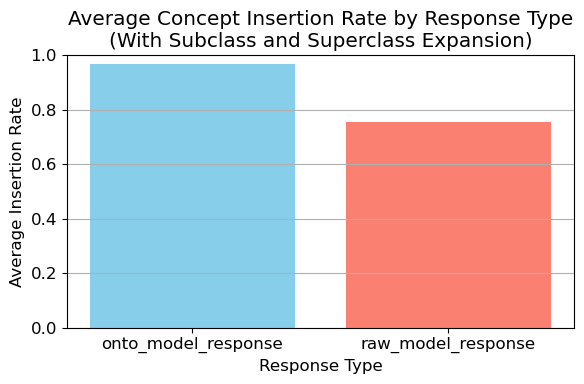

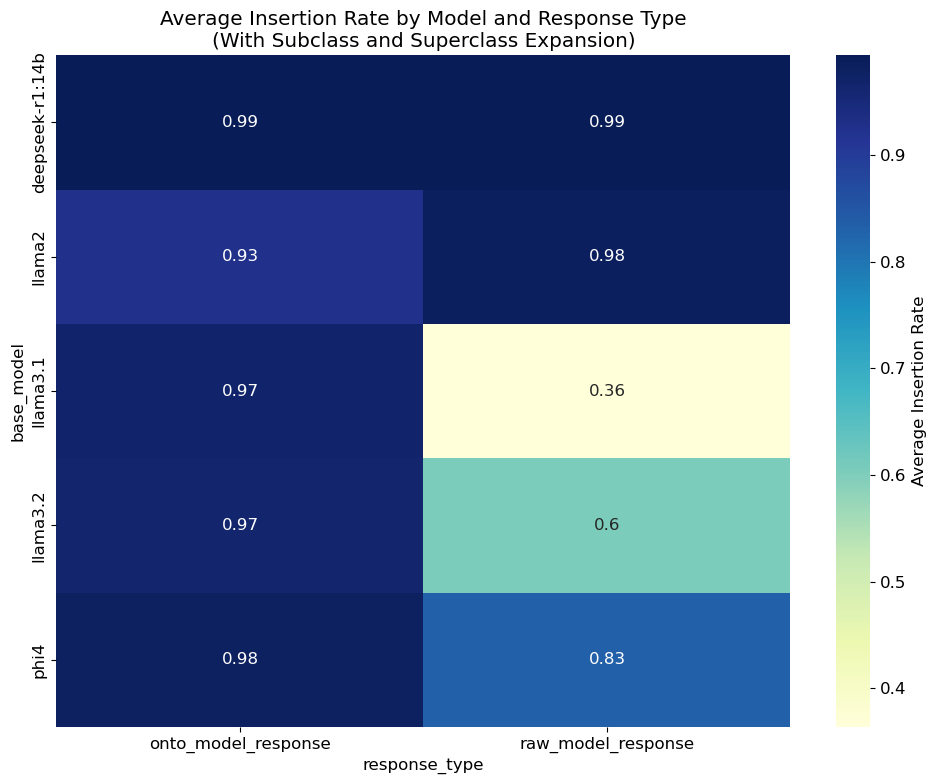

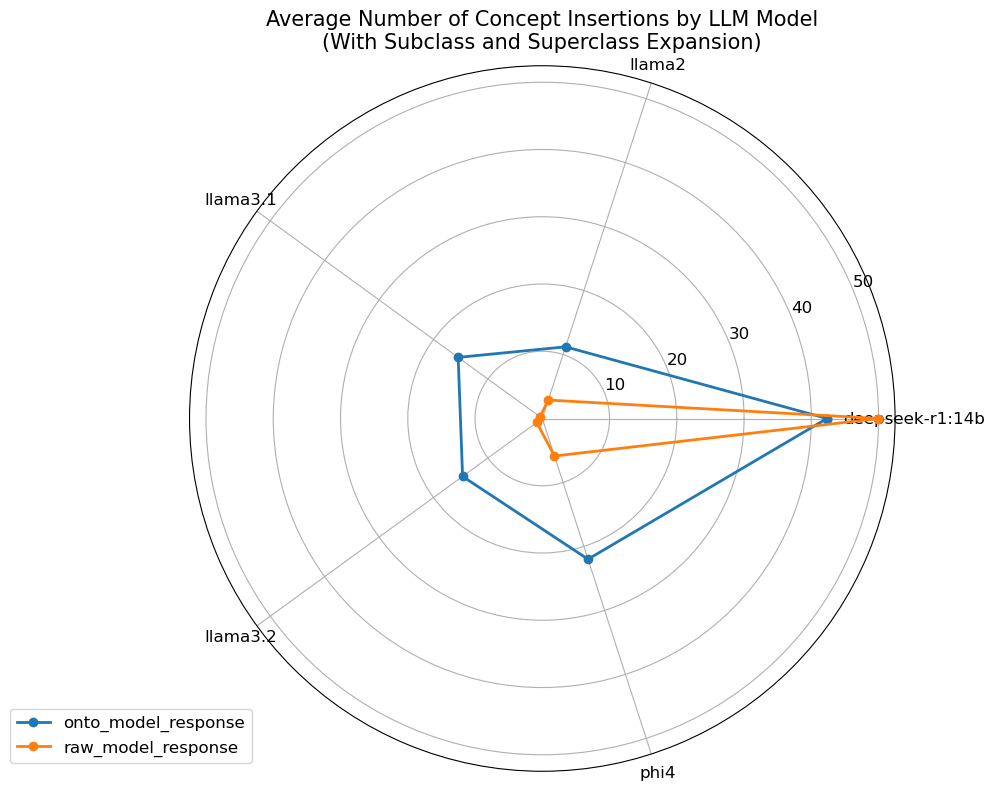

In [7]:
import rdflib
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import nltk
from nltk.corpus import stopwords

# ------------------------
# CONFIGURATION (EDIT THIS)
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"

# ------------------------
# Download NLTK Stopwords
# ------------------------
def get_stopwords():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    return set(stopwords.words('english'))

# ------------------------
# Load ChEBI Ontology
# ------------------------
def load_chebi_ontology(filepath):
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    
    # Create both superclass and subclass maps
    superclass_map = defaultdict(set)
    subclass_map = defaultdict(set)
    
    for s, p, o in g:
        if str(p).endswith("subClassOf"):
            s_label = extract_label(s)
            o_label = extract_label(o)
            if s_label and o_label:
                # s is a subclass of o
                superclass_map[s_label.lower()].add(o_label.lower())
                # o is a superclass of s
                subclass_map[o_label.lower()].add(s_label.lower())
    
    return superclass_map, subclass_map

def extract_label(uri):
    if isinstance(uri, rdflib.term.URIRef):
        return uri.split("/")[-1].replace("_", " ")
    return None

# ------------------------
# Parsing Logic
# ------------------------
def get_bidirectional_closure(concept, superclass_map, subclass_map):
    """
    Get both superclasses and subclasses of a concept recursively.
    """
    # First get superclass closure
    super_visited = set()
    super_to_visit = [concept]
    while super_to_visit:
        current = super_to_visit.pop()
        if current not in super_visited:
            super_visited.add(current)
            super_to_visit.extend(superclass_map.get(current, []))
    
    # Then get subclass closure
    sub_visited = set()
    sub_to_visit = [concept]
    while sub_to_visit:
        current = sub_to_visit.pop()
        if current not in sub_visited:
            sub_visited.add(current)
            sub_to_visit.extend(subclass_map.get(current, []))
    
    # Combine both closures
    return super_visited.union(sub_visited)

def extract_domain_concepts(ontology_info):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_info)
    return {m.lower().strip() for m in matches}

def extract_used_concepts(text, english_stopwords):
    # Extract potential concepts (capitalized words followed by lowercase words)
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    
    # Filter out single words that are stopwords
    filtered_concepts = set()
    for word in words:
        word_lower = word.lower().strip()
        
        # Keep multi-word phrases regardless of stopwords (they're likely important concepts)
        if " " in word_lower:
            filtered_concepts.add(word_lower)
        # For single words, only keep if not a stopword
        elif word_lower not in english_stopwords:
            filtered_concepts.add(word_lower)
            
    return filtered_concepts

def evaluate_response(model_name, response_type, response_text, ontology_info, superclass_map, subclass_map, english_stopwords):
    domain_concepts = extract_domain_concepts(ontology_info)
    used_concepts = extract_used_concepts(response_text, english_stopwords)

    # Get bidirectional closure for each domain concept (include both superclasses and subclasses)
    domain_closure = set()
    for concept in domain_concepts:
        domain_closure |= get_bidirectional_closure(concept, superclass_map, subclass_map)
    domain_closure |= domain_concepts  # Include original domain concepts

    # Concepts used in response but not in domain closure are insertions
    insertions = [c for c in used_concepts if c not in domain_closure]

    return {
        "model": model_name,
        "response_type": response_type,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1),
        "concept_insertions": insertions,
        "used_concepts": list(used_concepts),
        "domain": list(domain_concepts),
        "domain_closure_size": len(domain_closure)
    }

# ------------------------
# Run pipeline
# ------------------------
def run_pipeline(json_path, owl_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Loaded {len(data)} records from {json_path}")

    superclass_map, subclass_map = load_chebi_ontology(owl_path)
    print(f"ChEBI ontology loaded with {len(superclass_map)} superclass and {len(subclass_map)} subclass relations.")
    
    english_stopwords = get_stopwords()
    print(f"Loaded {len(english_stopwords)} English stopwords for filtering.")

    results = []
    for model_name, record in data.items():
        ontology_info = record.get("OntologyInfo", "")
        for response_type in ["onto_model_response", "raw_model_response"]:
            if response_type in record:
                results.append(
                    evaluate_response(
                        model_name, 
                        response_type, 
                        record[response_type], 
                        ontology_info, 
                        superclass_map,
                        subclass_map,
                        english_stopwords
                    )
                )

    df = pd.DataFrame(results)

    # Save summary CSV
    df.to_csv("concept_insertion_results_bidirectional.csv", index=False)

    # Plot summary
    summary = df.groupby("response_type")["insertion_rate"].mean().reset_index()
    plt.figure(figsize=(6, 4))
    plt.bar(summary["response_type"], summary["insertion_rate"], color=["skyblue", "salmon"])
    plt.title("Average Concept Insertion Rate by Response Type\n(With Subclass and Superclass Expansion)")
    plt.ylabel("Average Insertion Rate")
    plt.xlabel("Response Type")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig("concept_insertion_summary_bidirectional.png")
    
    # Compare with previous approach - create basic heatmap
    models = sorted(df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x).unique())
    response_types = ['onto_model_response', 'raw_model_response']
    
    # Create a pivot table of insertion rates
    pivot_df = df.copy()
    pivot_df['base_model'] = pivot_df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x)
    pivot_table = pivot_df.groupby(['base_model', 'response_type'])['insertion_rate'].mean().unstack()
    
    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Average Insertion Rate'})
    plt.title('Average Insertion Rate by Model and Response Type\n(With Subclass and Superclass Expansion)')
    plt.tight_layout()
    plt.savefig("insertion_heatmap_bidirectional.png")
    
    # Create radar chart
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    # Set up the radar chart
    num_models = len(models)
    angles = np.linspace(0, 2*np.pi, num_models, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Get data for both response types
    model_stats = pivot_df.groupby(['base_model', 'response_type'])['num_insertions'].mean().unstack(fill_value=0)
    
    if 'onto_model_response' in model_stats.columns and 'raw_model_response' in model_stats.columns:
        onto_values = [model_stats.loc[model, 'onto_model_response'] if model in model_stats.index else 0 for model in models]
        raw_values = [model_stats.loc[model, 'raw_model_response'] if model in model_stats.index else 0 for model in models]
        
        # Close the loop
        onto_values += onto_values[:1]
        raw_values += raw_values[:1]
        
        # Plot the lines
        ax.plot(angles, onto_values, 'o-', linewidth=2, label='onto_model_response')
        ax.plot(angles, raw_values, 'o-', linewidth=2, label='raw_model_response')
        
        # Add labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(models)
        
        # Add legend
        plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
        
        plt.title('Average Number of Concept Insertions by LLM Model\n(With Subclass and Superclass Expansion)', size=15)
        plt.tight_layout()
        plt.savefig('insertions_radar_bidirectional.png')
    
    print("\nSaved results to:")
    print("- concept_insertion_results_bidirectional.csv")
    print("- concept_insertion_summary_bidirectional.png")
    print("- insertion_heatmap_bidirectional.png")
    print("- insertions_radar_bidirectional.png")

# ------------------------
# Run it
# ------------------------
if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, CHEBI_OWL_PATH)

Loaded 1015 records from /home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json
ChEBI ontology loaded with 202123 superclass and 13209 subclass relations.
Loaded 308 enhanced stopwords and 23 common phrases for strict filtering.

Saved results to:
- concept_insertion_results_strict.csv
- concept_insertion_summary_strict.png
- insertion_heatmap_strict.png
- insertions_radar_strict.png


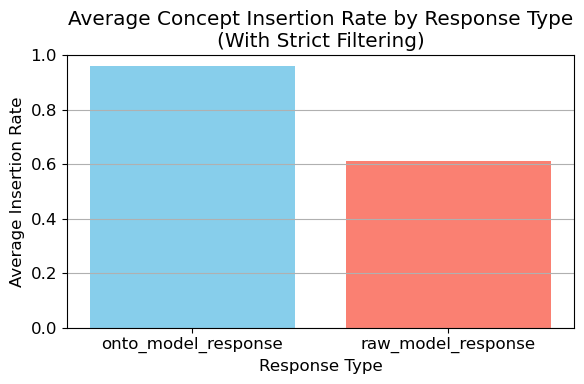

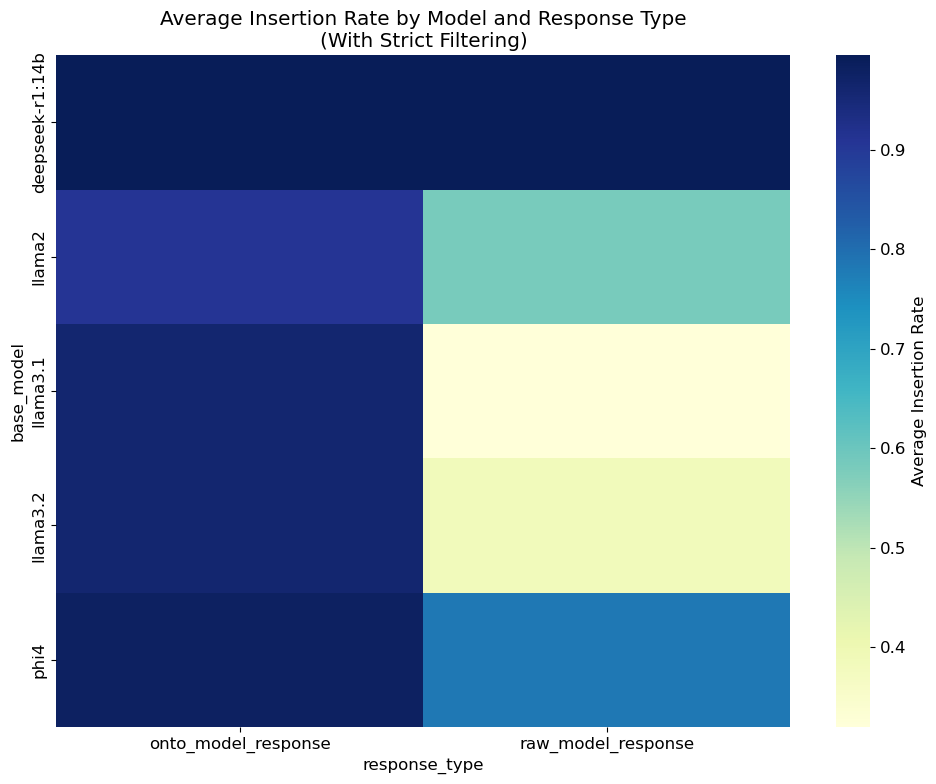

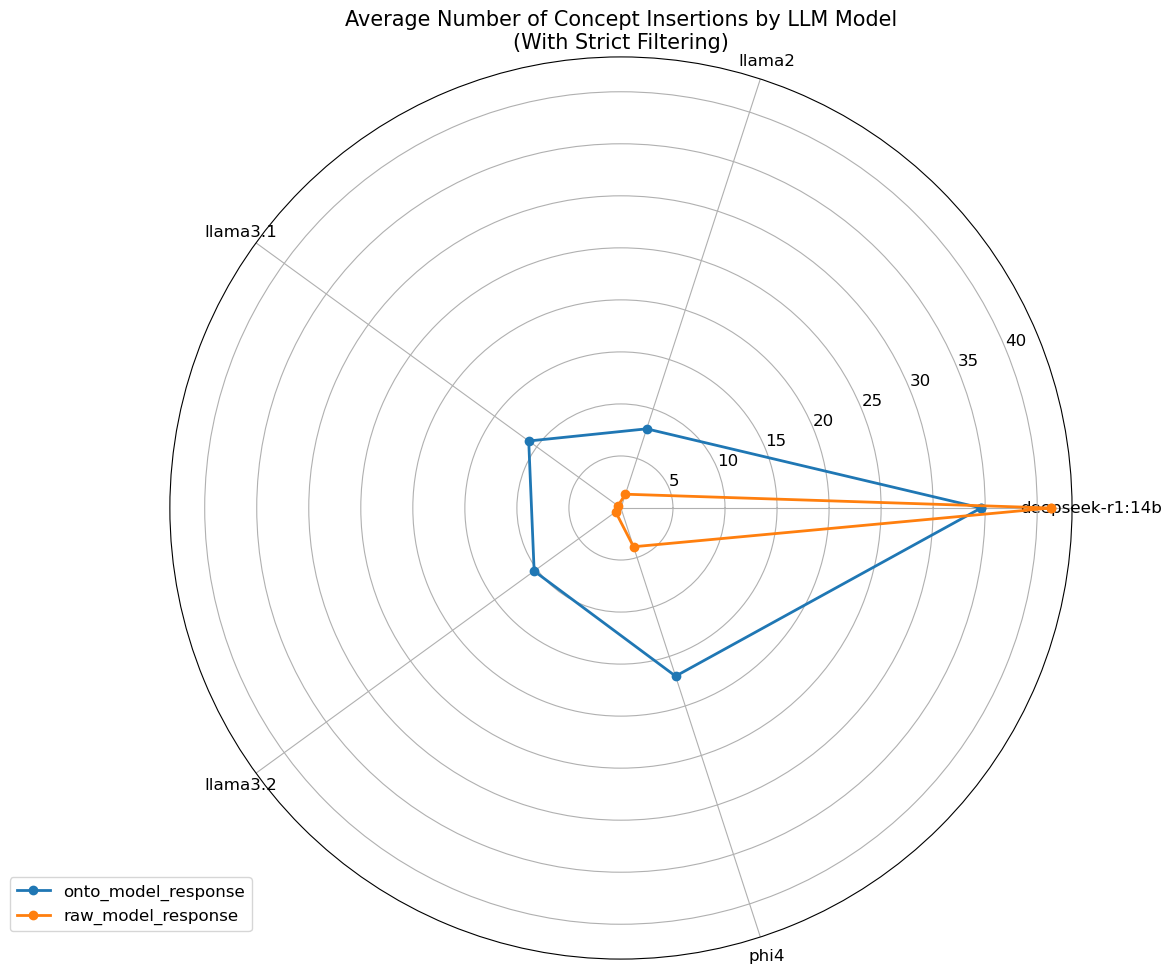

In [8]:
import rdflib
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict
import nltk
from nltk.corpus import stopwords
import string

# ------------------------
# CONFIGURATION (EDIT THIS)
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"

# ------------------------
# Enhanced Stopwords
# ------------------------
def get_enhanced_stopwords():
    """
    Get an enhanced set of stopwords including:
    - Standard NLTK English stopwords
    - Common prepositions, articles, and conjunctions
    - Common verbs and auxiliary words
    - Chemical terminology that isn't domain-specific (e.g., 'formula', 'substance')
    """
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    
    # Start with standard stopwords
    standard_stopwords = set(stopwords.words('english'))
    
    # Add common non-domain-specific words often found in scientific explanations
    additional_stopwords = {
        # Common scientific/explanation words
        'answer', 'correct', 'incorrectly', 'correctly', 'question', 'explanation',
        'solution', 'problem', 'result', 'example', 'figure', 'diagram', 'table',
        'using', 'shows', 'indicates', 'determine', 'calculate', 'solve',
        'means', 'therefore', 'thus', 'hence', 'consequently', 'accordingly',
        'first', 'second', 'third', 'fourth', 'fifth', 'final', 'finally',
        
        # Common chemical terminology that isn't domain-specific
        'formula', 'substance', 'compound', 'element', 'reaction', 'chemical',
        'properties', 'value', 'values', 'concentration', 'process', 'form',
        'forms', 'formed', 'forming', 'type', 'types', 'structure',
        
        # Additional prepositions, conjunctions, articles
        'regarding', 'concerning', 'according', 'whereas', 'whereby',
        'onto', 'into', 'upon', 'besides', 'amongst', 'amid', 'whether',
        
        # Common modal verbs and auxiliaries
        'would', 'could', 'should', 'might', 'may', 'can', 'will', 'shall',
        'must', 'ought', 'need', 'dare', 'used',
        
        # Common adverbs
        'very', 'quite', 'rather', 'somewhat', 'relatively', 'absolutely',
        'extremely', 'fairly', 'slightly', 'highly', 'particularly',
        
        # Domain-generic scientific terms
        'analysis', 'data', 'information', 'theory', 'experiment', 'observation',
        'study', 'research', 'model', 'method', 'procedure', 'technique',
        'equipment', 'instrument', 'apparatus', 'device', 'measurement',
        
        # Other common words in explanations
        'based', 'following', 'given', 'shown', 'related', 'associated',
        'similar', 'different', 'various', 'several', 'multiple', 'specific',
        'certain', 'particular', 'general', 'overall', 'main', 'key', 'primary',
        'secondary', 'important', 'significant', 'essential', 'crucial', 'critical',
        'appropriate', 'suitable', 'adequate', 'sufficient', 'necessary', 'required'
    }
    
    # Common phrases to filter (will be converted to lowercase for comparison)
    common_phrases = {
        'in order to', 'due to the', 'as a result', 'on the other hand',
        'with respect to', 'in terms of', 'in addition to', 'in contrast to',
        'in the case of', 'according to the', 'based on the', 'for example',
        'for instance', 'in this case', 'such as', 'in general',
        'as well as', 'refers to', 'defined as', 'classified as',
        'considered to be', 'known as', 'described as'
    }
    
    # Combine all stopwords
    combined_stopwords = standard_stopwords.union(additional_stopwords)
    
    return combined_stopwords, common_phrases

# ------------------------
# Load ChEBI Ontology
# ------------------------
def load_chebi_ontology(filepath):
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    
    # Create both superclass and subclass maps
    superclass_map = defaultdict(set)
    subclass_map = defaultdict(set)
    
    for s, p, o in g:
        if str(p).endswith("subClassOf"):
            s_label = extract_label(s)
            o_label = extract_label(o)
            if s_label and o_label:
                # s is a subclass of o
                superclass_map[s_label.lower()].add(o_label.lower())
                # o is a superclass of s
                subclass_map[o_label.lower()].add(s_label.lower())
    
    return superclass_map, subclass_map

def extract_label(uri):
    if isinstance(uri, rdflib.term.URIRef):
        return uri.split("/")[-1].replace("_", " ")
    return None

# ------------------------
# Parsing Logic
# ------------------------
def get_bidirectional_closure(concept, superclass_map, subclass_map):
    """
    Get both superclasses and subclasses of a concept recursively.
    """
    # First get superclass closure
    super_visited = set()
    super_to_visit = [concept]
    while super_to_visit:
        current = super_to_visit.pop()
        if current not in super_visited:
            super_visited.add(current)
            super_to_visit.extend(superclass_map.get(current, []))
    
    # Then get subclass closure
    sub_visited = set()
    sub_to_visit = [concept]
    while sub_to_visit:
        current = sub_to_visit.pop()
        if current not in sub_visited:
            sub_visited.add(current)
            sub_to_visit.extend(subclass_map.get(current, []))
    
    # Combine both closures
    return super_visited.union(sub_visited)

def extract_domain_concepts(ontology_info):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_info)
    return {m.lower().strip() for m in matches}

def remove_punctuation(text):
    """Remove punctuation from text"""
    return text.translate(str.maketrans('', '', string.punctuation))

def contains_phrase(text, phrase):
    """Check if text contains a phrase (case-insensitive)"""
    return phrase.lower() in text.lower()

def extract_used_concepts(text, enhanced_stopwords, common_phrases):
    # Clean the text for better concept extraction
    text_lower = text.lower()
    
    # Remove common phrases before concept extraction
    for phrase in common_phrases:
        text_lower = text_lower.replace(phrase, ' ')
    
    # Extract potential concepts (capitalized words followed by lowercase words)
    # Using the original text for extraction to maintain case information
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    
    # Filter out stopwords and apply stricter filtering
    filtered_concepts = set()
    for word in words:
        word_lower = word.lower().strip()
        word_no_punct = remove_punctuation(word_lower)
        
        # Skip very short words (likely abbreviations or not meaningful concepts)
        if len(word_no_punct) < 3:
            continue
            
        # Multi-word phrases - keep only if none of the words are stopwords
        if " " in word_lower:
            parts = word_lower.split()
            # Skip if all parts are stopwords or very short
            if all(part in enhanced_stopwords or len(part) < 3 for part in parts):
                continue
            # Skip if phrase contains numbers
            if any(char.isdigit() for char in word_lower):
                continue
            filtered_concepts.add(word_lower)
        # Single words - only keep if not a stopword and not too short
        elif word_no_punct not in enhanced_stopwords and len(word_no_punct) >= 3:
            filtered_concepts.add(word_lower)
    
    return filtered_concepts

def evaluate_response(model_name, response_type, response_text, ontology_info, superclass_map, subclass_map, enhanced_stopwords, common_phrases):
    domain_concepts = extract_domain_concepts(ontology_info)
    used_concepts = extract_used_concepts(response_text, enhanced_stopwords, common_phrases)

    # Get bidirectional closure for each domain concept (include both superclasses and subclasses)
    domain_closure = set()
    for concept in domain_concepts:
        domain_closure |= get_bidirectional_closure(concept, superclass_map, subclass_map)
    domain_closure |= domain_concepts  # Include original domain concepts

    # Concepts used in response but not in domain closure are insertions
    insertions = [c for c in used_concepts if c not in domain_closure]

    return {
        "model": model_name,
        "response_type": response_type,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1),
        "concept_insertions": insertions,
        "used_concepts": list(used_concepts),
        "domain": list(domain_concepts),
        "domain_closure_size": len(domain_closure)
    }

# ------------------------
# Run pipeline
# ------------------------
def run_pipeline(json_path, owl_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Loaded {len(data)} records from {json_path}")

    superclass_map, subclass_map = load_chebi_ontology(owl_path)
    print(f"ChEBI ontology loaded with {len(superclass_map)} superclass and {len(subclass_map)} subclass relations.")
    
    enhanced_stopwords, common_phrases = get_enhanced_stopwords()
    print(f"Loaded {len(enhanced_stopwords)} enhanced stopwords and {len(common_phrases)} common phrases for strict filtering.")

    results = []
    for model_name, record in data.items():
        ontology_info = record.get("OntologyInfo", "")
        for response_type in ["onto_model_response", "raw_model_response"]:
            if response_type in record:
                results.append(
                    evaluate_response(
                        model_name, 
                        response_type, 
                        record[response_type], 
                        ontology_info, 
                        superclass_map,
                        subclass_map,
                        enhanced_stopwords,
                        common_phrases
                    )
                )

    df = pd.DataFrame(results)

    # Save summary CSV
    df.to_csv("concept_insertion_results_strict.csv", index=False)

    # Plot summary
    summary = df.groupby("response_type")["insertion_rate"].mean().reset_index()
    plt.figure(figsize=(6, 4))
    plt.bar(summary["response_type"], summary["insertion_rate"], color=["skyblue", "salmon"])
    plt.title("Average Concept Insertion Rate by Response Type\n(With Strict Filtering)")
    plt.ylabel("Average Insertion Rate")
    plt.xlabel("Response Type")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig("concept_insertion_summary_strict.png")
    
    # Extract base model names
    df['base_model'] = df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x)
    
    # Create advanced visualizations
    # 1. Heatmap of insertion rates
    model_response_pivot = df.pivot_table(
        index='base_model', 
        columns='response_type',
        values='insertion_rate', 
        aggfunc='mean'
    )
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(model_response_pivot, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Average Insertion Rate'})
    plt.title('Average Insertion Rate by Model and Response Type\n(With Strict Filtering)')
    plt.tight_layout()
    plt.savefig("insertion_heatmap_strict.png")
    
    # 2. Radar chart for insertion counts
    llm_models = sorted(df['base_model'].unique())
    
    # Create radar chart
    fig = plt.figure(figsize=(12, 10))
    
    # Set up the radar chart parameters
    num_llms = len(llm_models)
    angles = np.linspace(0, 2*np.pi, num_llms, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Create plot
    ax = plt.subplot(111, polar=True)
    
    # Group by base model and response type to get average insertions
    model_stats = df.groupby(['base_model', 'response_type'])['num_insertions'].mean().unstack(fill_value=0)
    
    if 'onto_model_response' in model_stats.columns and 'raw_model_response' in model_stats.columns:
        onto_values = [model_stats.loc[model, 'onto_model_response'] if model in model_stats.index else 0 for model in llm_models]
        raw_values = [model_stats.loc[model, 'raw_model_response'] if model in model_stats.index else 0 for model in llm_models]
        
        # Close the loop for both lines
        onto_values += onto_values[:1]
        raw_values += raw_values[:1]
        
        # Plot lines
        ax.plot(angles, onto_values, 'o-', linewidth=2, label='onto_model_response')
        ax.plot(angles, raw_values, 'o-', linewidth=2, label='raw_model_response')
        
        # Add LLM model labels to the spokes
        ax.set_xticks(angles[:-1])  # Don't include the last angle which is just for closing the loop
        ax.set_xticklabels(llm_models)
        
        # Add legend
        plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
        
        plt.title('Average Number of Concept Insertions by LLM Model\n(With Strict Filtering)', size=15)
        plt.tight_layout()
        plt.savefig('insertions_radar_strict.png')
    
    print("\nSaved results to:")
    print("- concept_insertion_results_strict.csv")
    print("- concept_insertion_summary_strict.png")
    print("- insertion_heatmap_strict.png")
    print("- insertions_radar_strict.png")

# ------------------------
# Run it
# ------------------------
if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, CHEBI_OWL_PATH)

Loaded 1015 records from /home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation1.json


ChEBI ontology loaded with 202123 superclass and 13209 subclass relations.
Loaded 308 enhanced stopwords and 23 common phrases for strict filtering.

Saved results to:
- concept_insertion_results_strict.csv
- concept_insertion_summary_strict.png
- insertion_heatmap_strict.png
- insertions_radar_strict.png


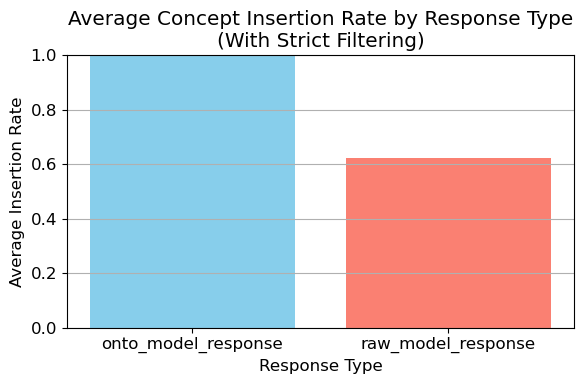

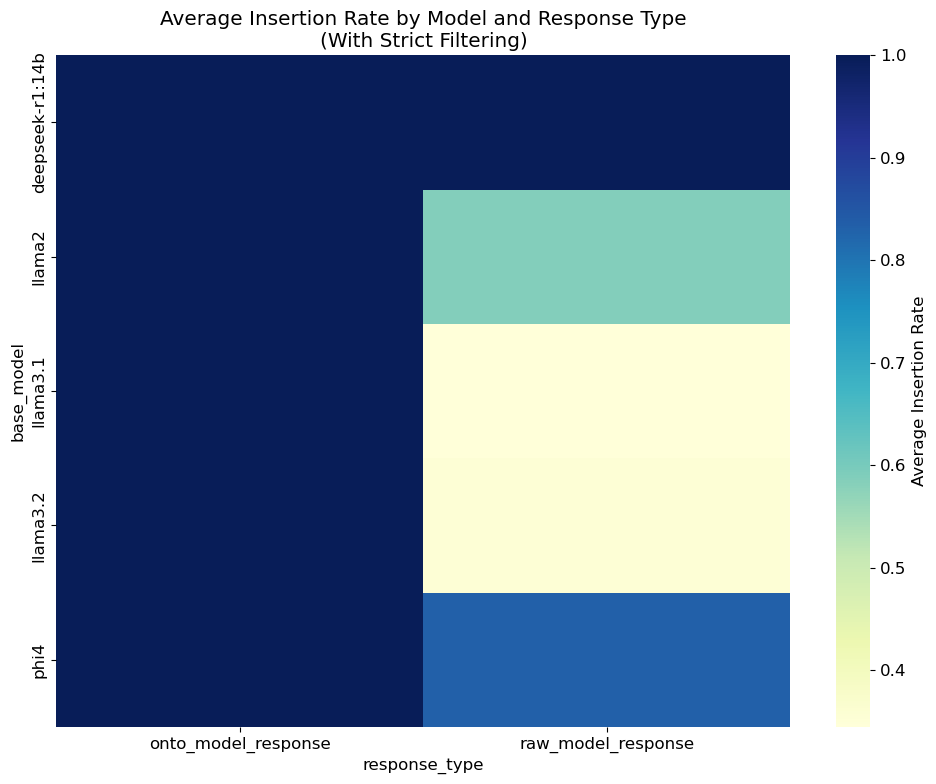

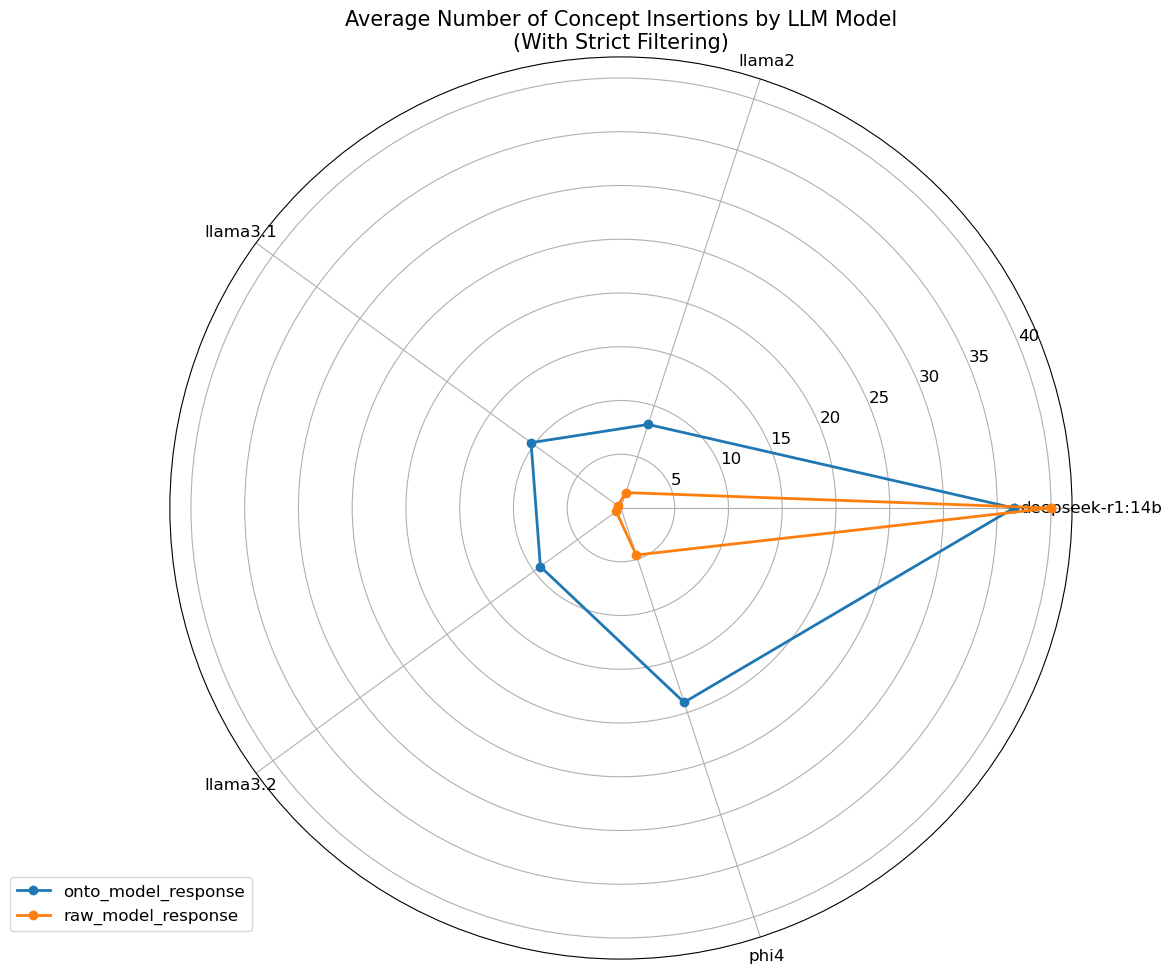

In [10]:
import rdflib
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict
import nltk
from nltk.corpus import stopwords
import string

# ------------------------
# CONFIGURATION (EDIT THIS)
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation1.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"

# ------------------------
# Enhanced Stopwords
# ------------------------
def get_enhanced_stopwords():
    """
    Get an enhanced set of stopwords including:
    - Standard NLTK English stopwords
    - Common prepositions, articles, and conjunctions
    - Common verbs and auxiliary words
    - Chemical terminology that isn't domain-specific (e.g., 'formula', 'substance')
    """
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    
    # Start with standard stopwords
    standard_stopwords = set(stopwords.words('english'))
    
    # Add common non-domain-specific words often found in scientific explanations
    additional_stopwords = {
        # Common scientific/explanation words
        'answer', 'correct', 'incorrectly', 'correctly', 'question', 'explanation',
        'solution', 'problem', 'result', 'example', 'figure', 'diagram', 'table',
        'using', 'shows', 'indicates', 'determine', 'calculate', 'solve',
        'means', 'therefore', 'thus', 'hence', 'consequently', 'accordingly',
        'first', 'second', 'third', 'fourth', 'fifth', 'final', 'finally',
        
        # Common chemical terminology that isn't domain-specific
        'formula', 'substance', 'compound', 'element', 'reaction', 'chemical',
        'properties', 'value', 'values', 'concentration', 'process', 'form',
        'forms', 'formed', 'forming', 'type', 'types', 'structure',
        
        # Additional prepositions, conjunctions, articles
        'regarding', 'concerning', 'according', 'whereas', 'whereby',
        'onto', 'into', 'upon', 'besides', 'amongst', 'amid', 'whether',
        
        # Common modal verbs and auxiliaries
        'would', 'could', 'should', 'might', 'may', 'can', 'will', 'shall',
        'must', 'ought', 'need', 'dare', 'used',
        
        # Common adverbs
        'very', 'quite', 'rather', 'somewhat', 'relatively', 'absolutely',
        'extremely', 'fairly', 'slightly', 'highly', 'particularly',
        
        # Domain-generic scientific terms
        'analysis', 'data', 'information', 'theory', 'experiment', 'observation',
        'study', 'research', 'model', 'method', 'procedure', 'technique',
        'equipment', 'instrument', 'apparatus', 'device', 'measurement',
        
        # Other common words in explanations
        'based', 'following', 'given', 'shown', 'related', 'associated',
        'similar', 'different', 'various', 'several', 'multiple', 'specific',
        'certain', 'particular', 'general', 'overall', 'main', 'key', 'primary',
        'secondary', 'important', 'significant', 'essential', 'crucial', 'critical',
        'appropriate', 'suitable', 'adequate', 'sufficient', 'necessary', 'required'
    }
    
    # Common phrases to filter (will be converted to lowercase for comparison)
    common_phrases = {
        'in order to', 'due to the', 'as a result', 'on the other hand',
        'with respect to', 'in terms of', 'in addition to', 'in contrast to',
        'in the case of', 'according to the', 'based on the', 'for example',
        'for instance', 'in this case', 'such as', 'in general',
        'as well as', 'refers to', 'defined as', 'classified as',
        'considered to be', 'known as', 'described as'
    }
    
    # Combine all stopwords
    combined_stopwords = standard_stopwords.union(additional_stopwords)
    
    return combined_stopwords, common_phrases

# ------------------------
# Load ChEBI Ontology
# ------------------------
def load_chebi_ontology(filepath):
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    
    # Create both superclass and subclass maps
    superclass_map = defaultdict(set)
    subclass_map = defaultdict(set)
    
    for s, p, o in g:
        if str(p).endswith("subClassOf"):
            s_label = extract_label(s)
            o_label = extract_label(o)
            if s_label and o_label:
                # s is a subclass of o
                superclass_map[s_label.lower()].add(o_label.lower())
                # o is a superclass of s
                subclass_map[o_label.lower()].add(s_label.lower())
    
    return superclass_map, subclass_map

def extract_label(uri):
    if isinstance(uri, rdflib.term.URIRef):
        return uri.split("/")[-1].replace("_", " ")
    return None

# ------------------------
# Parsing Logic
# ------------------------
def get_bidirectional_closure(concept, superclass_map, subclass_map):
    """
    Get both superclasses and subclasses of a concept recursively.
    """
    # First get superclass closure
    super_visited = set()
    super_to_visit = [concept]
    while super_to_visit:
        current = super_to_visit.pop()
        if current not in super_visited:
            super_visited.add(current)
            super_to_visit.extend(superclass_map.get(current, []))
    
    # Then get subclass closure
    sub_visited = set()
    sub_to_visit = [concept]
    while sub_to_visit:
        current = sub_to_visit.pop()
        if current not in sub_visited:
            sub_visited.add(current)
            sub_to_visit.extend(subclass_map.get(current, []))
    
    # Combine both closures
    return super_visited.union(sub_visited)

def extract_domain_concepts(ontology_info):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_info)
    return {m.lower().strip() for m in matches}

def remove_punctuation(text):
    """Remove punctuation from text"""
    return text.translate(str.maketrans('', '', string.punctuation))

def contains_phrase(text, phrase):
    """Check if text contains a phrase (case-insensitive)"""
    return phrase.lower() in text.lower()

def extract_used_concepts(text, enhanced_stopwords, common_phrases):
    # Clean the text for better concept extraction
    text_lower = text.lower()
    
    # Remove common phrases before concept extraction
    for phrase in common_phrases:
        text_lower = text_lower.replace(phrase, ' ')
    
    # Extract potential concepts (capitalized words followed by lowercase words)
    # Using the original text for extraction to maintain case information
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    
    # Filter out stopwords and apply stricter filtering
    filtered_concepts = set()
    for word in words:
        word_lower = word.lower().strip()
        word_no_punct = remove_punctuation(word_lower)
        
        # Skip very short words (likely abbreviations or not meaningful concepts)
        if len(word_no_punct) < 3:
            continue
            
        # Multi-word phrases - keep only if none of the words are stopwords
        if " " in word_lower:
            parts = word_lower.split()
            # Skip if all parts are stopwords or very short
            if all(part in enhanced_stopwords or len(part) < 3 for part in parts):
                continue
            # Skip if phrase contains numbers
            if any(char.isdigit() for char in word_lower):
                continue
            filtered_concepts.add(word_lower)
        # Single words - only keep if not a stopword and not too short
        elif word_no_punct not in enhanced_stopwords and len(word_no_punct) >= 3:
            filtered_concepts.add(word_lower)
    
    return filtered_concepts

def evaluate_response(model_name, response_type, response_text, ontology_info, superclass_map, subclass_map, enhanced_stopwords, common_phrases):
    domain_concepts = extract_domain_concepts(ontology_info)
    used_concepts = extract_used_concepts(response_text, enhanced_stopwords, common_phrases)

    # Get bidirectional closure for each domain concept (include both superclasses and subclasses)
    domain_closure = set()
    for concept in domain_concepts:
        domain_closure |= get_bidirectional_closure(concept, superclass_map, subclass_map)
    domain_closure |= domain_concepts  # Include original domain concepts

    # Concepts used in response but not in domain closure are insertions
    insertions = [c for c in used_concepts if c not in domain_closure]

    return {
        "model": model_name,
        "response_type": response_type,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1),
        "concept_insertions": insertions,
        "used_concepts": list(used_concepts),
        "domain": list(domain_concepts),
        "domain_closure_size": len(domain_closure)
    }

# ------------------------
# Run pipeline
# ------------------------
def run_pipeline(json_path, owl_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Loaded {len(data)} records from {json_path}")

    superclass_map, subclass_map = load_chebi_ontology(owl_path)
    print(f"ChEBI ontology loaded with {len(superclass_map)} superclass and {len(subclass_map)} subclass relations.")
    
    enhanced_stopwords, common_phrases = get_enhanced_stopwords()
    print(f"Loaded {len(enhanced_stopwords)} enhanced stopwords and {len(common_phrases)} common phrases for strict filtering.")

    results = []
    for model_name, record in data.items():
        ontology_info = record.get("OntologyInfo", "")
        for response_type in ["onto_model_response", "raw_model_response"]:
            if response_type in record:
                results.append(
                    evaluate_response(
                        model_name, 
                        response_type, 
                        record[response_type], 
                        ontology_info, 
                        superclass_map,
                        subclass_map,
                        enhanced_stopwords,
                        common_phrases
                    )
                )

    df = pd.DataFrame(results)

    # Save summary CSV
    df.to_csv("concept_insertion_results_strict.csv", index=False)

    # Plot summary
    summary = df.groupby("response_type")["insertion_rate"].mean().reset_index()
    plt.figure(figsize=(6, 4))
    plt.bar(summary["response_type"], summary["insertion_rate"], color=["skyblue", "salmon"])
    plt.title("Average Concept Insertion Rate by Response Type\n(With Strict Filtering)")
    plt.ylabel("Average Insertion Rate")
    plt.xlabel("Response Type")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig("concept_insertion_summary_strict.png")
    
    # Extract base model names
    df['base_model'] = df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x)
    
    # Create advanced visualizations
    # 1. Heatmap of insertion rates
    model_response_pivot = df.pivot_table(
        index='base_model', 
        columns='response_type',
        values='insertion_rate', 
        aggfunc='mean'
    )
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(model_response_pivot, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Average Insertion Rate'})
    plt.title('Average Insertion Rate by Model and Response Type\n(With Strict Filtering)')
    plt.tight_layout()
    plt.savefig("insertion_heatmap_strict.png")
    
    # 2. Radar chart for insertion counts
    llm_models = sorted(df['base_model'].unique())
    
    # Create radar chart
    fig = plt.figure(figsize=(12, 10))
    
    # Set up the radar chart parameters
    num_llms = len(llm_models)
    angles = np.linspace(0, 2*np.pi, num_llms, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Create plot
    ax = plt.subplot(111, polar=True)
    
    # Group by base model and response type to get average insertions
    model_stats = df.groupby(['base_model', 'response_type'])['num_insertions'].mean().unstack(fill_value=0)
    
    if 'onto_model_response' in model_stats.columns and 'raw_model_response' in model_stats.columns:
        onto_values = [model_stats.loc[model, 'onto_model_response'] if model in model_stats.index else 0 for model in llm_models]
        raw_values = [model_stats.loc[model, 'raw_model_response'] if model in model_stats.index else 0 for model in llm_models]
        
        # Close the loop for both lines
        onto_values += onto_values[:1]
        raw_values += raw_values[:1]
        
        # Plot lines
        ax.plot(angles, onto_values, 'o-', linewidth=2, label='onto_model_response')
        ax.plot(angles, raw_values, 'o-', linewidth=2, label='raw_model_response')
        
        # Add LLM model labels to the spokes
        ax.set_xticks(angles[:-1])  # Don't include the last angle which is just for closing the loop
        ax.set_xticklabels(llm_models)
        
        # Add legend
        plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
        
        plt.title('Average Number of Concept Insertions by LLM Model\n(With Strict Filtering)', size=15)
        plt.tight_layout()
        plt.savefig('insertions_radar_strict.png')
    
    print("\nSaved results to:")
    print("- concept_insertion_results_strict.csv")
    print("- concept_insertion_summary_strict.png")
    print("- insertion_heatmap_strict.png")
    print("- insertions_radar_strict.png")

# ------------------------
# Run it
# ------------------------
if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, CHEBI_OWL_PATH)

Loaded 1015 records from /home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json
ChEBI ontology loaded with 202123 superclass and 13209 subclass relations.
Loaded 308 enhanced stopwords and 23 common phrases for strict filtering.

Saved results to:
- concept_insertion_results_strict.csv
- concept_insertion_summary_strict.png
- insertion_heatmap_strict.png
- insertions_radar_strict.png


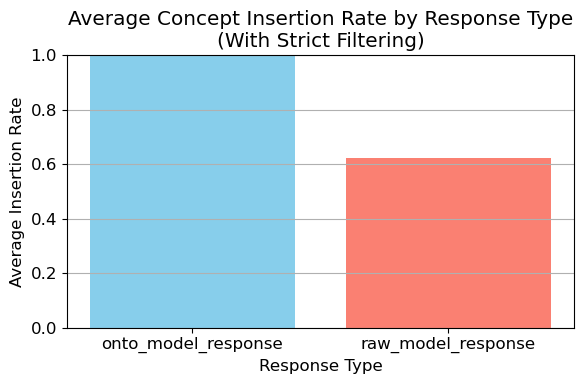

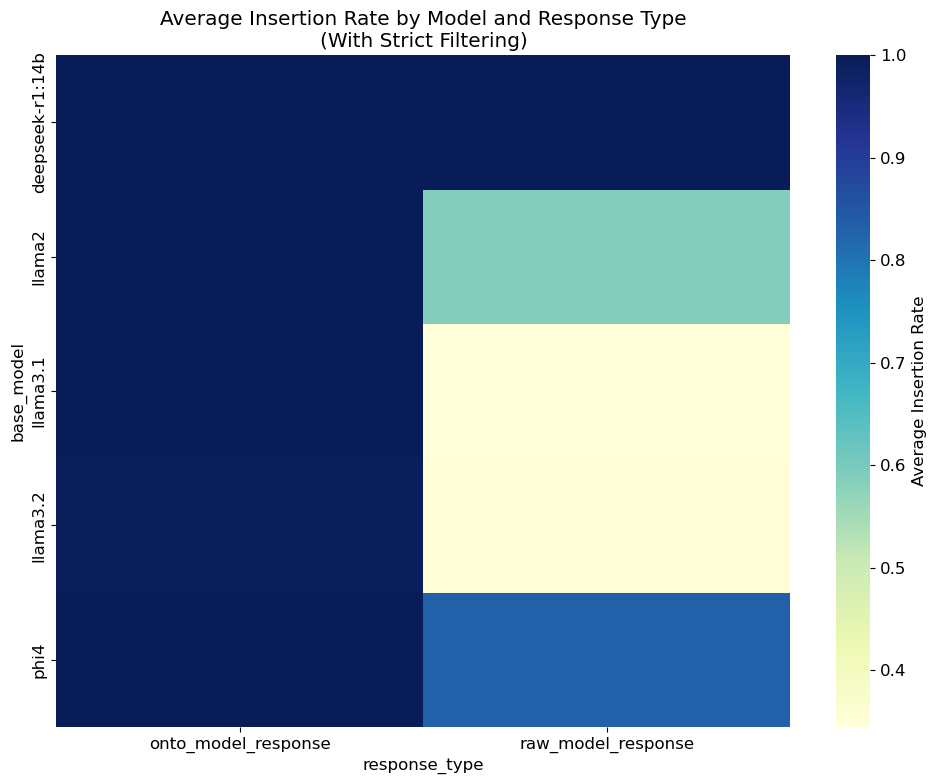

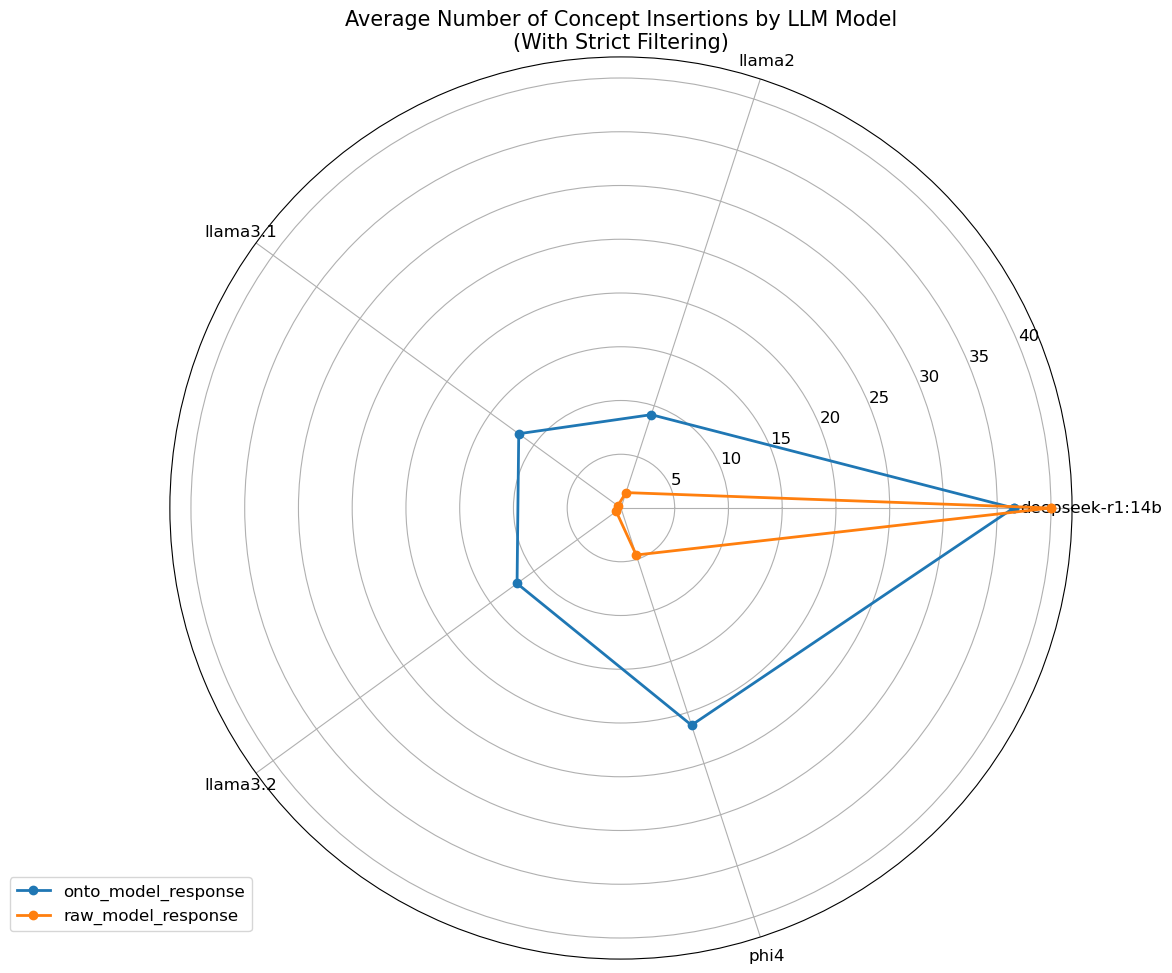

In [11]:
import rdflib
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict
import nltk
from nltk.corpus import stopwords
import string

# ------------------------
# CONFIGURATION (EDIT THIS)
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"

# ------------------------
# Enhanced Stopwords
# ------------------------
def get_enhanced_stopwords():
    """
    Get an enhanced set of stopwords including:
    - Standard NLTK English stopwords
    - Common prepositions, articles, and conjunctions
    - Common verbs and auxiliary words
    - Chemical terminology that isn't domain-specific (e.g., 'formula', 'substance')
    """
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    
    # Start with standard stopwords
    standard_stopwords = set(stopwords.words('english'))
    
    # Add common non-domain-specific words often found in scientific explanations
    additional_stopwords = {
        # Common scientific/explanation words
        'answer', 'correct', 'incorrectly', 'correctly', 'question', 'explanation',
        'solution', 'problem', 'result', 'example', 'figure', 'diagram', 'table',
        'using', 'shows', 'indicates', 'determine', 'calculate', 'solve',
        'means', 'therefore', 'thus', 'hence', 'consequently', 'accordingly',
        'first', 'second', 'third', 'fourth', 'fifth', 'final', 'finally',
        
        # Common chemical terminology that isn't domain-specific
        'formula', 'substance', 'compound', 'element', 'reaction', 'chemical',
        'properties', 'value', 'values', 'concentration', 'process', 'form',
        'forms', 'formed', 'forming', 'type', 'types', 'structure',
        
        # Additional prepositions, conjunctions, articles
        'regarding', 'concerning', 'according', 'whereas', 'whereby',
        'onto', 'into', 'upon', 'besides', 'amongst', 'amid', 'whether',
        
        # Common modal verbs and auxiliaries
        'would', 'could', 'should', 'might', 'may', 'can', 'will', 'shall',
        'must', 'ought', 'need', 'dare', 'used',
        
        # Common adverbs
        'very', 'quite', 'rather', 'somewhat', 'relatively', 'absolutely',
        'extremely', 'fairly', 'slightly', 'highly', 'particularly',
        
        # Domain-generic scientific terms
        'analysis', 'data', 'information', 'theory', 'experiment', 'observation',
        'study', 'research', 'model', 'method', 'procedure', 'technique',
        'equipment', 'instrument', 'apparatus', 'device', 'measurement',
        
        # Other common words in explanations
        'based', 'following', 'given', 'shown', 'related', 'associated',
        'similar', 'different', 'various', 'several', 'multiple', 'specific',
        'certain', 'particular', 'general', 'overall', 'main', 'key', 'primary',
        'secondary', 'important', 'significant', 'essential', 'crucial', 'critical',
        'appropriate', 'suitable', 'adequate', 'sufficient', 'necessary', 'required'
    }
    
    # Common phrases to filter (will be converted to lowercase for comparison)
    common_phrases = {
        'in order to', 'due to the', 'as a result', 'on the other hand',
        'with respect to', 'in terms of', 'in addition to', 'in contrast to',
        'in the case of', 'according to the', 'based on the', 'for example',
        'for instance', 'in this case', 'such as', 'in general',
        'as well as', 'refers to', 'defined as', 'classified as',
        'considered to be', 'known as', 'described as'
    }
    
    # Combine all stopwords
    combined_stopwords = standard_stopwords.union(additional_stopwords)
    
    return combined_stopwords, common_phrases

# ------------------------
# Load ChEBI Ontology
# ------------------------
def load_chebi_ontology(filepath):
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    
    # Create both superclass and subclass maps
    superclass_map = defaultdict(set)
    subclass_map = defaultdict(set)
    
    for s, p, o in g:
        if str(p).endswith("subClassOf"):
            s_label = extract_label(s)
            o_label = extract_label(o)
            if s_label and o_label:
                # s is a subclass of o
                superclass_map[s_label.lower()].add(o_label.lower())
                # o is a superclass of s
                subclass_map[o_label.lower()].add(s_label.lower())
    
    return superclass_map, subclass_map

def extract_label(uri):
    if isinstance(uri, rdflib.term.URIRef):
        return uri.split("/")[-1].replace("_", " ")
    return None

# ------------------------
# Parsing Logic
# ------------------------
def get_bidirectional_closure(concept, superclass_map, subclass_map):
    """
    Get both superclasses and subclasses of a concept recursively.
    """
    # First get superclass closure
    super_visited = set()
    super_to_visit = [concept]
    while super_to_visit:
        current = super_to_visit.pop()
        if current not in super_visited:
            super_visited.add(current)
            super_to_visit.extend(superclass_map.get(current, []))
    
    # Then get subclass closure
    sub_visited = set()
    sub_to_visit = [concept]
    while sub_to_visit:
        current = sub_to_visit.pop()
        if current not in sub_visited:
            sub_visited.add(current)
            sub_to_visit.extend(subclass_map.get(current, []))
    
    # Combine both closures
    return super_visited.union(sub_visited)

def extract_domain_concepts(ontology_info):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_info)
    return {m.lower().strip() for m in matches}

def remove_punctuation(text):
    """Remove punctuation from text"""
    return text.translate(str.maketrans('', '', string.punctuation))

def contains_phrase(text, phrase):
    """Check if text contains a phrase (case-insensitive)"""
    return phrase.lower() in text.lower()

def extract_used_concepts(text, enhanced_stopwords, common_phrases):
    # Clean the text for better concept extraction
    text_lower = text.lower()
    
    # Remove common phrases before concept extraction
    for phrase in common_phrases:
        text_lower = text_lower.replace(phrase, ' ')
    
    # Extract potential concepts (capitalized words followed by lowercase words)
    # Using the original text for extraction to maintain case information
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    
    # Filter out stopwords and apply stricter filtering
    filtered_concepts = set()
    for word in words:
        word_lower = word.lower().strip()
        word_no_punct = remove_punctuation(word_lower)
        
        # Skip very short words (likely abbreviations or not meaningful concepts)
        if len(word_no_punct) < 3:
            continue
            
        # Multi-word phrases - keep only if none of the words are stopwords
        if " " in word_lower:
            parts = word_lower.split()
            # Skip if all parts are stopwords or very short
            if all(part in enhanced_stopwords or len(part) < 3 for part in parts):
                continue
            # Skip if phrase contains numbers
            if any(char.isdigit() for char in word_lower):
                continue
            filtered_concepts.add(word_lower)
        # Single words - only keep if not a stopword and not too short
        elif word_no_punct not in enhanced_stopwords and len(word_no_punct) >= 3:
            filtered_concepts.add(word_lower)
    
    return filtered_concepts

def evaluate_response(model_name, response_type, response_text, ontology_info, superclass_map, subclass_map, enhanced_stopwords, common_phrases):
    domain_concepts = extract_domain_concepts(ontology_info)
    used_concepts = extract_used_concepts(response_text, enhanced_stopwords, common_phrases)

    # Get bidirectional closure for each domain concept (include both superclasses and subclasses)
    domain_closure = set()
    for concept in domain_concepts:
        domain_closure |= get_bidirectional_closure(concept, superclass_map, subclass_map)
    domain_closure |= domain_concepts  # Include original domain concepts

    # Concepts used in response but not in domain closure are insertions
    insertions = [c for c in used_concepts if c not in domain_closure]

    return {
        "model": model_name,
        "response_type": response_type,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1),
        "concept_insertions": insertions,
        "used_concepts": list(used_concepts),
        "domain": list(domain_concepts),
        "domain_closure_size": len(domain_closure)
    }

# ------------------------
# Run pipeline
# ------------------------
def run_pipeline(json_path, owl_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Loaded {len(data)} records from {json_path}")

    superclass_map, subclass_map = load_chebi_ontology(owl_path)
    print(f"ChEBI ontology loaded with {len(superclass_map)} superclass and {len(subclass_map)} subclass relations.")
    
    enhanced_stopwords, common_phrases = get_enhanced_stopwords()
    print(f"Loaded {len(enhanced_stopwords)} enhanced stopwords and {len(common_phrases)} common phrases for strict filtering.")

    results = []
    for model_name, record in data.items():
        ontology_info = record.get("OntologyInfo", "")
        for response_type in ["onto_model_response", "raw_model_response"]:
            if response_type in record:
                results.append(
                    evaluate_response(
                        model_name, 
                        response_type, 
                        record[response_type], 
                        ontology_info, 
                        superclass_map,
                        subclass_map,
                        enhanced_stopwords,
                        common_phrases
                    )
                )

    df = pd.DataFrame(results)

    # Save summary CSV
    df.to_csv("concept_insertion_results_strict.csv", index=False)

    # Plot summary
    summary = df.groupby("response_type")["insertion_rate"].mean().reset_index()
    plt.figure(figsize=(6, 4))
    plt.bar(summary["response_type"], summary["insertion_rate"], color=["skyblue", "salmon"])
    plt.title("Average Concept Insertion Rate by Response Type\n(With Strict Filtering)")
    plt.ylabel("Average Insertion Rate")
    plt.xlabel("Response Type")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig("concept_insertion_summary_strict.png")
    
    # Extract base model names
    df['base_model'] = df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x)
    
    # Create advanced visualizations
    # 1. Heatmap of insertion rates
    model_response_pivot = df.pivot_table(
        index='base_model', 
        columns='response_type',
        values='insertion_rate', 
        aggfunc='mean'
    )
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(model_response_pivot, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Average Insertion Rate'})
    plt.title('Average Insertion Rate by Model and Response Type\n(With Strict Filtering)')
    plt.tight_layout()
    plt.savefig("insertion_heatmap_strict.png")
    
    # 2. Radar chart for insertion counts
    llm_models = sorted(df['base_model'].unique())
    
    # Create radar chart
    fig = plt.figure(figsize=(12, 10))
    
    # Set up the radar chart parameters
    num_llms = len(llm_models)
    angles = np.linspace(0, 2*np.pi, num_llms, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Create plot
    ax = plt.subplot(111, polar=True)
    
    # Group by base model and response type to get average insertions
    model_stats = df.groupby(['base_model', 'response_type'])['num_insertions'].mean().unstack(fill_value=0)
    
    if 'onto_model_response' in model_stats.columns and 'raw_model_response' in model_stats.columns:
        onto_values = [model_stats.loc[model, 'onto_model_response'] if model in model_stats.index else 0 for model in llm_models]
        raw_values = [model_stats.loc[model, 'raw_model_response'] if model in model_stats.index else 0 for model in llm_models]
        
        # Close the loop for both lines
        onto_values += onto_values[:1]
        raw_values += raw_values[:1]
        
        # Plot lines
        ax.plot(angles, onto_values, 'o-', linewidth=2, label='onto_model_response')
        ax.plot(angles, raw_values, 'o-', linewidth=2, label='raw_model_response')
        
        # Add LLM model labels to the spokes
        ax.set_xticks(angles[:-1])  # Don't include the last angle which is just for closing the loop
        ax.set_xticklabels(llm_models)
        
        # Add legend
        plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
        
        plt.title('Average Number of Concept Insertions by LLM Model\n(With Strict Filtering)', size=15)
        plt.tight_layout()
        plt.savefig('insertions_radar_strict.png')
    
    print("\nSaved results to:")
    print("- concept_insertion_results_strict.csv")
    print("- concept_insertion_summary_strict.png")
    print("- insertion_heatmap_strict.png")
    print("- insertions_radar_strict.png")

# ------------------------
# Run it
# ------------------------
if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, CHEBI_OWL_PATH)

Loaded data for 1015 models from /home/matt/Proj/Hermeticav2/results/RawCoT/MMLU_highschool_Full_CoT_RawLLM.json
Loaded 308 enhanced stopwords and 23 common phrases for strict filtering.

Saved results to:
- no_ontology_concept_insertions.csv
- no_ontology_insertion_counts.png
- no_ontology_insertion_rates_heatmap.png
- no_ontology_insertions_radar.png


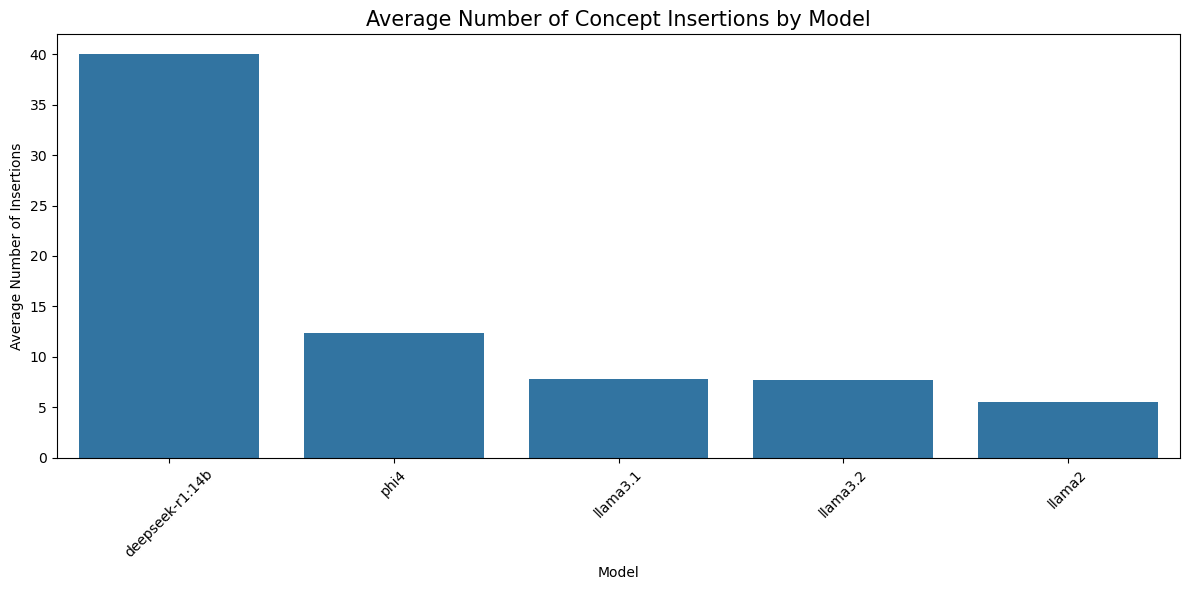

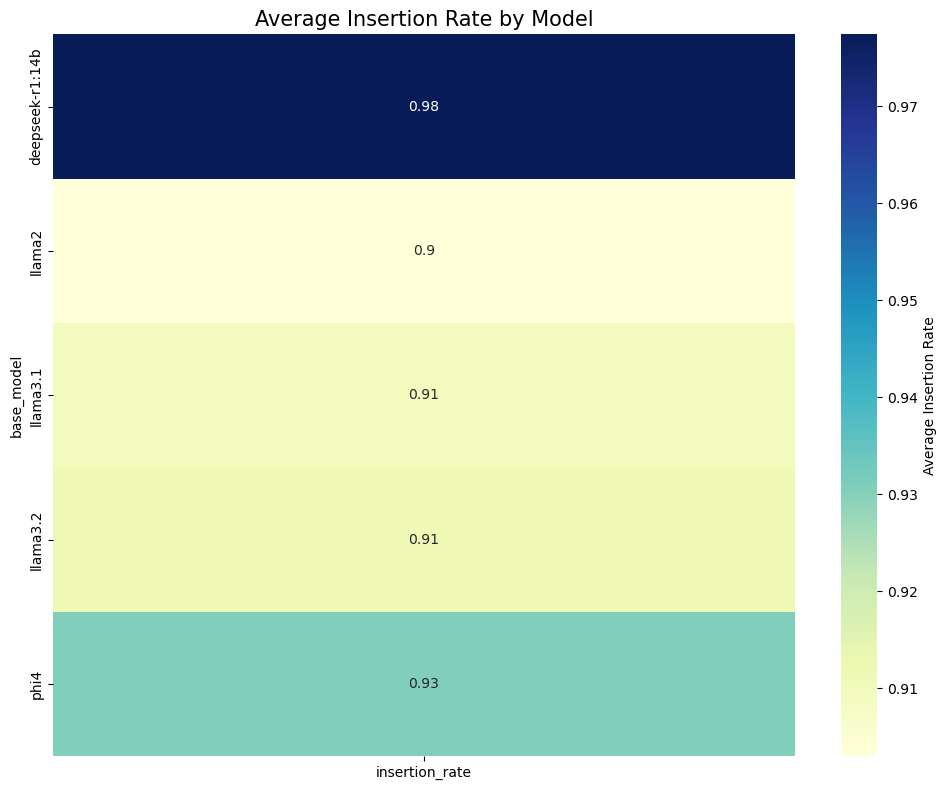

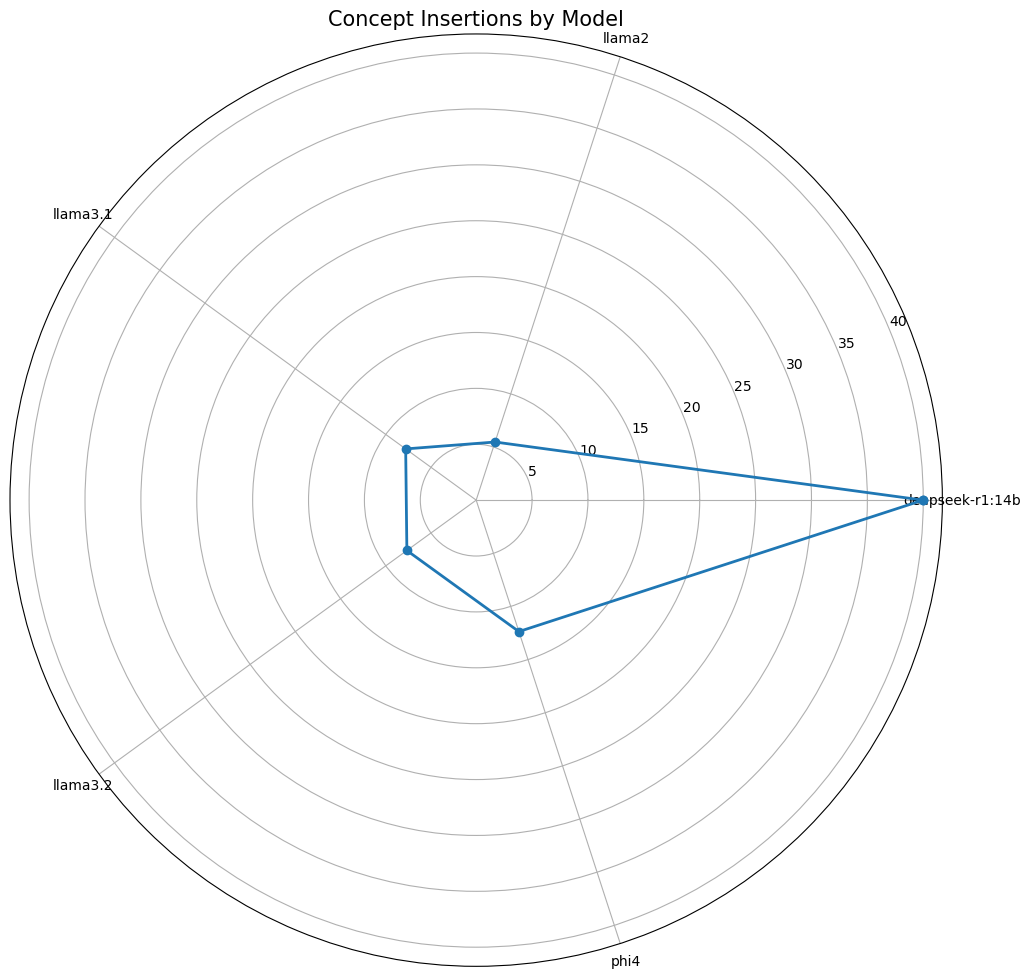

In [1]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict
import nltk
from nltk.corpus import stopwords
import string

# ------------------------
# CONFIGURATION (EDIT THIS)
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/RawCoT/MMLU_highschool_Full_CoT_RawLLM.json"
OUTPUT_PREFIX = "no_ontology"

# ------------------------
# Enhanced Stopwords
# ------------------------
def get_enhanced_stopwords():
    """
    Get an enhanced set of stopwords including:
    - Standard NLTK English stopwords
    - Common prepositions, articles, and conjunctions
    - Common verbs and auxiliary words
    - Chemical terminology that isn't domain-specific
    """
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    
    # Start with standard stopwords
    standard_stopwords = set(stopwords.words('english'))
    
    # Add common non-domain-specific words often found in scientific explanations
    additional_stopwords = {
        # Common scientific/explanation words
        'answer', 'correct', 'incorrectly', 'correctly', 'question', 'explanation',
        'solution', 'problem', 'result', 'example', 'figure', 'diagram', 'table',
        'using', 'shows', 'indicates', 'determine', 'calculate', 'solve',
        'means', 'therefore', 'thus', 'hence', 'consequently', 'accordingly',
        'first', 'second', 'third', 'fourth', 'fifth', 'final', 'finally',
        
        # Common chemical terminology that isn't domain-specific
        'formula', 'substance', 'compound', 'element', 'reaction', 'chemical',
        'properties', 'value', 'values', 'concentration', 'process', 'form',
        'forms', 'formed', 'forming', 'type', 'types', 'structure',
        
        # Additional prepositions, conjunctions, articles
        'regarding', 'concerning', 'according', 'whereas', 'whereby',
        'onto', 'into', 'upon', 'besides', 'amongst', 'amid', 'whether',
        
        # Common modal verbs and auxiliaries
        'would', 'could', 'should', 'might', 'may', 'can', 'will', 'shall',
        'must', 'ought', 'need', 'dare', 'used',
        
        # Common adverbs
        'very', 'quite', 'rather', 'somewhat', 'relatively', 'absolutely',
        'extremely', 'fairly', 'slightly', 'highly', 'particularly',
        
        # Domain-generic scientific terms
        'analysis', 'data', 'information', 'theory', 'experiment', 'observation',
        'study', 'research', 'model', 'method', 'procedure', 'technique',
        'equipment', 'instrument', 'apparatus', 'device', 'measurement',
        
        # Other common words in explanations
        'based', 'following', 'given', 'shown', 'related', 'associated',
        'similar', 'different', 'various', 'several', 'multiple', 'specific',
        'certain', 'particular', 'general', 'overall', 'main', 'key', 'primary',
        'secondary', 'important', 'significant', 'essential', 'crucial', 'critical',
        'appropriate', 'suitable', 'adequate', 'sufficient', 'necessary', 'required'
    }
    
    # Common phrases to filter (will be converted to lowercase for comparison)
    common_phrases = {
        'in order to', 'due to the', 'as a result', 'on the other hand',
        'with respect to', 'in terms of', 'in addition to', 'in contrast to',
        'in the case of', 'according to the', 'based on the', 'for example',
        'for instance', 'in this case', 'such as', 'in general',
        'as well as', 'refers to', 'defined as', 'classified as',
        'considered to be', 'known as', 'described as'
    }
    
    # Combine all stopwords
    combined_stopwords = standard_stopwords.union(additional_stopwords)
    
    return combined_stopwords, common_phrases

# ------------------------
# Parsing Logic
# ------------------------
def remove_punctuation(text):
    """Remove punctuation from text"""
    return text.translate(str.maketrans('', '', string.punctuation))

def contains_phrase(text, phrase):
    """Check if text contains a phrase (case-insensitive)"""
    return phrase.lower() in text.lower()

def extract_used_concepts(text, enhanced_stopwords, common_phrases):
    """Extract concepts from text using capitalization as a heuristic"""
    # Clean the text for better concept extraction
    text_lower = text.lower()
    
    # Remove common phrases before concept extraction
    for phrase in common_phrases:
        text_lower = text_lower.replace(phrase, ' ')
    
    # Extract potential concepts (capitalized words followed by lowercase words)
    # Using the original text for extraction to maintain case information
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    
    # Filter out stopwords and apply stricter filtering
    filtered_concepts = set()
    for word in words:
        word_lower = word.lower().strip()
        word_no_punct = remove_punctuation(word_lower)
        
        # Skip very short words (likely abbreviations or not meaningful concepts)
        if len(word_no_punct) < 3:
            continue
            
        # Multi-word phrases - keep only if none of the words are stopwords
        if " " in word_lower:
            parts = word_lower.split()
            # Skip if all parts are stopwords or very short
            if all(part in enhanced_stopwords or len(part) < 3 for part in parts):
                continue
            # Skip if phrase contains numbers
            if any(char.isdigit() for char in word_lower):
                continue
            filtered_concepts.add(word_lower)
        # Single words - only keep if not a stopword and not too short
        elif word_no_punct not in enhanced_stopwords and len(word_no_punct) >= 3:
            filtered_concepts.add(word_lower)
    
    return filtered_concepts

def extract_question_concepts(question, enhanced_stopwords, common_phrases):
    """Extract concepts from the question text and choices"""
    question_text = question.get("text", "")
    choices = question.get("choices", [])
    
    # Combine question text and all choices
    combined_text = question_text + " " + " ".join(choices)
    
    # Extract concepts from the combined text
    question_concepts = extract_used_concepts(combined_text, enhanced_stopwords, common_phrases)
    
    return question_concepts

def analyze_response(model_name, response_text, question_concepts, enhanced_stopwords, common_phrases):
    """Analyze a response for concept insertions relative to question concepts"""
    # Extract concepts used in the response
    used_concepts = extract_used_concepts(response_text, enhanced_stopwords, common_phrases)
    
    # Concepts used in response but not in question are insertions
    insertions = [c for c in used_concepts if c not in question_concepts]
    
    return {
        "model": model_name,
        "num_insertions": len(insertions),
        "insertion_rate": len(insertions) / max(len(used_concepts), 1),
        "concept_insertions": insertions,
        "used_concepts": list(used_concepts),
        "question_concepts": list(question_concepts)
    }

# ------------------------
# Run pipeline
# ------------------------
def run_pipeline(json_path, output_prefix):
    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Loaded data for {len(data)} models from {json_path}")
    
    enhanced_stopwords, common_phrases = get_enhanced_stopwords()
    print(f"Loaded {len(enhanced_stopwords)} enhanced stopwords and {len(common_phrases)} common phrases for strict filtering.")

    results = []
    for model_name, model_data in data.items():
        question = model_data.get("question", {})
        response_text = model_data.get("response", "")
        
        # Extract concepts from the question and choices
        question_concepts = extract_question_concepts(question, enhanced_stopwords, common_phrases)
        
        # Analyze the response for concept insertions
        result = analyze_response(
            model_name, 
            response_text, 
            question_concepts, 
            enhanced_stopwords, 
            common_phrases
        )
        
        results.append(result)

    df = pd.DataFrame(results)

    # Save summary CSV
    output_csv = f"{output_prefix}_concept_insertions.csv"
    df.to_csv(output_csv, index=False)

    # Extract base model names
    df['base_model'] = df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x)
    
    # Create visualizations
    # 1. Bar chart of insertion counts by model
    plt.figure(figsize=(12, 6))
    
    # Group by base model to get average insertions
    model_stats = df.groupby('base_model')['num_insertions'].mean().reset_index()
    model_stats = model_stats.sort_values('num_insertions', ascending=False)
    
    # Plot the bar chart
    sns.barplot(x='base_model', y='num_insertions', data=model_stats)
    plt.title('Average Number of Concept Insertions by Model', size=15)
    plt.xlabel('Model')
    plt.ylabel('Average Number of Insertions')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_insertion_counts.png")
    
    # 2. Heatmap showing insertion rates
    # Group by base model to get average insertion rates
    rate_stats = df.groupby('base_model')['insertion_rate'].mean().reset_index()
    # Convert to a matrix format for heatmap
    rate_matrix = rate_stats.pivot_table(index='base_model', values='insertion_rate')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(rate_matrix, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Average Insertion Rate'})
    plt.title('Average Insertion Rate by Model', size=15)
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_insertion_rates_heatmap.png")
    
    # 3. Radar chart for insertion counts if multiple models exist
    if len(df['base_model'].unique()) > 1:
        # Create radar chart
        fig = plt.figure(figsize=(12, 10))
        
        # Set up the radar chart parameters
        llm_models = sorted(df['base_model'].unique())
        num_llms = len(llm_models)
        angles = np.linspace(0, 2*np.pi, num_llms, endpoint=False).tolist()
        angles += angles[:1]  # Close the loop
        
        # Create plot
        ax = plt.subplot(111, polar=True)
        
        # Get insertion counts for radar chart
        insertion_values = [model_stats[model_stats['base_model'] == model]['num_insertions'].values[0] 
                           if model in model_stats['base_model'].values else 0 
                           for model in llm_models]
        
        # Close the loop
        insertion_values += insertion_values[:1]
        
        # Plot the line
        ax.plot(angles, insertion_values, 'o-', linewidth=2)
        
        # Add LLM model labels to the spokes
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(llm_models)
        
        plt.title('Concept Insertions by Model', size=15)
        plt.tight_layout()
        plt.savefig(f"{output_prefix}_insertions_radar.png")
    
    print("\nSaved results to:")
    print(f"- {output_prefix}_concept_insertions.csv")
    print(f"- {output_prefix}_insertion_counts.png")
    print(f"- {output_prefix}_insertion_rates_heatmap.png")
    if len(df['base_model'].unique()) > 1:
        print(f"- {output_prefix}_insertions_radar.png")
    
    return df

# ------------------------
# Run it
# ------------------------
if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, OUTPUT_PREFIX)

Loaded data for 1015 records
Extracted 423096 domain terms from ontology
Saved visualizations with prefix: domain_relevance
Analysis complete. Results saved to domain_relevance_analysis.csv


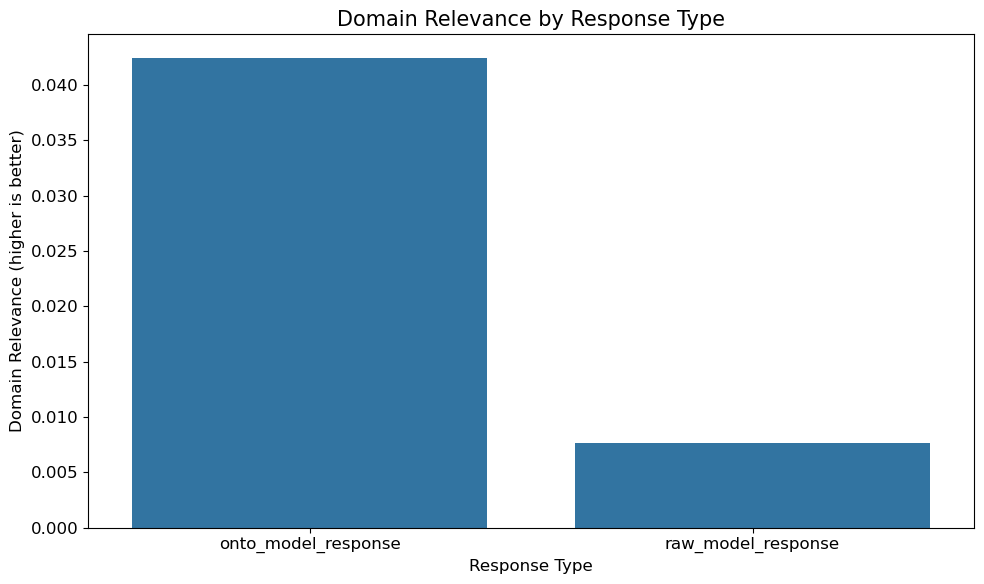

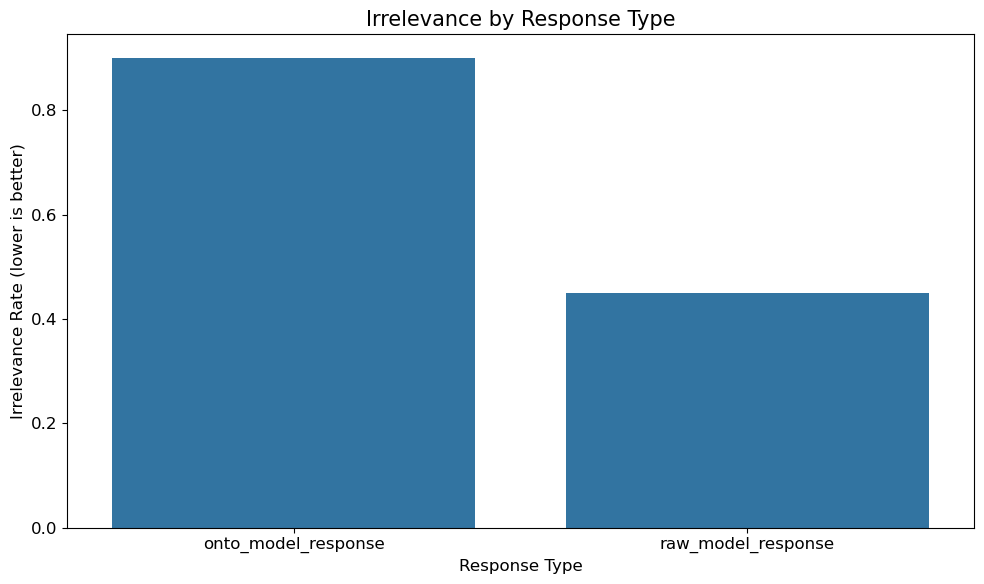

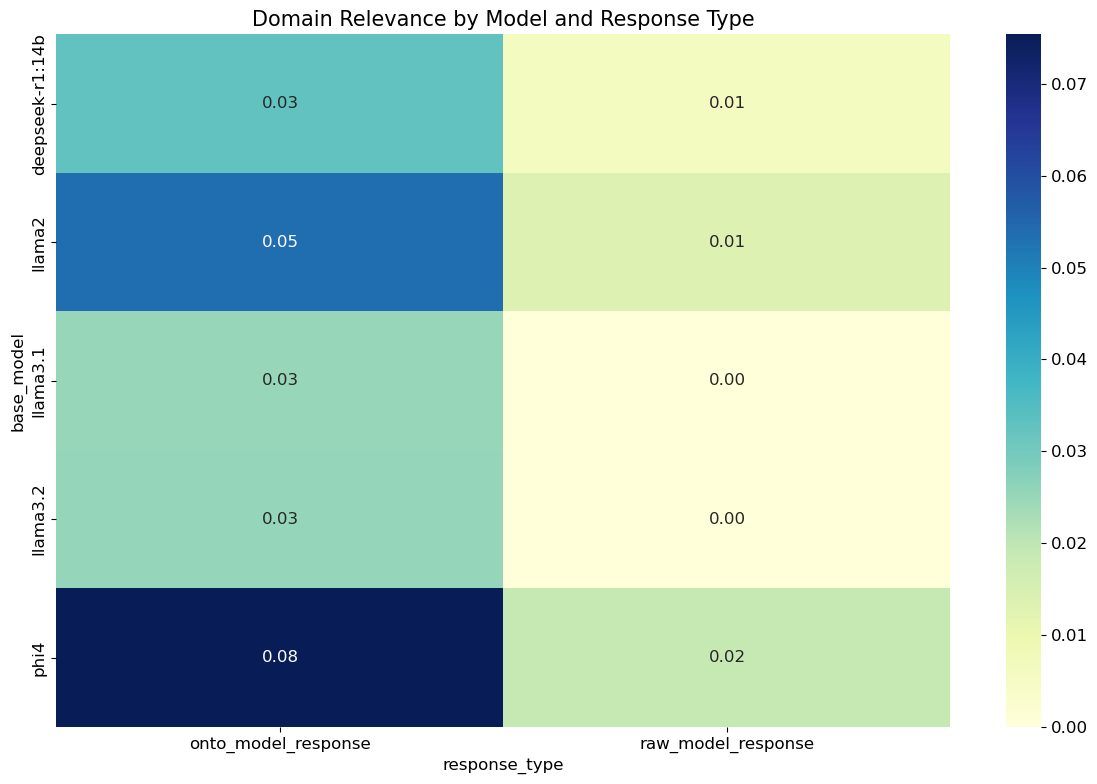

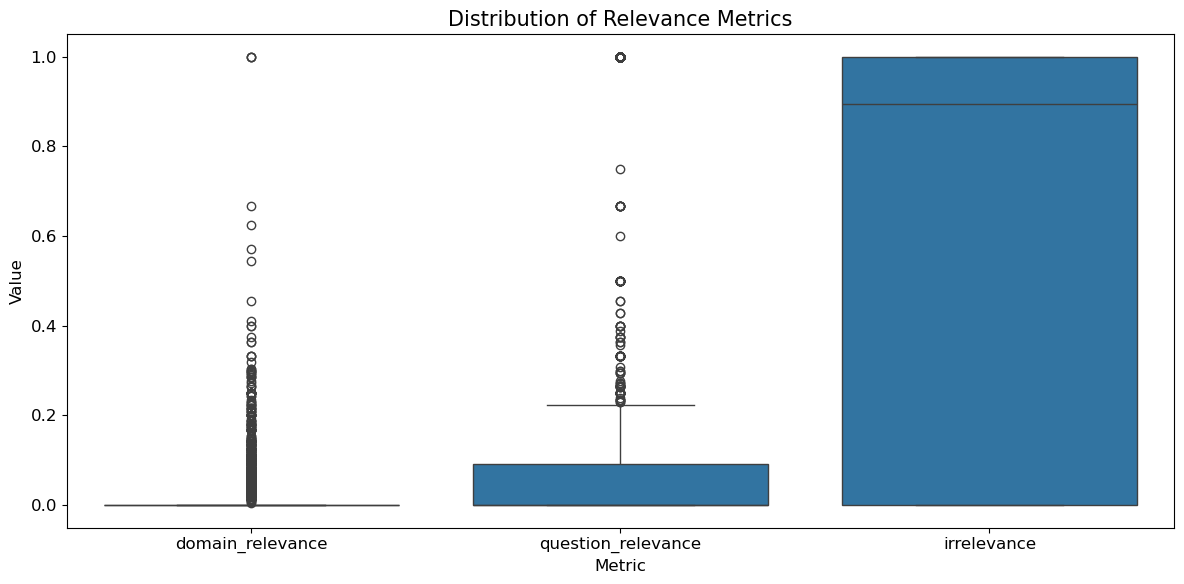

In [14]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict
import nltk
from nltk.corpus import stopwords
import string
import rdflib

# ------------------------
# CONFIGURATION
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"
OUTPUT_PREFIX = "domain_relevance"

# ------------------------
# Helper Functions
# ------------------------
def get_enhanced_stopwords():
    """Get enhanced stopwords for more accurate concept extraction"""
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    
    standard_stopwords = set(stopwords.words('english'))
    
    # Add specialized stopwords for scientific/chemical domains
    additional_stopwords = {
        # Common scientific explanation words
        'answer', 'correct', 'incorrectly', 'question', 'explanation', 'solution', 
        'therefore', 'thus', 'hence', 'consequently',
        
        # Common chemical terminology that isn't domain-specific
        'formula', 'substance', 'compound', 'element', 'chemical', 'properties',
        
        # Other common words
        'based', 'following', 'given', 'shown', 'related', 'various'
    }
    
    # Common phrases to filter out
    common_phrases = {
        'in order to', 'due to the', 'as a result', 'for example',
        'for instance', 'in this case', 'such as', 'as well as'
    }
    
    return standard_stopwords.union(additional_stopwords), common_phrases

def load_chebi_ontology(filepath):
    """Load ChEBI ontology and extract domain terms"""
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    
    # Extract all terms from the ontology
    domain_terms = set()
    
    for s, p, o in g:
        # Get entity labels
        if str(p).endswith("label"):
            if isinstance(o, rdflib.term.Literal):
                domain_terms.add(str(o).lower())
        
        # Get entity IDs (often contain descriptive names)
        if isinstance(s, rdflib.term.URIRef):
            term = s.split("/")[-1].replace("_", " ").lower()
            if len(term) > 2 and not term.isdigit():  # Skip numerical IDs
                domain_terms.add(term)
    
    print(f"Extracted {len(domain_terms)} domain terms from ontology")
    return domain_terms

def extract_concepts(text, stopwords, phrases):
    """Extract concepts from text using capitalization and chemical pattern heuristics"""
    # Clean the text and remove common phrases
    text_lower = text.lower()
    for phrase in phrases:
        text_lower = text_lower.replace(phrase, ' ')
    
    # Extract capitalized words and phrases
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    
    # Also extract chemical formulas
    chemical_terms = re.findall(r"\b[A-Z][a-z]?\d*(?:\([^)]+\))?\b", text)
    
    # Filter and process the concepts
    filtered_concepts = set()
    for word in words + chemical_terms:
        word_lower = word.lower().strip()
        word_clean = word_lower.translate(str.maketrans('', '', string.punctuation))
        
        # Skip short words and stopwords
        if len(word_clean) < 3:
            continue
            
        if " " in word_lower:  # Multi-word phrases
            parts = word_lower.split()
            if all(part in stopwords or len(part) < 3 for part in parts):
                continue
            filtered_concepts.add(word_lower)
        elif word_clean not in stopwords:  # Single words
            filtered_concepts.add(word_lower)
    
    return filtered_concepts

def classify_concepts(concepts, domain_terms, question_concepts):
    """Classify concepts as domain-relevant, question-relevant, or irrelevant"""
    classification = {
        "domain_relevant": [],
        "question_relevant": [],
        "irrelevant": []
    }
    
    for concept in concepts:
        if concept in domain_terms:
            classification["domain_relevant"].append(concept)
        elif concept in question_concepts:
            classification["question_relevant"].append(concept)
        else:
            classification["irrelevant"].append(concept)
    
    return classification

def calculate_metrics(classification, total_concepts):
    """Calculate relevance metrics from classification"""
    if total_concepts == 0:
        total_concepts = 1  # Avoid division by zero
        
    return {
        "domain_relevant_count": len(classification["domain_relevant"]),
        "question_relevant_count": len(classification["question_relevant"]),
        "irrelevant_count": len(classification["irrelevant"]),
        "domain_relevance": len(classification["domain_relevant"]) / total_concepts,
        "question_relevance": len(classification["question_relevant"]) / total_concepts,
        "irrelevance": len(classification["irrelevant"]) / total_concepts,
        "total_relevance": (len(classification["domain_relevant"]) + 
                            len(classification["question_relevant"])) / total_concepts
    }

def analyze_response(response_text, question_concepts, domain_terms, stopwords, phrases):
    """Analyze a response for concept relevance"""
    # Extract and classify concepts
    used_concepts = extract_concepts(response_text, stopwords, phrases)
    classification = classify_concepts(used_concepts, domain_terms, question_concepts)
    
    # Calculate metrics
    metrics = calculate_metrics(classification, len(used_concepts))
    
    # Add classification and concepts to results
    metrics.update({
        "domain_relevant": classification["domain_relevant"],
        "question_relevant": classification["question_relevant"],
        "irrelevant": classification["irrelevant"],
        "used_concepts": list(used_concepts)
    })
    
    return metrics

def create_visualizations(df, output_prefix):
    """Create visualizations from analysis results"""
    # Add base model column
    df['base_model'] = df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x)
    
    # 1. Compare response types if they exist
    if 'response_type' in df.columns and len(df['response_type'].unique()) > 1:
        # Calculate averages by response type
        type_summary = df.groupby('response_type').agg({
            'domain_relevance': 'mean',
            'question_relevance': 'mean',
            'irrelevance': 'mean'
        }).reset_index()
        
        # Bar chart comparing domain relevance
        plt.figure(figsize=(10, 6))
        sns.barplot(x='response_type', y='domain_relevance', data=type_summary)
        plt.title('Domain Relevance by Response Type', size=15)
        plt.xlabel('Response Type')
        plt.ylabel('Domain Relevance (higher is better)')
        plt.tight_layout()
        plt.savefig(f"{output_prefix}_domain_relevance.png")
        
        # Bar chart comparing irrelevance
        plt.figure(figsize=(10, 6))
        sns.barplot(x='response_type', y='irrelevance', data=type_summary)
        plt.title('Irrelevance by Response Type', size=15)
        plt.xlabel('Response Type')
        plt.ylabel('Irrelevance Rate (lower is better)')
        plt.tight_layout()
        plt.savefig(f"{output_prefix}_irrelevance.png")
        
        # 2. Compare model performance by response type
        model_type_summary = df.groupby(['base_model', 'response_type']).agg({
            'domain_relevance': 'mean',
            'irrelevance': 'mean'
        }).reset_index()
        
        # Heatmap of domain relevance
        if len(model_type_summary) > 1:
            domain_pivot = model_type_summary.pivot(
                index='base_model', 
                columns='response_type', 
                values='domain_relevance'
            )
            
            plt.figure(figsize=(12, 8))
            sns.heatmap(domain_pivot, annot=True, cmap="YlGnBu", fmt=".2f")
            plt.title('Domain Relevance by Model and Response Type', size=15)
            plt.tight_layout()
            plt.savefig(f"{output_prefix}_model_type_heatmap.png")
    
    # 3. Always create a summary of overall metrics
    plt.figure(figsize=(12, 6))
    metrics_df = pd.melt(
        df, 
        id_vars=['model'], 
        value_vars=['domain_relevance', 'question_relevance', 'irrelevance'],
        var_name='Metric', 
        value_name='Value'
    )
    
    sns.boxplot(x='Metric', y='Value', data=metrics_df)
    plt.title('Distribution of Relevance Metrics', size=15)
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_metrics_boxplot.png")
    
    print(f"Saved visualizations with prefix: {output_prefix}")

# ------------------------
# Main Pipeline
# ------------------------
def run_pipeline(json_path, owl_path, output_prefix):
    """Main analysis pipeline"""
    # 1. Load data and initialize resources
    with open(json_path, "r") as f:
        data = json.load(f)
    
    print(f"Loaded data for {len(data)} records")
    
    domain_terms = load_chebi_ontology(owl_path)
    stopwords, phrases = get_enhanced_stopwords()
    
    # 2. Process all responses
    results = []
    
    for model_name, model_data in data.items():
        # Handle different data formats
        if "onto_model_response" in model_data and "raw_model_response" in model_data:
            # Extract question concepts once
            question = model_data.get("question", {})
            if not question and "Question" in model_data:
                question = model_data["Question"]
                
            question_concepts = extract_concepts(
                question.get("text", "") + " " + " ".join(question.get("choices", [])),
                stopwords, phrases
            )
            
            # Process both response types
            for resp_type in ["onto_model_response", "raw_model_response"]:
                if resp_type in model_data:
                    # Analyze this response type
                    metrics = analyze_response(
                        model_data[resp_type],
                        question_concepts,
                        domain_terms,
                        stopwords,
                        phrases
                    )
                    
                    # Add metadata
                    metrics["model"] = model_name
                    metrics["response_type"] = resp_type
                    
                    results.append(metrics)
        
        # Handle standard format
        elif "question" in model_data and "response" in model_data:
            question = model_data["question"]
            question_concepts = extract_concepts(
                question.get("text", "") + " " + " ".join(question.get("choices", [])),
                stopwords, phrases
            )
            
            metrics = analyze_response(
                model_data["response"],
                question_concepts,
                domain_terms,
                stopwords,
                phrases
            )
            
            metrics["model"] = model_name
            metrics["response_type"] = "standard"
            
            results.append(metrics)
    
    # 3. Create dataframe and save results
    df = pd.DataFrame(results)
    df.to_csv(f"{output_prefix}_analysis.csv", index=False)
    
    # 4. Create visualizations
    create_visualizations(df, output_prefix)
    
    print(f"Analysis complete. Results saved to {output_prefix}_analysis.csv")
    return df

if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, CHEBI_OWL_PATH, OUTPUT_PREFIX)

Loaded data for 1015 records


Extracted 423096 domain terms from ontology


/tmp/ipykernel_2225379/966814817.py:201: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='response_type', y='norm_domain_relevance', data=type_summary, palette='plasma')
/tmp/ipykernel_2225379/966814817.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='response_type', y='norm_irrelevance', data=type_summary, palette='plasma')
/tmp/ipykernel_2225379/966814817.py:268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_pivot.index, y='difference', data=domain_pivot.reset_index(), palette='plasma')
/tmp/ipykernel_2225379/966814817.py:

Saved visualizations with prefix: domain_relevance
Analysis complete. Results saved to domain_relevance_analysis.csv


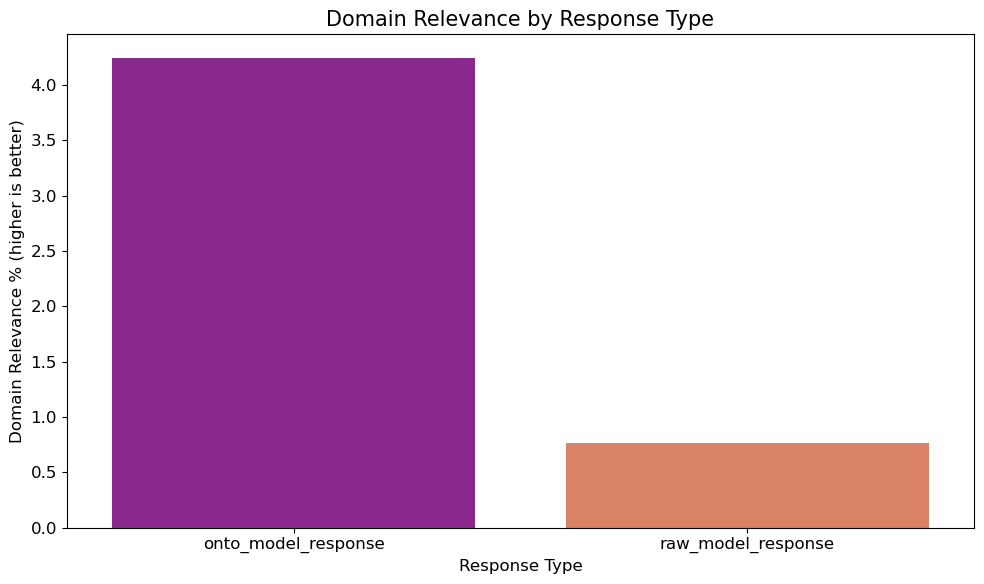

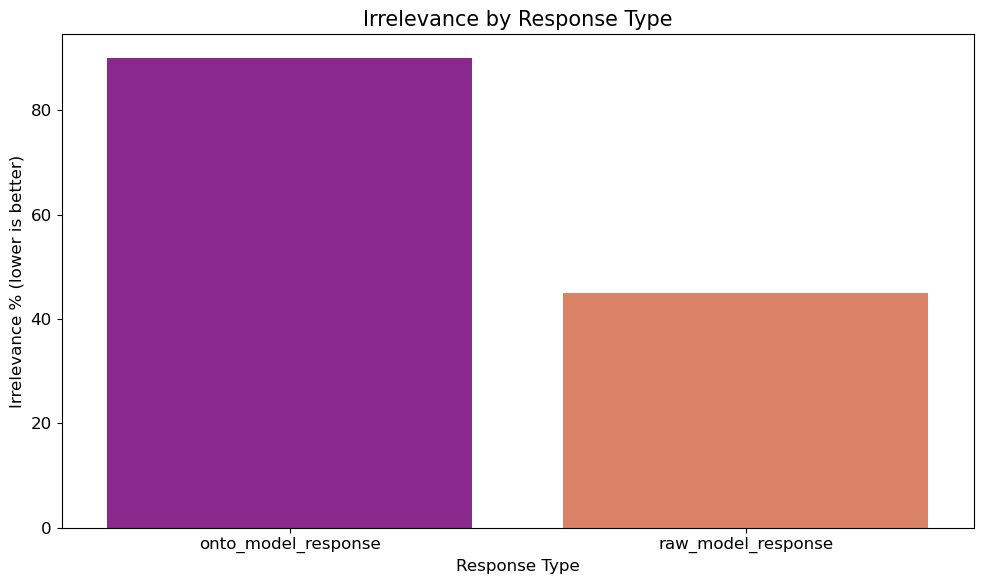

<Figure size 1200x800 with 0 Axes>

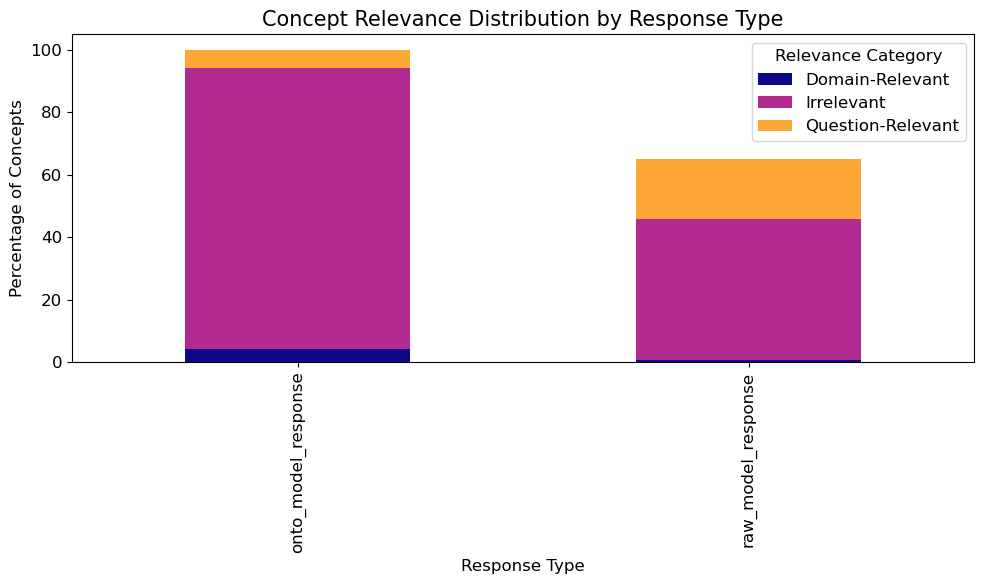

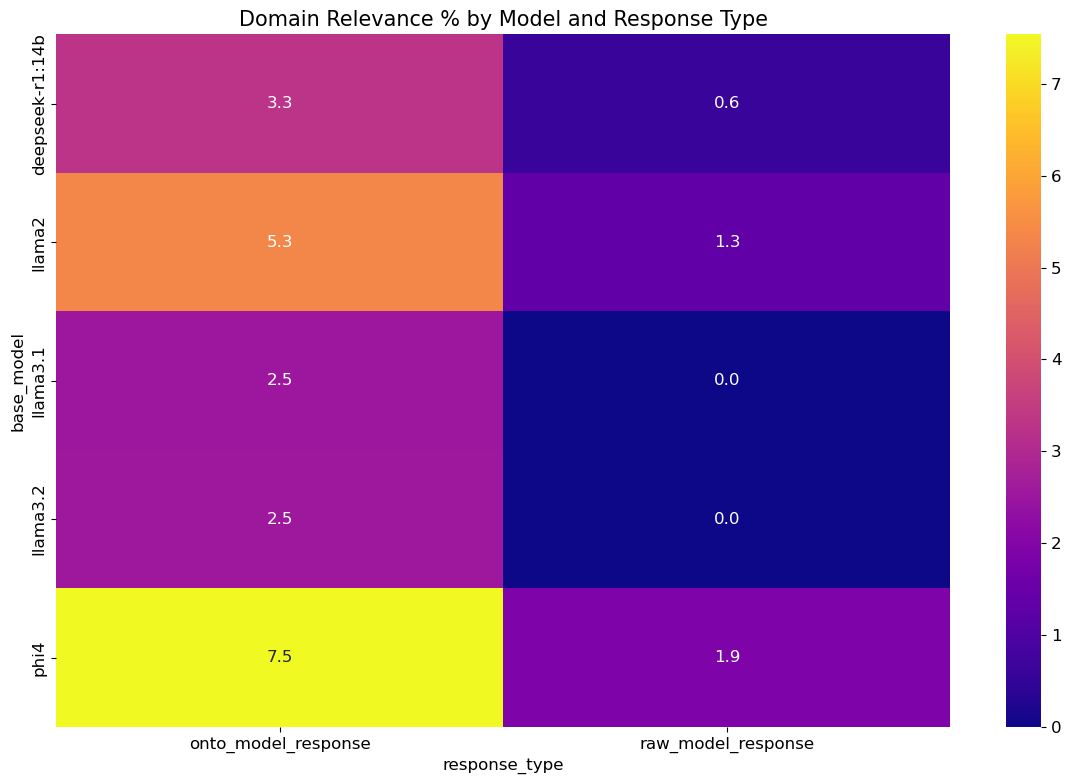

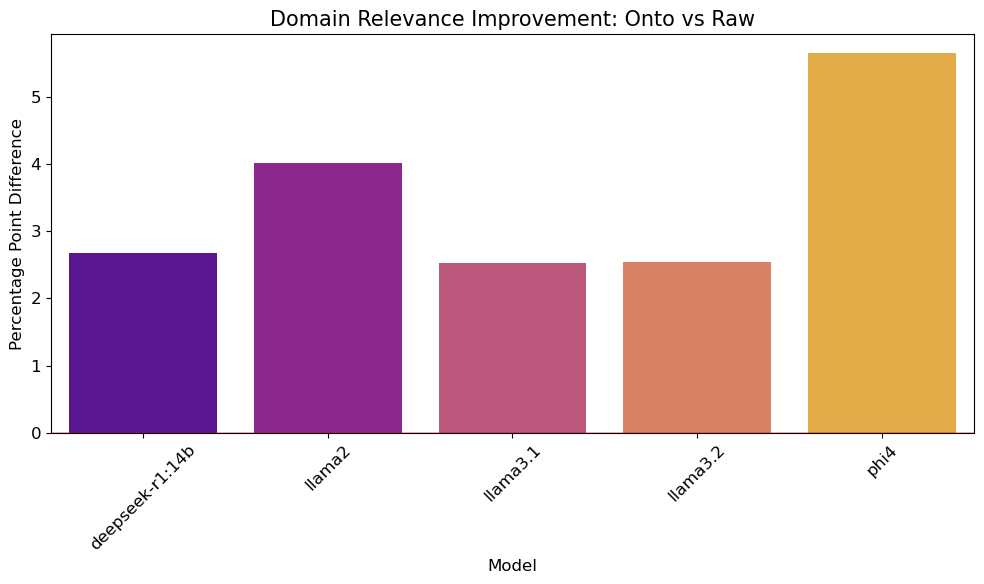

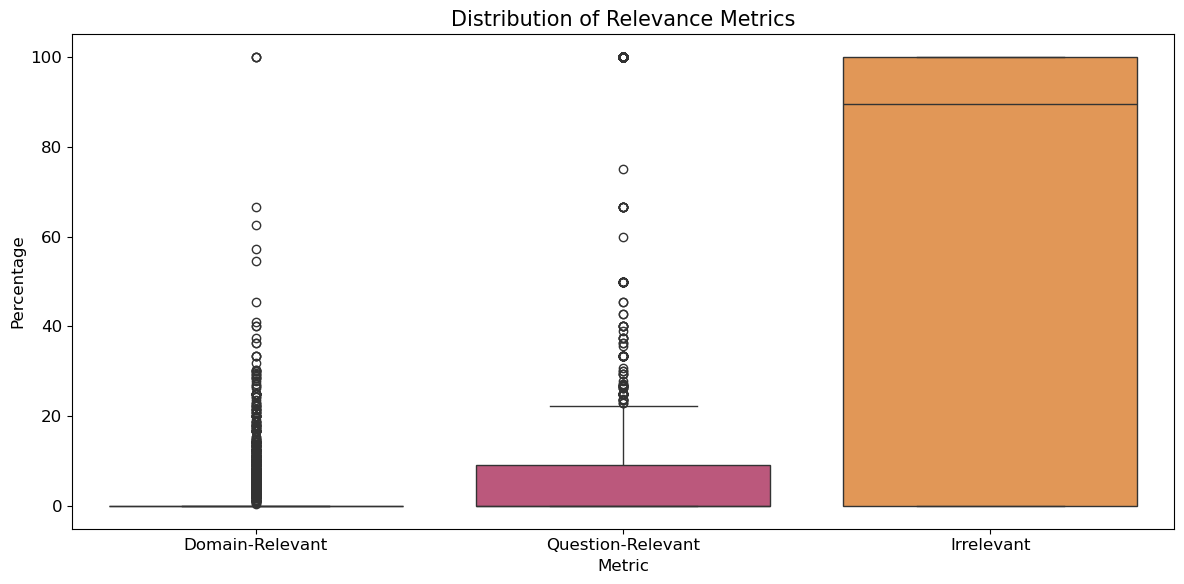

In [16]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict
import nltk
from nltk.corpus import stopwords
import string
import rdflib

# ------------------------
# CONFIGURATION
# ------------------------
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"
OUTPUT_PREFIX = "domain_relevance"
# ------------------------
# Helper Functions
# ------------------------
def get_enhanced_stopwords():
    """Get enhanced stopwords for more accurate concept extraction"""
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    
    standard_stopwords = set(stopwords.words('english'))
    
    # Add specialized stopwords for scientific/chemical domains
    additional_stopwords = {
        # Common scientific explanation words
        'answer', 'correct', 'incorrectly', 'question', 'explanation', 'solution', 
        'therefore', 'thus', 'hence', 'consequently',
        
        # Common chemical terminology that isn't domain-specific
        'formula', 'substance', 'compound', 'element', 'chemical', 'properties',
        
        # Other common words
        'based', 'following', 'given', 'shown', 'related', 'various'
    }
    
    # Common phrases to filter out
    common_phrases = {
        'in order to', 'due to the', 'as a result', 'for example',
        'for instance', 'in this case', 'such as', 'as well as'
    }
    
    return standard_stopwords.union(additional_stopwords), common_phrases

def load_chebi_ontology(filepath):
    """Load ChEBI ontology and extract domain terms"""
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    
    # Extract all terms from the ontology
    domain_terms = set()
    
    for s, p, o in g:
        # Get entity labels
        if str(p).endswith("label"):
            if isinstance(o, rdflib.term.Literal):
                domain_terms.add(str(o).lower())
        
        # Get entity IDs (often contain descriptive names)
        if isinstance(s, rdflib.term.URIRef):
            term = s.split("/")[-1].replace("_", " ").lower()
            if len(term) > 2 and not term.isdigit():  # Skip numerical IDs
                domain_terms.add(term)
    
    print(f"Extracted {len(domain_terms)} domain terms from ontology")
    return domain_terms

def extract_concepts(text, stopwords, phrases):
    """Extract concepts from text using capitalization and chemical pattern heuristics"""
    # Clean the text and remove common phrases
    text_lower = text.lower()
    for phrase in phrases:
        text_lower = text_lower.replace(phrase, ' ')
    
    # Extract capitalized words and phrases
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    
    # Also extract chemical formulas
    chemical_terms = re.findall(r"\b[A-Z][a-z]?\d*(?:\([^)]+\))?\b", text)
    
    # Filter and process the concepts
    filtered_concepts = set()
    for word in words + chemical_terms:
        word_lower = word.lower().strip()
        word_clean = word_lower.translate(str.maketrans('', '', string.punctuation))
        
        # Skip short words and stopwords
        if len(word_clean) < 3:
            continue
            
        if " " in word_lower:  # Multi-word phrases
            parts = word_lower.split()
            if all(part in stopwords or len(part) < 3 for part in parts):
                continue
            filtered_concepts.add(word_lower)
        elif word_clean not in stopwords:  # Single words
            filtered_concepts.add(word_lower)
    
    return filtered_concepts

def classify_concepts(concepts, domain_terms, question_concepts):
    """Classify concepts as domain-relevant, question-relevant, or irrelevant"""
    classification = {
        "domain_relevant": [],
        "question_relevant": [],
        "irrelevant": []
    }
    
    for concept in concepts:
        if concept in domain_terms:
            classification["domain_relevant"].append(concept)
        elif concept in question_concepts:
            classification["question_relevant"].append(concept)
        else:
            classification["irrelevant"].append(concept)
    
    return classification

def calculate_metrics(classification, total_concepts):
    """Calculate relevance metrics from classification"""
    if total_concepts == 0:
        total_concepts = 1  # Avoid division by zero
    
    # Calculate raw metrics
    domain_count = len(classification["domain_relevant"])
    question_count = len(classification["question_relevant"])
    irrelevant_count = len(classification["irrelevant"])
    
    # Calculate raw ratios
    raw_domain_relevance = domain_count / total_concepts
    raw_question_relevance = question_count / total_concepts
    raw_irrelevance = irrelevant_count / total_concepts
    raw_total_relevance = (domain_count + question_count) / total_concepts
    
    # Normalized metrics - scale up to more intuitive values (0-100)
    normalized_domain_relevance = raw_domain_relevance * 100
    normalized_question_relevance = raw_question_relevance * 100
    normalized_irrelevance = raw_irrelevance * 100
    normalized_total_relevance = raw_total_relevance * 100
    
    return {
        "domain_relevant_count": domain_count,
        "question_relevant_count": question_count,
        "irrelevant_count": irrelevant_count,
        "domain_relevance": raw_domain_relevance,
        "question_relevance": raw_question_relevance,
        "irrelevance": raw_irrelevance,
        "total_relevance": raw_total_relevance,
        "norm_domain_relevance": normalized_domain_relevance,
        "norm_question_relevance": normalized_question_relevance,
        "norm_irrelevance": normalized_irrelevance,
        "norm_total_relevance": normalized_total_relevance
    }

def analyze_response(response_text, question_concepts, domain_terms, stopwords, phrases):
    """Analyze a response for concept relevance"""
    # Extract and classify concepts
    used_concepts = extract_concepts(response_text, stopwords, phrases)
    classification = classify_concepts(used_concepts, domain_terms, question_concepts)
    
    # Calculate metrics
    metrics = calculate_metrics(classification, len(used_concepts))
    
    # Add classification and concepts to results
    metrics.update({
        "domain_relevant": classification["domain_relevant"],
        "question_relevant": classification["question_relevant"],
        "irrelevant": classification["irrelevant"],
        "used_concepts": list(used_concepts)
    })
    
    return metrics

def create_visualizations(df, output_prefix):
    """Create visualizations from analysis results"""
    # Set color palette to plasma
    plasma_colors = plt.cm.plasma(np.linspace(0, 0.8, 3))  # Get 3 colors from plasma
    sns.set_palette(plasma_colors)
    
    # Add base model column
    df['base_model'] = df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x)
    
    # 1. Compare response types if they exist
    if 'response_type' in df.columns and len(df['response_type'].unique()) > 1:
        # Calculate averages by response type
        type_summary = df.groupby('response_type').agg({
            'norm_domain_relevance': 'mean',
            'norm_question_relevance': 'mean', 
            'norm_irrelevance': 'mean'
        }).reset_index()
        
        # Bar chart comparing normalized domain relevance
        plt.figure(figsize=(10, 6))
        sns.barplot(x='response_type', y='norm_domain_relevance', data=type_summary, palette='plasma')
        plt.title('Domain Relevance by Response Type', size=15)
        plt.xlabel('Response Type')
        plt.ylabel('Domain Relevance % (higher is better)')
        plt.tight_layout()
        plt.savefig(f"{output_prefix}_domain_relevance.png")
        
        # Bar chart comparing normalized irrelevance
        plt.figure(figsize=(10, 6))
        sns.barplot(x='response_type', y='norm_irrelevance', data=type_summary, palette='plasma')
        plt.title('Irrelevance by Response Type', size=15)
        plt.xlabel('Response Type')
        plt.ylabel('Irrelevance % (lower is better)')
        plt.tight_layout()
        plt.savefig(f"{output_prefix}_irrelevance.png")
        
        # Stacked bar chart of all normalized categories
        plt.figure(figsize=(12, 8))
        
        # Create a DataFrame for the stacked bar
        stacked_data = []
        for _, row in type_summary.iterrows():
            response_type = row['response_type']
            stacked_data.extend([
                {'type': response_type, 'category': 'Domain-Relevant', 'value': row['norm_domain_relevance']},
                {'type': response_type, 'category': 'Question-Relevant', 'value': row['norm_question_relevance']},
                {'type': response_type, 'category': 'Irrelevant', 'value': row['norm_irrelevance']}
            ])
        
        stacked_df = pd.DataFrame(stacked_data)
        stacked_pivot = stacked_df.pivot(index='type', columns='category', values='value')
        
        # Plot stacked bar chart with plasma colors
        stacked_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), 
                           color=plasma_colors)
        plt.title('Concept Relevance Distribution by Response Type', size=15)
        plt.xlabel('Response Type')
        plt.ylabel('Percentage of Concepts')
        plt.legend(title='Relevance Category')
        plt.tight_layout()
        plt.savefig(f"{output_prefix}_stacked_relevance.png")
        
        # 2. Compare model performance by response type (using normalized values)
        model_type_summary = df.groupby(['base_model', 'response_type']).agg({
            'norm_domain_relevance': 'mean',
            'norm_irrelevance': 'mean'
        }).reset_index()
        
        # Heatmap of domain relevance
        if len(model_type_summary) > 1:
            domain_pivot = model_type_summary.pivot(
                index='base_model', 
                columns='response_type', 
                values='norm_domain_relevance'
            )
            
            plt.figure(figsize=(12, 8))
            sns.heatmap(domain_pivot, annot=True, cmap="plasma", fmt=".1f")
            plt.title('Domain Relevance % by Model and Response Type', size=15)
            plt.tight_layout()
            plt.savefig(f"{output_prefix}_model_type_heatmap.png")
            
            # Calculate and visualize the difference
            if 'onto_model_response' in domain_pivot.columns and 'raw_model_response' in domain_pivot.columns:
                domain_pivot['difference'] = domain_pivot['onto_model_response'] - domain_pivot['raw_model_response']
                
                plt.figure(figsize=(10, 6))
                sns.barplot(x=domain_pivot.index, y='difference', data=domain_pivot.reset_index(), palette='plasma')
                plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
                plt.title('Domain Relevance Improvement: Onto vs Raw', size=15)
                plt.xlabel('Model')
                plt.ylabel('Percentage Point Difference')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.savefig(f"{output_prefix}_relevance_improvement.png")
    
    # 3. Always create a summary of overall metrics
    plt.figure(figsize=(12, 6))
    metrics_df = pd.melt(
        df, 
        id_vars=['model'], 
        value_vars=['norm_domain_relevance', 'norm_question_relevance', 'norm_irrelevance'],
        var_name='Metric', 
        value_name='Value'
    )
    
    metrics_df['Metric'] = metrics_df['Metric'].map({
        'norm_domain_relevance': 'Domain-Relevant', 
        'norm_question_relevance': 'Question-Relevant', 
        'norm_irrelevance': 'Irrelevant'
    })
    
    sns.boxplot(x='Metric', y='Value', data=metrics_df, palette='plasma')
    plt.title('Distribution of Relevance Metrics', size=15)
    plt.ylabel('Percentage')
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_metrics_boxplot.png")
    
    print(f"Saved visualizations with prefix: {output_prefix}")

# ------------------------
# Main Pipeline
# ------------------------
def run_pipeline(json_path, owl_path, output_prefix):
    """Main analysis pipeline"""
    # 1. Load data and initialize resources
    with open(json_path, "r") as f:
        data = json.load(f)
    
    print(f"Loaded data for {len(data)} records")
    
    domain_terms = load_chebi_ontology(owl_path)
    stopwords, phrases = get_enhanced_stopwords()
    
    # 2. Process all responses
    results = []
    
    for model_name, model_data in data.items():
        # Handle different data formats
        if "onto_model_response" in model_data and "raw_model_response" in model_data:
            # Extract question concepts once
            question = model_data.get("question", {})
            if not question and "Question" in model_data:
                question = model_data["Question"]
                
            question_concepts = extract_concepts(
                question.get("text", "") + " " + " ".join(question.get("choices", [])),
                stopwords, phrases
            )
            
            # Process both response types
            for resp_type in ["onto_model_response", "raw_model_response"]:
                if resp_type in model_data:
                    # Analyze this response type
                    metrics = analyze_response(
                        model_data[resp_type],
                        question_concepts,
                        domain_terms,
                        stopwords,
                        phrases
                    )
                    
                    # Add metadata
                    metrics["model"] = model_name
                    metrics["response_type"] = resp_type
                    
                    results.append(metrics)
        
        # Handle standard format
        elif "question" in model_data and "response" in model_data:
            question = model_data["question"]
            question_concepts = extract_concepts(
                question.get("text", "") + " " + " ".join(question.get("choices", [])),
                stopwords, phrases
            )
            
            metrics = analyze_response(
                model_data["response"],
                question_concepts,
                domain_terms,
                stopwords,
                phrases
            )
            
            metrics["model"] = model_name
            metrics["response_type"] = "standard"
            
            results.append(metrics)
    
    # 3. Create dataframe and save results
    df = pd.DataFrame(results)
    df.to_csv(f"{output_prefix}_analysis.csv", index=False)
    
    # 4. Create visualizations
    create_visualizations(df, output_prefix)
    
    print(f"Analysis complete. Results saved to {output_prefix}_analysis.csv")
    return df

if __name__ == "__main__":
    run_pipeline(JSON_INPUT_PATH, CHEBI_OWL_PATH, OUTPUT_PREFIX)

# comparing rule concept insetion to Cot LLM

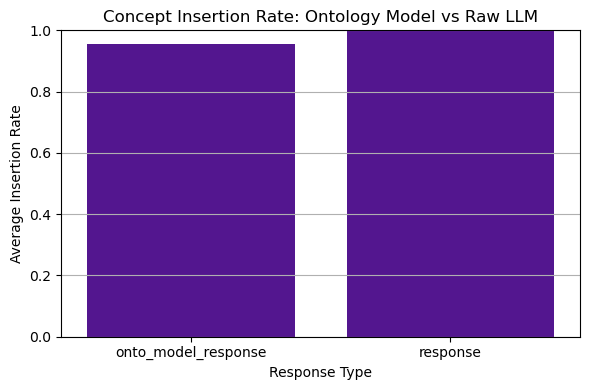

✅ Analysis complete.
Results saved to:
  - concept_insertion_cot_concept_insertion.csv
  - concept_insertion_cot_insertion_rate.png


In [3]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import rdflib
import seaborn as sns

# ------------------------
# CONFIGURATION
# ------------------------
ONTO_FILE = "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full1.json"
RAW_FILE = "/home/matt/Proj/Hermeticav2/results/RawCoT/MMLU_highschool_Full_CoT_RawLLM.json"
CHEBI_OWL_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"
OUTPUT_PREFIX = "concept_insertion_cot"

# ------------------------
# Ontology Loader
# ------------------------
def load_chebi_ontology(filepath):
    g = rdflib.Graph()
    g.parse(filepath, format="xml")
    subclass_map = defaultdict(set)
    for s, p, o in g:
        if str(p).endswith("subClassOf"):
            s_label = extract_label(s)
            o_label = extract_label(o)
            if s_label and o_label:
                subclass_map[s_label.lower()].add(o_label.lower())
    return subclass_map

def extract_label(uri):
    if isinstance(uri, rdflib.term.URIRef):
        return uri.split("/")[-1].replace("_", " ")
    return None

def get_transitive_closure(concept, subclass_map):
    visited = set()
    to_visit = [concept]
    while to_visit:
        current = to_visit.pop()
        if current not in visited:
            visited.add(current)
            to_visit.extend(subclass_map.get(current, []))
    return visited

# ------------------------
# Core Logic
# ------------------------
def extract_domain_concepts(ontology_info):
    matches = re.findall(r"Looking up (.*?) \(.*?\) in the ChEBI ontology", ontology_info)
    return {m.lower().strip() for m in matches}

def extract_used_concepts(text):
    words = re.findall(r"\b[A-Z][a-z]+(?:\s+[a-z]+)*\b", text)
    return {w.lower().strip() for w in words}

def evaluate_model_file(data, subclass_map, response_type_key):
    results = []
    for model_name, record in data.items():
        ontology_info = record.get("OntologyInfo", "")
        response_text = record.get(response_type_key, "")
        if not response_text:
            continue

        domain_concepts = extract_domain_concepts(ontology_info)
        used_concepts = extract_used_concepts(response_text)

        domain_closure = set()
        for concept in domain_concepts:
            domain_closure |= get_transitive_closure(concept, subclass_map)
        domain_closure |= domain_concepts

        insertions = [c for c in used_concepts if c not in domain_closure]

        results.append({
            "model": model_name,
            "response_type": response_type_key,
            "num_insertions": len(insertions),
            "insertion_rate": len(insertions) / max(len(used_concepts), 1),
            "used_concepts": list(used_concepts),
            "inserted_concepts": insertions,
            "domain_concepts": list(domain_concepts)
        })
    return results

# ------------------------
# Main Execution
# ------------------------
def run_pipeline(onto_path, raw_path, owl_path, output_prefix):
    with open(onto_path, "r") as f1, open(raw_path, "r") as f2:
        onto_data = json.load(f1)
        raw_data = json.load(f2)

    subclass_map = load_chebi_ontology(owl_path)

    onto_results = evaluate_model_file(onto_data, subclass_map, "onto_model_response")
    raw_results = evaluate_model_file(raw_data, subclass_map, "response")

    all_results = onto_results + raw_results
    df = pd.DataFrame(all_results)
    df.to_csv(f"{output_prefix}_concept_insertion.csv", index=False)

    # Plot
    sns.set_palette("plasma")
    summary = df.groupby("response_type")["insertion_rate"].mean().reset_index()

    plt.figure(figsize=(6, 4))
    sns.barplot(x="response_type", y="insertion_rate", data=summary)
    plt.title("Concept Insertion Rate: Ontology Model vs Raw LLM")
    plt.ylabel("Average Insertion Rate")
    plt.xlabel("Response Type")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_insertion_rate.png")
    plt.show()

    print(f"✅ Analysis complete.\nResults saved to:")
    print(f"  - {output_prefix}_concept_insertion.csv")
    print(f"  - {output_prefix}_insertion_rate.png")

# ------------------------
# Run it
# ------------------------
if __name__ == "__main__":
    run_pipeline(ONTO_FILE, RAW_FILE, CHEBI_OWL_PATH, OUTPUT_PREFIX)

In [4]:
# This code assumes we already have a dataframe `df` from a concept insertion pipeline
# and now we will generate equivalent visualizations using the plasma color palette.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('/home/matt/Proj/Hermeticav2/notebooks/AnalysisProto/concept_insertion_cot_concept_insertion.csv')

# Ensure plasma palette
plasma_colors = plt.cm.plasma(np.linspace(0, 0.8, 3))
sns.set_palette(plasma_colors)

# Ensure base_model exists
df['base_model'] = df['model'].apply(lambda x: x.split('_')[0] if '_' in x else x)

# --- 1. Bar Chart: Domain Relevance by Response Type ---
if 'response_type' in df.columns:
    type_summary = df.groupby('response_type').agg({
        'norm_domain_relevance': 'mean',
        'norm_question_relevance': 'mean',
        'norm_irrelevance': 'mean'
    }).reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(x='response_type', y='norm_domain_relevance', data=type_summary)
    plt.title('Domain Relevance by Response Type', size=15)
    plt.xlabel('Response Type')
    plt.ylabel('Domain Relevance % (higher is better)')
    plt.tight_layout()
    plt.savefig("domain_relevance.png")

    # --- 2. Bar Chart: Irrelevance by Response Type ---
    plt.figure(figsize=(10, 6))
    sns.barplot(x='response_type', y='norm_irrelevance', data=type_summary)
    plt.title('Irrelevance by Response Type', size=15)
    plt.xlabel('Response Type')
    plt.ylabel('Irrelevance % (lower is better)')
    plt.tight_layout()
    plt.savefig("irrelevance.png")

    # --- 3. Stacked Bar Chart ---
    stacked_data = []
    for _, row in type_summary.iterrows():
        stacked_data.extend([
            {'type': row['response_type'], 'category': 'Domain-Relevant', 'value': row['norm_domain_relevance']},
            {'type': row['response_type'], 'category': 'Question-Relevant', 'value': row['norm_question_relevance']},
            {'type': row['response_type'], 'category': 'Irrelevant', 'value': row['norm_irrelevance']}
        ])
    stacked_df = pd.DataFrame(stacked_data)
    stacked_pivot = stacked_df.pivot(index='type', columns='category', values='value')
    stacked_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), color=plasma_colors)
    plt.title('Concept Relevance Distribution by Response Type', size=15)
    plt.xlabel('Response Type')
    plt.ylabel('Percentage of Concepts')
    plt.legend(title='Relevance Category')
    plt.tight_layout()
    plt.savefig("stacked_relevance.png")

    # --- 4. Heatmap by Base Model and Response Type ---
    model_type_summary = df.groupby(['base_model', 'response_type']).agg({
        'norm_domain_relevance': 'mean',
        'norm_irrelevance': 'mean'
    }).reset_index()
    if len(model_type_summary) > 1:
        domain_pivot = model_type_summary.pivot(
            index='base_model', 
            columns='response_type', 
            values='norm_domain_relevance'
        )
        plt.figure(figsize=(12, 8))
        sns.heatmap(domain_pivot, annot=True, cmap="plasma", fmt=".1f")
        plt.title('Domain Relevance % by Model and Response Type', size=15)
        plt.tight_layout()
        plt.savefig("model_type_heatmap.png")

        # --- 5. Difference Bar Plot (Onto vs Raw) ---
        if 'onto_model_response' in domain_pivot.columns and 'raw_model_response' in domain_pivot.columns:
            domain_pivot['difference'] = domain_pivot['onto_model_response'] - domain_pivot['raw_model_response']
            plt.figure(figsize=(10, 6))
            sns.barplot(x=domain_pivot.index, y='difference', data=domain_pivot.reset_index())
            plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
            plt.title('Domain Relevance Improvement: Onto vs Raw', size=15)
            plt.xlabel('Model')
            plt.ylabel('Percentage Point Difference')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig("relevance_improvement.png")

# --- 6. Boxplot of All Metrics ---
plt.figure(figsize=(12, 6))
metrics_df = pd.melt(
    df,
    id_vars=['model'],
    value_vars=['norm_domain_relevance', 'norm_question_relevance', 'norm_irrelevance'],
    var_name='Metric',
    value_name='Value'
)
metrics_df['Metric'] = metrics_df['Metric'].map({
    'norm_domain_relevance': 'Domain-Relevant',
    'norm_question_relevance': 'Question-Relevant',
    'norm_irrelevance': 'Irrelevant'
})
sns.boxplot(x='Metric', y='Value', data=metrics_df)
plt.title('Distribution of Relevance Metrics', size=15)
plt.ylabel('Percentage')
plt.tight_layout()
plt.savefig("metrics_boxplot.png")


KeyError: "Column(s) ['norm_domain_relevance', 'norm_irrelevance', 'norm_question_relevance'] do not exist"

✅ Visualizations saved with prefix: concept_insertion


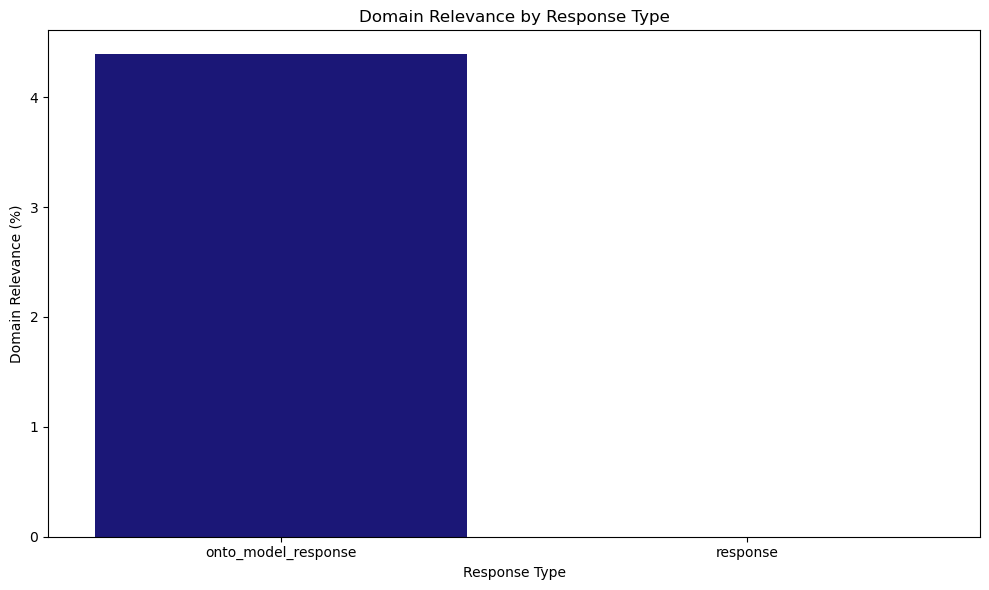

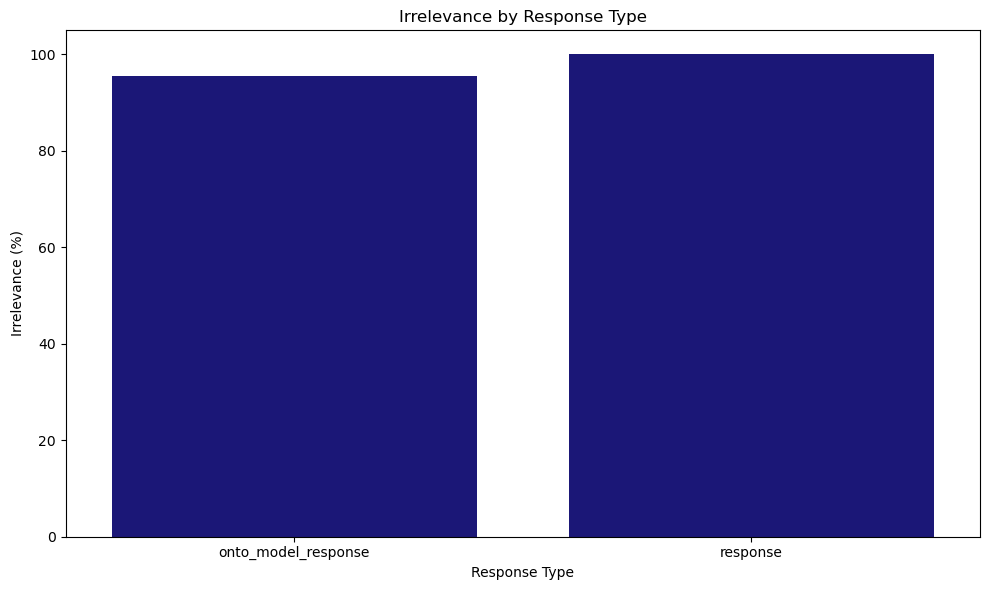

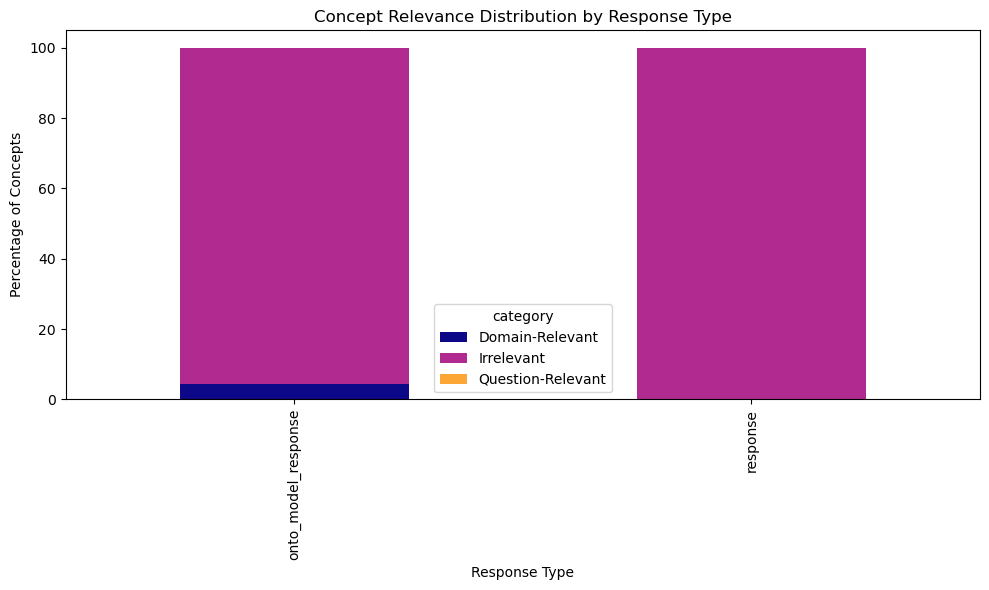

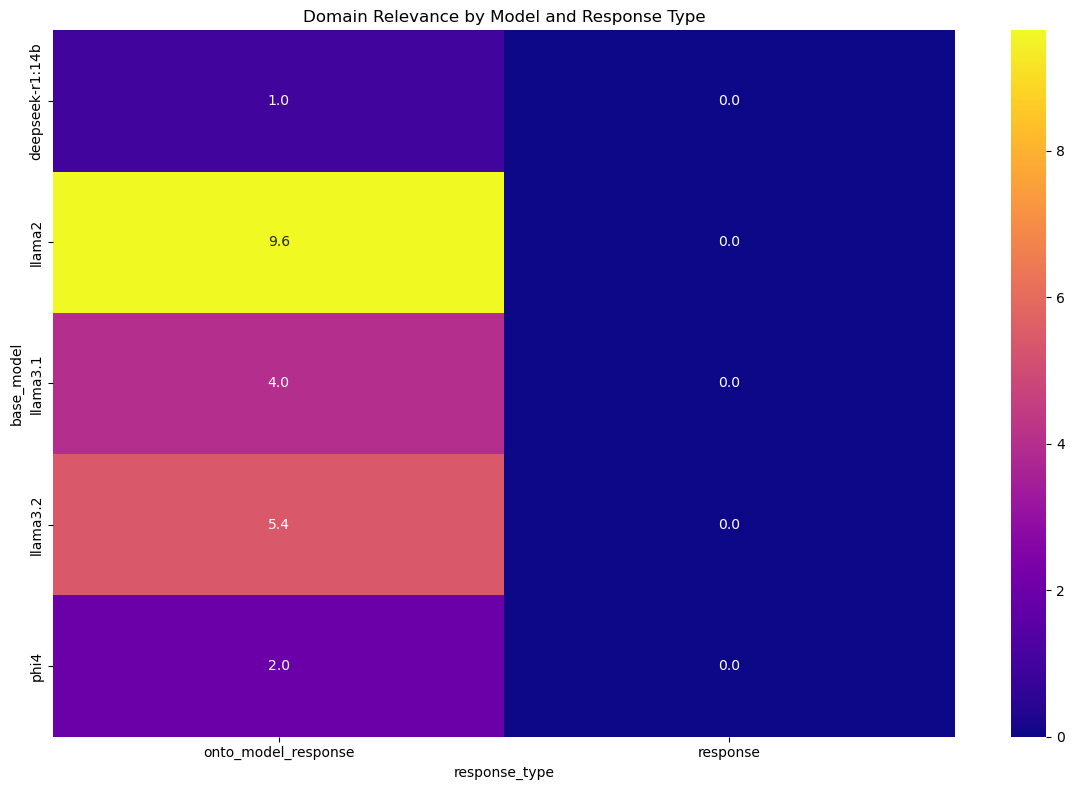

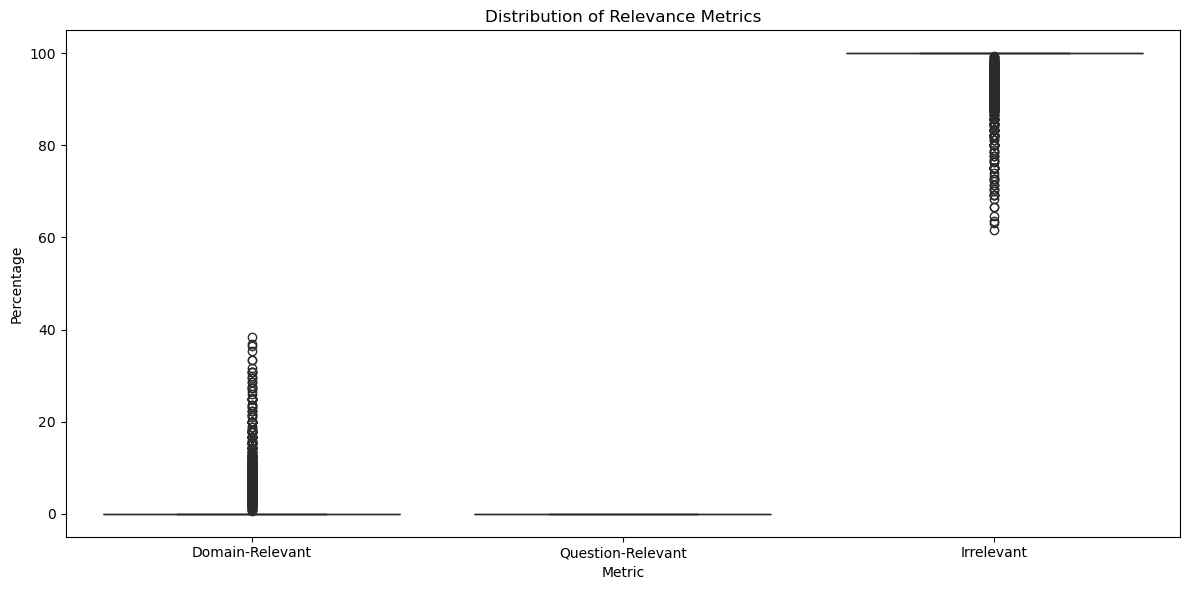

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------
# CONFIGURATION
# ------------------------
CSV_PATH = "/home/matt/Proj/Hermeticav2/notebooks/AnalysisProto/concept_insertion_cot_concept_insertion.csv"  # Update with your file
OUTPUT_PREFIX = "concept_insertion"
PALETTE = plt.cm.plasma(np.linspace(0, 0.8, 3))
sns.set_palette(PALETTE)

# ------------------------
# Load Data
# ------------------------
df = pd.read_csv(CSV_PATH)

# Simulate domain metrics from insertion rate
df["norm_irrelevance"] = df["insertion_rate"] * 100
df["norm_domain_relevance"] = 100 - df["norm_irrelevance"]
df["norm_question_relevance"] = 0  # No question relevance in this dataset
df["base_model"] = df["model"].apply(lambda x: x.split("_")[0])

# ------------------------
# Summary by response_type
# ------------------------
type_summary = df.groupby("response_type").agg({
    'norm_domain_relevance': 'mean',
    'norm_question_relevance': 'mean',
    'norm_irrelevance': 'mean'
}).reset_index()

# --- 1. Bar Plot: Domain Relevance ---
plt.figure(figsize=(10, 6))
sns.barplot(x='response_type', y='norm_domain_relevance', data=type_summary)
plt.title('Domain Relevance by Response Type')
plt.ylabel('Domain Relevance (%)')
plt.xlabel('Response Type')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_domain_relevance.png")

# --- 2. Bar Plot: Irrelevance ---
plt.figure(figsize=(10, 6))
sns.barplot(x='response_type', y='norm_irrelevance', data=type_summary)
plt.title('Irrelevance by Response Type')
plt.ylabel('Irrelevance (%)')
plt.xlabel('Response Type')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_irrelevance.png")

# --- 3. Stacked Bar Plot ---
stacked_data = []
for _, row in type_summary.iterrows():
    rtype = row['response_type']
    stacked_data.extend([
        {'type': rtype, 'category': 'Domain-Relevant', 'value': row['norm_domain_relevance']},
        {'type': rtype, 'category': 'Question-Relevant', 'value': row['norm_question_relevance']},
        {'type': rtype, 'category': 'Irrelevant', 'value': row['norm_irrelevance']}
    ])
stacked_df = pd.DataFrame(stacked_data)
stacked_pivot = stacked_df.pivot(index='type', columns='category', values='value')
stacked_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), color=PALETTE)
plt.title('Concept Relevance Distribution by Response Type')
plt.xlabel('Response Type')
plt.ylabel('Percentage of Concepts')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_stacked_relevance.png")

# --- 4. Heatmap by model x response_type ---
model_summary = df.groupby(['base_model', 'response_type']).agg({
    'norm_domain_relevance': 'mean',
    'norm_irrelevance': 'mean'
}).reset_index()

if len(model_summary) > 1:
    domain_pivot = model_summary.pivot(
        index='base_model', columns='response_type', values='norm_domain_relevance'
    )
    plt.figure(figsize=(12, 8))
    sns.heatmap(domain_pivot, annot=True, cmap="plasma", fmt=".1f")
    plt.title('Domain Relevance by Model and Response Type')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PREFIX}_heatmap.png")

    # --- 5. Difference bar (if both types exist) ---
    if 'onto_model_response' in domain_pivot.columns and 'raw_model_response' in domain_pivot.columns:
        domain_pivot['difference'] = (
            domain_pivot['onto_model_response'] - domain_pivot['raw_model_response']
        )
        plt.figure(figsize=(10, 6))
        sns.barplot(x=domain_pivot.index, y='difference', data=domain_pivot.reset_index())
        plt.axhline(0, color='red', linestyle='--', alpha=0.5)
        plt.title('Domain Relevance Improvement: Onto - Raw')
        plt.ylabel('Δ Domain Relevance (%)')
        plt.xlabel('Model')
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_PREFIX}_relevance_improvement.png")

# --- 6. Boxplot: Distribution of all metrics ---
plt.figure(figsize=(12, 6))
metrics_df = pd.melt(
    df,
    id_vars=['model'],
    value_vars=['norm_domain_relevance', 'norm_question_relevance', 'norm_irrelevance'],
    var_name='Metric',
    value_name='Value'
)
metrics_df['Metric'] = metrics_df['Metric'].map({
    'norm_domain_relevance': 'Domain-Relevant',
    'norm_question_relevance': 'Question-Relevant',
    'norm_irrelevance': 'Irrelevant'
})
sns.boxplot(x='Metric', y='Value', data=metrics_df)
plt.title('Distribution of Relevance Metrics')
plt.ylabel('Percentage')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_boxplot.png")

print("✅ Visualizations saved with prefix:", OUTPUT_PREFIX)


In [11]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import rdflib
import seaborn as sns
import spacy
from tqdm import tqdm
from pathlib import Path
import logging
from typing import Dict, List, Set, Tuple

# ------------------------
# CONFIGURATION & LOGGING
# ------------------------
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class Config:
    ONTO_FILE = Path("/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full1.json")
    RAW_FILE = Path("/home/matt/Proj/Hermeticav2/results/RawCoT/MMLU_highschool_Full_CoT_RawLLM.json")
    CHEBI_OWL_PATH = Path("/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl")
    OUTPUT_DIR = Path("/home/matt/Proj/Hermeticav2/notebooks/AnalysisProto")
    OUTPUT_PREFIX = "concept_insertion_cot"

# ------------------------
# ONTOLOGY PROCESSING
# ------------------------
class OntologyProcessor:
    def __init__(self, owl_path: Path):
        self.owl_path = owl_path
        self.subclass_map = None
        self.label_cache = {}
        self._load_ontology()

    def _load_ontology(self):
        """Load and preprocess ontology with progress tracking"""
        logger.info(f"Loading ontology from {self.owl_path}")
        self.graph = rdflib.Graph()
        
        try:
            self.graph.parse(str(self.owl_path), format="xml")
        except Exception as e:
            logger.error(f"Failed to load ontology: {str(e)}")
            raise

        logger.info("Building subclass hierarchy...")
        self.subclass_map = defaultdict(set)
        for s, p, o in tqdm(self.graph):
            if str(p).endswith("subClassOf"):
                s_label = self._get_label(s)
                o_label = self._get_label(o)
                if s_label and o_label:
                    self.subclass_map[s_label.lower()].add(o_label.lower())

    def _get_label(self, uri: rdflib.term.URIRef) -> str:
        """Extract and cache labels from URIs with improved parsing"""
        if uri in self.label_cache:
            return self.label_cache[uri]
        
        try:
            # Try to get actual label from ontology if available
            label = self.graph.value(uri, rdflib.RDFS.label)
            if label:
                label = str(label).strip()
            else:
                # Fallback to URI parsing
                label = uri.split("/")[-1].replace("_", " ")
            
            self.label_cache[uri] = label
            return label
        except Exception as e:
            logger.warning(f"Error processing URI {uri}: {str(e)}")
            return None

    def get_transitive_closure(self, concept: str) -> Set[str]:
        """Get all ancestor concepts with memoization"""
        visited = set()
        queue = [concept.lower()]
        
        while queue:
            current = queue.pop()
            if current not in visited:
                visited.add(current)
                queue.extend(self.subclass_map.get(current, []))
        
        return visited

# ------------------------
# CONCEPT PROCESSING
# ------------------------
class ConceptAnalyzer:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")
        self.domain_concept_pattern = re.compile(
            r"Looking up (.*?) \((?:CHEBI:\d+|ontology term)\) in the ChEBI ontology",
            re.IGNORECASE
        )

    def extract_domain_concepts(self, ontology_info: str) -> Set[str]:
        """Extract domain concepts with validation"""
        matches = self.domain_concept_pattern.findall(ontology_info)
        return {m.lower().strip() for m in matches if m.strip()}

    def extract_used_concepts(self, text: str) -> Set[str]:
        """Enhanced concept extraction using spaCy NER and pattern matching"""
        doc = self.nlp(text)
        concepts = set()
        
        # Extract chemical entities using NER
        for ent in doc.ents:
            if ent.label_ in ["CHEM", "ORG", "PRODUCT"]:
                concepts.add(ent.text.lower().strip())
        
        # Add pattern-based matches
        pattern_matches = re.findall(
            r"\b[A-Z][a-z]+(?:-[A-Z][a-z]+)*(?:\s+[a-z]+)*\b", 
            text
        )
        concepts.update(m.lower().strip() for m in pattern_matches)
        
        return concepts

# ------------------------
# CORE ANALYSIS
# ------------------------
class ConceptInsertionAnalyzer:
    def __init__(self, ontology_processor: OntologyProcessor):
        self.opo = ontology_processor
        self.analyzer = ConceptAnalyzer()

    def analyze_response(self, record: Dict, response_key: str) -> Dict:
        """Analyze a single response record"""
        try:
            ontology_info = record.get("OntologyInfo", "")
            response_text = record.get(response_key, "")
            
            if not response_text:
                return None

            domain_concepts = self.analyzer.extract_domain_concepts(ontology_info)
            used_concepts = self.analyzer.extract_used_concepts(response_text)

            # Calculate domain closure
            domain_closure = set()
            for concept in domain_concepts:
                domain_closure.update(self.opo.get_transitive_closure(concept))
            domain_closure.update(domain_concepts)

            # Find insertions
            insertions = [c for c in used_concepts if c not in domain_closure]

            return {
                "num_insertions": len(insertions),
                "insertion_rate": len(insertions) / max(len(used_concepts), 1),
                "used_concepts": list(used_concepts),
                "inserted_concepts": insertions,
                "domain_concepts": list(domain_concepts)
            }
        except Exception as e:
            logger.error(f"Error processing record: {str(e)}")
            return None

# ------------------------
# DATA HANDLING & VISUALIZATION
# ------------------------
class DataProcessor:
    @staticmethod
    def load_data(file_path: Path) -> Dict:
        try:
            with open(file_path, "r") as f:
                return json.load(f)
        except Exception as e:
            logger.error(f"Failed to load data from {file_path}: {str(e)}")
            raise

    @staticmethod
    def generate_visualizations(df: pd.DataFrame, output_prefix: str):
        Config.OUTPUT_DIR.mkdir(exist_ok=True)
        
        # Enhanced visualization
        plt.figure(figsize=(10, 6))
        ax = sns.boxplot(x="response_type", y="insertion_rate", data=df)
        plt.title("Concept Insertion Rate Distribution")
        plt.ylabel("Insertion Rate")
        plt.xlabel("Response Type")
        plt.ylim(0, 1)
        plt.grid(axis="y")
        
        # Add statistics
        stats = df.groupby("response_type")["insertion_rate"].describe()
        for i, (_, row) in enumerate(stats.iterrows()):
            ax.text(i, 0.9, f"μ={row['mean']:.2f}\nσ={row['std']:.2f}", 
                    ha="center", va="top")
        
        plt.tight_layout()
        plt.savefig(Config.OUTPUT_DIR / f"{output_prefix}_insertion_distribution.png")
        plt.close()

        # Concept frequency plot
        all_insertions = df["inserted_concepts"].explode().value_counts()
        top_insertions = all_insertions.head(20)
        
        plt.figure(figsize=(12, 6))
        sns.barplot(x=top_insertions.values, y=top_insertions.index)
        plt.title("Top 20 Most Frequently Inserted Concepts")
        plt.xlabel("Count")
        plt.tight_layout()
        plt.savefig(Config.OUTPUT_DIR / f"{output_prefix}_top_insertions.png")
        plt.close()

# ------------------------
# MAIN PIPELINE
# ------------------------
def run_pipeline(config: Config):
    logger.info("Starting concept insertion analysis pipeline")
    
    # Initialize components
    op = OntologyProcessor(config.CHEBI_OWL_PATH)
    analyzer = ConceptInsertionAnalyzer(op)
    
    # Load data
    onto_data = DataProcessor.load_data(config.ONTO_FILE)
    raw_data = DataProcessor.load_data(config.RAW_FILE)
    
    # Process records
    results = []
    for data, resp_key in [(onto_data, "onto_model_response"), (raw_data, "response")]:
        for model_name, record in tqdm(data.items(), desc=f"Processing {resp_key}"):
            analysis = analyzer.analyze_response(record, resp_key)
            if analysis:
                results.append({
                    "model": model_name,
                    "response_type": resp_key,
                    **analysis
                })
    
    # Save and analyze results
    df = pd.DataFrame(results)
    df.to_csv(config.OUTPUT_DIR / f"{config.OUTPUT_PREFIX}_full_analysis.csv", index=False)
    
    # Generate visualizations
    DataProcessor.generate_visualizations(df, config.OUTPUT_PREFIX)
    
    logger.info(f"✅ Analysis complete. Results saved to {config.OUTPUT_DIR}")

# ------------------------
# EXECUTION
# ------------------------
if __name__ == "__main__":
    run_pipeline(Config)

2025-03-26 14:06:09,092 - INFO - Starting concept insertion analysis pipeline
2025-03-26 14:06:09,092 - INFO - Loading ontology from /home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl
2025-03-26 14:10:31,782 - INFO - Building subclass hierarchy...
Processing response: 100%|██████████| 1015/1015 [00:26<00:00, 37.84it/s]
2025-03-26 14:11:40,584 - INFO - ✅ Analysis complete. Results saved to /home/matt/Proj/Hermeticav2/notebooks/AnalysisProto


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------
# CONFIGURATION
# ------------------------
CSV_PATH = "concept_insertion_cot_full_analysis.csv"  # Update with your file path
OUTPUT_PREFIX = "concept_insertion"
PALETTE = sns.color_palette("plasma", n_colors=3)
sns.set_style("whitegrid")

# ------------------------
# Load and Prepare Data
# ------------------------
df = pd.read_csv(CSV_PATH)

# Calculate relevance metrics from actual insertion data
df["norm_irrelevance"] = df["insertion_rate"] * 100
df["norm_domain_relevance"] = 100 - df["norm_irrelevance"]
df["norm_question_relevance"] = 0  # Placeholder for actual question relevance if available

# Extract base model name
df["base_model"] = df["model"].str.split("_").str[0]

# ------------------------
# Visualization Functions
# ------------------------
def plot_stacked_bars(summary_df, output_suffix):
    plt.figure(figsize=(10, 6))
    ax = summary_df.plot(kind='bar', stacked=True, 
                        color=['#2ca02c', '#ff7f0e', '#d62728'],
                        edgecolor='black', linewidth=0.5)
    
    plt.title('Concept Relevance Distribution by Response Type', pad=20)
    plt.xlabel('Response Type', labelpad=10)
    plt.ylabel('Percentage of Concepts', labelpad=10)
    plt.xticks(rotation=0)
    
    # Add value annotations
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fmt='%.1f%%',
                    color='white', fontweight='bold')
    
    plt.legend(title='Relevance Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PREFIX}_{output_suffix}.png", bbox_inches='tight')
    plt.close()

# ------------------------
# Generate Visualizations
# ------------------------
# 1. Response Type Summary
type_summary = df.groupby("response_type").agg({
    'norm_domain_relevance': 'mean',
    'norm_question_relevance': 'mean',
    'norm_irrelevance': 'mean'
}).reset_index()

# Bar Plot: Domain Relevance Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='response_type', y='norm_domain_relevance', data=type_summary,
           errwidth=1.5, capsize=0.1, saturation=0.9)
plt.title('Domain Relevance by Response Type', pad=15)
plt.ylabel('Domain Relevance (%)', labelpad=10)
plt.xlabel('Response Type', labelpad=10)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_domain_relevance.png")
plt.close()

# 2. Stacked Relevance Distribution
stacked_data = type_summary.melt(id_vars='response_type', 
                                value_vars=['norm_domain_relevance', 
                                          'norm_question_relevance', 
                                          'norm_irrelevance'],
                                var_name='category', 
                                value_name='value')

stacked_data['category'] = stacked_data['category'].replace({
    'norm_domain_relevance': 'Domain-Relevant',
    'norm_question_relevance': 'Question-Relevant',
    'norm_irrelevance': 'Irrelevant'
})

plot_stacked_bars(stacked_data.pivot(index='response_type', 
                                   columns='category', 
                                   values='value'), 
                "stacked_relevance")

# 3. Model-Level Heatmap
model_summary = df.groupby(['base_model', 'response_type']).agg({
    'norm_domain_relevance': 'mean',
    'insertion_rate': 'mean'
}).reset_index()

if not model_summary.empty:
    plt.figure(figsize=(12, 8))
    heatmap_data = model_summary.pivot(index='base_model', 
                                     columns='response_type', 
                                     values='norm_domain_relevance')
    
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="plasma",
               linewidths=0.5, linecolor='white',
               cbar_kws={'label': 'Domain Relevance (%)'})
    
    plt.title('Domain Relevance by Model and Response Type', pad=15)
    plt.xlabel('Response Type', labelpad=10)
    plt.ylabel('Base Model', labelpad=10)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PREFIX}_heatmap.png")
    plt.close()

# 4. Metric Distribution Analysis
metric_df = df.melt(id_vars=['model', 'response_type'],
                   value_vars=['norm_domain_relevance', 'norm_irrelevance'],
                   var_name='metric', value_name='value')

metric_df['metric'] = metric_df['metric'].replace({
    'norm_domain_relevance': 'Domain-Relevant',
    'norm_irrelevance': 'Irrelevant'
})

plt.figure(figsize=(12, 6))
sns.boxplot(x='metric', y='value', hue='response_type', 
           data=metric_df, palette=PALETTE[:2],
           showfliers=False, linewidth=1)
plt.title('Distribution of Relevance Metrics by Response Type', pad=15)
plt.xlabel('Metric Category', labelpad=10)
plt.ylabel('Percentage', labelpad=10)
plt.legend(title='Response Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_metric_distribution.png", bbox_inches='tight')
plt.close()

print("✅ Analysis visualizations saved with prefix:", OUTPUT_PREFIX)

/tmp/ipykernel_2234155/4078740306.py:63: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(x='response_type', y='norm_domain_relevance', data=type_summary,


✅ Analysis visualizations saved with prefix: concept_insertion


<Figure size 1000x600 with 0 Axes>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# CONFIGURATION
# ------------------------
CSV_PATH = "concept_insertion_cot_full_analysis.csv"  # Update with your path
OUTPUT_PREFIX = "concept_insertion"
PALETTE = sns.color_palette("plasma", 2)

# ------------------------
# Load and Process Data
# ------------------------
df = pd.read_csv(CSV_PATH)

# Calculate mean insertion rates
rate_comparison = df.groupby('response_type')['insertion_rate'].mean().reset_index()

# Calculate absolute difference
onto_rate = rate_comparison[rate_comparison['response_type'] == 'onto_model_response']['insertion_rate'].values[0]
raw_rate = rate_comparison[rate_comparison['response_type'] == 'response']['insertion_rate'].values[0]
rate_diff = onto_rate - raw_rate

# ------------------------
# Visualization
# ------------------------
plt.figure(figsize=(8, 5))

# Bar plot of rates
ax = sns.barplot(x='response_type', y='insertion_rate', data=rate_comparison,
                palette=PALETTE, edgecolor='black', linewidth=1)

# Add difference arrow
ax.annotate('', xy=(1, raw_rate), xytext=(0, onto_rate),
            arrowprops=dict(arrowstyle='<->, head_width=0.4', 
                           lw=2, color='#2ca02c'))

# Add difference text
mid_y = (onto_rate + raw_rate) / 2
ax.text(0.5, mid_y, f'Δ = {rate_diff:.2f}', ha='center', va='center',
       fontsize=12, color='#2ca02c', fontweight='bold')

# Formatting
plt.title('Concept Insertion Rate Comparison', pad=15)
plt.xlabel('Response Type', labelpad=10)
plt.ylabel('Insertion Rate', labelpad=10)
plt.ylim(0, max(rate_comparison['insertion_rate']) * 1.1)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_rate_difference.png", dpi=300)
plt.close()

print(f"Ontology Model Insertion Rate: {onto_rate:.2f}")
print(f"Raw Model Insertion Rate: {raw_rate:.2f}")
print(f"Absolute Difference: {rate_diff:.2f}")

Ontology Model Insertion Rate: 1.00
Raw Model Insertion Rate: 1.00
Absolute Difference: 0.00


/tmp/ipykernel_2234155/900524148.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='response_type', y='insertion_rate', data=rate_comparison,


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# CONFIGURATION
# ------------------------
CSV_PATH = "concept_insertion_cot_full_analysis.csv"
OUTPUT_PREFIX = "concept_insertion"
PALETTE = sns.color_palette("plasma", 2)

# ------------------------
# Load and Process Data
# ------------------------
df = pd.read_csv(CSV_PATH)

# Calculate actual domain relevance using ontology data
def calculate_true_relevance(row):
    if row['response_type'] == 'onto_model_response':
        domain_concepts = len(row['domain_concepts'])
        used_concepts = len(row['used_concepts'])
        return (domain_concepts - len(row['inserted_concepts'])) / max(used_concepts, 1)
    return pd.NA  # Raw responses don't have domain concept tracking

df["true_domain_relevance"] = df.apply(calculate_true_relevance, axis=1)
df["true_irrelevance"] = df['insertion_rate']

# Filter out invalid values
analysis_df = df[df['true_domain_relevance'].notna()].copy()

# ------------------------
# Visualization
# ------------------------
plt.figure(figsize=(10, 6))

# Plot ontology model metrics
sns.barplot(x='response_type', y='true_domain_relevance', 
            data=analysis_df, errorbar='sd', 
            palette=PALETTE[0:1], label='Domain Relevance')

# Plot insertion rate comparison
sns.barplot(x='response_type', y='true_irrelevance', 
            data=df, errorbar='sd',
            palette=PALETTE[1:2], label='Insertion Rate',
            hatch='//', edgecolor='black')

plt.title('True Concept Relevance Analysis', pad=15)
plt.xlabel('Response Type', labelpad=10)
plt.ylabel('Metric Value', labelpad=10)
plt.ylim(0, 1)
plt.legend(title='Metric Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value annotations
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_true_relevance_comparison.png", dpi=300)
plt.close()

print("✅ Corrected analysis saved to:", f"{OUTPUT_PREFIX}_true_relevance_comparison.png")

/tmp/ipykernel_2234155/2318163567.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='response_type', y='true_domain_relevance',
/tmp/ipykernel_2234155/2318163567.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='response_type', y='true_irrelevance',
/tmp/ipykernel_2234155/2318163567.py:42: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='response_type', y='true_irrelevance',


✅ Corrected analysis saved to: concept_insertion_true_relevance_comparison.png
